# ❇️ 셀러 성과 관리 분석

# 0️⃣ 데이터 준비

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import copy
from datetime import datetime, timedelta
import random
import warnings

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
    print('✅ Malgun Gothic 설정!')
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    print('✅ AppleGothic 설정!')
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    print('✅ NanumGothic 설정!')

plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)  # 전체 출력 O


✅ Malgun Gothic 설정!


In [2]:
df = pd.read_csv('merged_df_segment_Final.csv')

# datetime 변환
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'shipping_limit_date',
             'order_delivered_customer_date', 'order_delivered_carrier_date', 
             'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    
display(df.head())
print(f"데이터 shape: {df.shape}")
print(f"unique 셀러 수: {df['seller_id'].nunique(dropna=True)}")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delayed,is_canceled,product_category_name,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_message,review_creation_date,geolocation_zip_code_prefix,lat_mode,lng_mode,geolocation_city,geolocation_state,seller_total_revenue,segment
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,-9.0,0.0,0,cool_stuff,cool_stuff,27277,volta redonda,SP,volta redonda,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,97ca439bc427b48bc1cd7177abe71365,5.0,"Perfeito, produto entregue antes do combinado.",NaN,27277.0,-22.501227,-44.124864,volta redonda,RJ,12271.71,SMB
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,-3.0,0.0,0,pet_shop,pet_shop,3471,sao paulo,SP,sao paulo,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,3471.0,-23.571687,-46.521540,sao paulo,SP,9178.51,SMB
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,-14.0,0.0,0,moveis_decoracao,furniture_decor,37564,borda da mata,MG,borda da mata,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,0c5b33dea94867d1ac402749e5438e8b,5.0,Chegou antes do prazo previsto e o produto sur...,NaN,37564.0,-22.324906,-46.239752,borda da mata,MG,3280.00,SMB
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,-6.0,0.0,0,perfumaria,perfumery,14403,franca,SP,franca,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,14403.0,-20.545472,-47.381048,franca,SP,1054.82,SMB
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,-16.0,0.0,0,ferramentas_jardim,garden_tools,87900,loanda,PR,loanda,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,940144190dcba6351888cafa43f3a3a5,5.0,Gostei pois veio no prazo determinado .,NaN,87900.0,-22.939806,-53.148630,loanda,PR,3661.18,SMB


데이터 shape: (112650, 38)
unique 셀러 수: 3095


# 1️⃣ 기본 EDA 및 통계

In [3]:
df_eda = df.copy()

In [4]:
df_eda['seller_total_revenue']

0         12271.71
1          9178.51
2          3280.00
3          1054.82
4          3661.18
            ...   
112645    13685.71
112646     1581.00
112647    43048.18
112648    23629.15
112649     2787.40
Name: seller_total_revenue, Length: 112650, dtype: float64

## seller 레벨 KPI

- seller_total_revenue
- 판매량
- 평균 배송시간, 평균 배송지연률
- 평균 리뷰 점수
- 주문 취소율 (is_canceled 평균)
- product 평균 가격(price 평균)

In [5]:
df_eda['quantity'] = df_eda.groupby('product_id')['order_item_id'].transform('count')

In [6]:
# Seller-level KPI 생성

seller_df = df_eda.groupby(['seller_id', 'segment']).agg(
    total_revenue=('seller_total_revenue', 'first'),  # 셀러 단위 총매출
    avg_price=('price', 'mean'),
    total_products=('product_id', 'nunique'),
    total_orders=('order_id', 'nunique'),
    total_quantity=('quantity', 'sum'),
    avg_review=('review_score', 'mean'),
    cancel_rate=('is_canceled', 'mean')
).reset_index()


#### seller_total_revenue

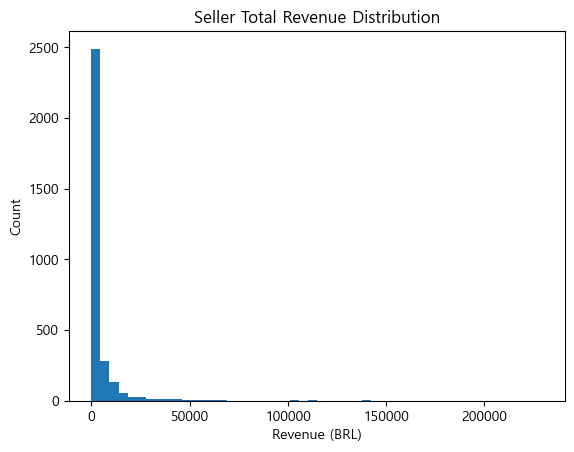

In [7]:
plt.hist(seller_df['total_revenue'], bins=50)
plt.title('Seller Total Revenue Distribution')
plt.xlabel('Revenue (BRL)')
plt.ylabel('Count')
plt.show()

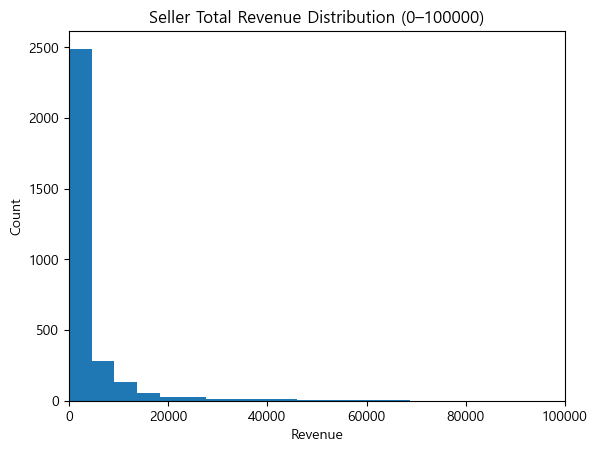

In [8]:
plt.hist(seller_df['total_revenue'], bins=50)
plt.title('Seller Total Revenue Distribution (0–100000)')
plt.xlabel('Revenue')
plt.ylabel('Count')

plt.xlim(0, 100000)

plt.show()

- 대부분의 셀러는 매우 낮은 매출 구간: 0~5000 BRL 이하
- 극소수의 셀러가 매우 높은 매출: 일부 셀러는 10만~40만 BRL 이상의 초고매출 셀러

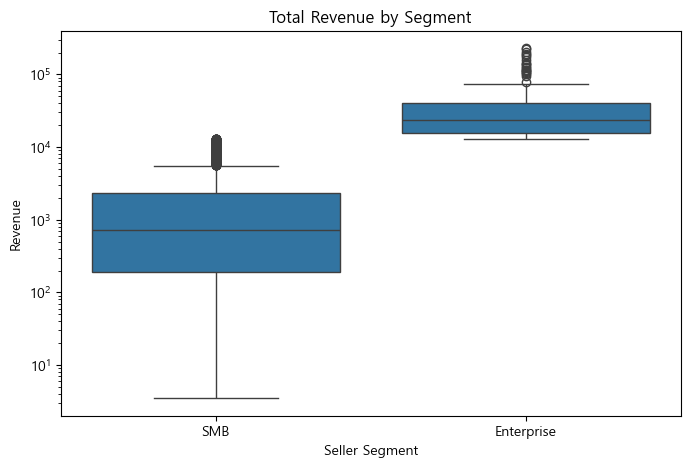

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
Enterprise,219.0,37273.833973,38557.348617,12983.81,15688.6150,23302.7,40796.440,229472.63
SMB,2876.0,1887.577907,2687.600113,3.50,193.5075,722.3,2351.205,12938.30


In [9]:
# Segment별 매출 차이 분석
seller_rev_seg = seller_df.groupby(['seller_id','segment'])['total_revenue'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.boxplot(data=seller_rev_seg, x='segment', y='total_revenue')
plt.title('Total Revenue by Segment')
plt.ylabel('Revenue')
plt.xlabel('Seller Segment')
plt.yscale('log')
plt.show()

seller_rev_seg.groupby('segment')['total_revenue'].describe()

In [10]:
# 분석 1) Enterprise vs  SMB KPI (매출) 차이 검정

from scipy.stats import mannwhitneyu

enterprise = seller_rev_seg.loc[
    seller_rev_seg['segment'] == 'Enterprise',
    'total_revenue'
]

smb = seller_rev_seg.loc[
    seller_rev_seg['segment'] == 'SMB',
    'total_revenue'
]

stat, p_value = mannwhitneyu(
    enterprise,
    smb,
    alternative='greater'  # Enterprise > SMB
)

print(f"Mann–Whitney U stat: {stat:.2f}")
print(f"p-value: {p_value:.6f}")


Mann–Whitney U stat: 629844.00
p-value: 0.000000


In [11]:
# 분석 2) Enterprise vs SMB 매출 분산 차이 검정

from scipy.stats import levene

# Segment별 매출 분산 비교를 위한 데이터 분리
enterprise_rev = seller_rev_seg.loc[
    seller_rev_seg['segment'] == 'Enterprise',
    'total_revenue'
]

smb_rev = seller_rev_seg.loc[
    seller_rev_seg['segment'] == 'SMB',
    'total_revenue'
]

# Levene test (분산 동일성 검정)
stat, p_value = levene(enterprise_rev, smb_rev, center='median')

print(f"Levene stat: {stat:.4f}, p-value: {p_value:.6f}")


Levene stat: 796.6522, p-value: 0.000000


In [12]:
# segment별 개수
segment_count = df_eda['segment'].value_counts()
print(segment_count)

# segment별 비율 (%)
segment_ratio = df_eda['segment'].value_counts(normalize=True) * 100
print(segment_ratio)


segment
Enterprise    58758
SMB           53892
Name: count, dtype: int64
segment
Enterprise    52.159787
SMB           47.840213
Name: proportion, dtype: float64


In [13]:
segment_dist = df_eda.groupby('segment')['seller_id'].nunique()
print(segment_dist)
print(f"SMB 비율: {segment_dist['SMB'] / segment_dist.sum() * 100:.1f}%")
print(f"Enterprise 비율: {segment_dist['Enterprise'] / segment_dist.sum() * 100:.1f}%")

segment
Enterprise     219
SMB           2876
Name: seller_id, dtype: int64
SMB 비율: 92.9%
Enterprise 비율: 7.1%


In [14]:
df_eda.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delayed,is_canceled,product_category_name,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_message,review_creation_date,geolocation_zip_code_prefix,lat_mode,lng_mode,geolocation_city,geolocation_state,seller_total_revenue,segment,quantity
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,-9.0,0.0,0,cool_stuff,cool_stuff,27277,volta redonda,SP,volta redonda,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,97ca439bc427b48bc1cd7177abe71365,5.0,"Perfeito, produto entregue antes do combinado.",NaN,27277.0,-22.501227,-44.124864,volta redonda,RJ,12271.71,SMB,9
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,-3.0,0.0,0,pet_shop,pet_shop,3471,sao paulo,SP,sao paulo,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,3471.0,-23.571687,-46.521540,sao paulo,SP,9178.51,SMB,1
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,-14.0,0.0,0,moveis_decoracao,furniture_decor,37564,borda da mata,MG,borda da mata,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,0c5b33dea94867d1ac402749e5438e8b,5.0,Chegou antes do prazo previsto e o produto sur...,NaN,37564.0,-22.324906,-46.239752,borda da mata,MG,3280.00,SMB,3
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,-6.0,0.0,0,perfumaria,perfumery,14403,franca,SP,franca,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,14403.0,-20.545472,-47.381048,franca,SP,1054.82,SMB,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,-16.0,0.0,0,ferramentas_jardim,garden_tools,87900,loanda,PR,loanda,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,940144190dcba6351888cafa43f3a3a5,5.0,Gostei pois veio no prazo determinado .,NaN,87900.0,-22.939806,-53.148630,loanda,PR,3661.18,SMB,12


#### 판매량

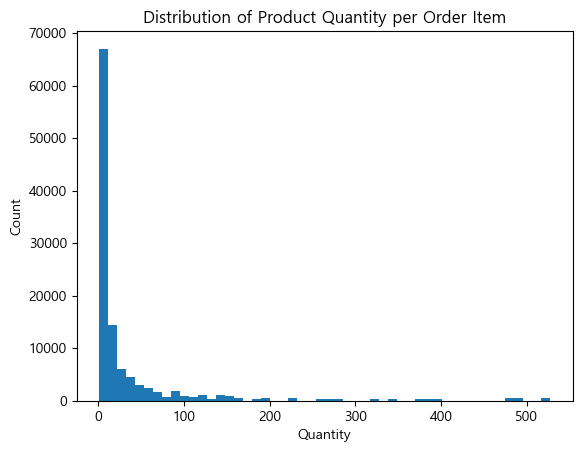

In [15]:
# 판매량 분포
plt.hist(df_eda['quantity'], bins=50)
plt.title('Distribution of Product Quantity per Order Item')
plt.xlabel('Quantity') # 한 주문(order_item)에서 구매된 상품의 개수(quantity)
plt.ylabel('Count') # 해당 quantity가 몇 번 등장했는지 (count)
plt.show()


- quantity=1이 많다: 대부분의 주문은 1개씩만 구매 (단품 위주 구매)
- 5개, 10개, 20개 / 100개 이상 / 500개 초대량 주문: 일반 소형 셀러 (단품 위주 판매), 도매형/전문 셀러 (대량 판매)

-> 소형 셀러 중심, 극소수 도매형 셀러(예상)가 존재

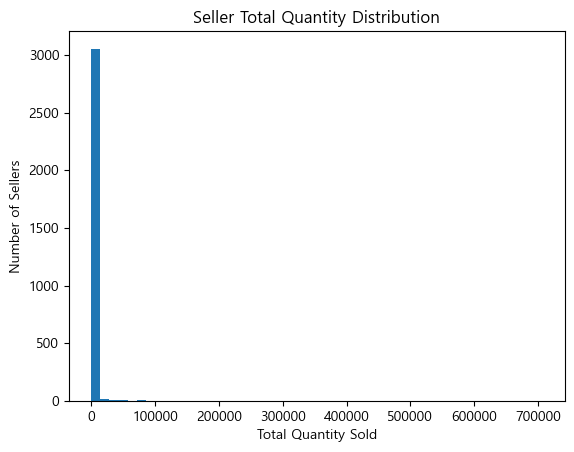

In [16]:
# 셀러별 판매량
seller_qty = df_eda.groupby('seller_id')['quantity'].sum().reset_index()
seller_qty.columns = ['seller_id', 'total_quantity']

plt.hist(seller_qty['total_quantity'], bins=50)
plt.title('Seller Total Quantity Distribution')
plt.xlabel('Total Quantity Sold') # 셀러별 전체 판매량
plt.ylabel('Number of Sellers')

plt.show()


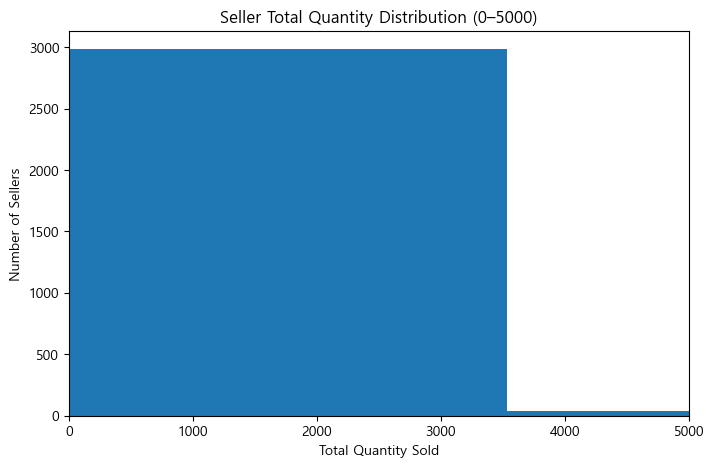

In [17]:
plt.figure(figsize=(8,5))
plt.hist(seller_qty['total_quantity'], bins=200)
plt.xlim(0, 5000) 
plt.title('Seller Total Quantity Distribution (0–5000)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Number of Sellers')
plt.show()


- 대부분 셀러의 판매량이 0~3000개 사이에 밀집
- 대부분의 셀러의 total_quantity가 0~3000개 사이 → 소규모 판매자, 단일 판매자 중심
- 상위 극소수 셀러의 5,000개를 넘는 판매량

-> 판매량 기준 셀러 생태계는 소형 셀러 중심

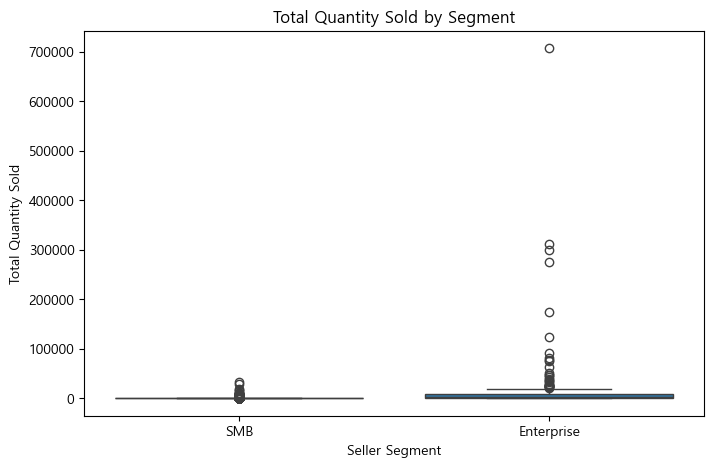

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
Enterprise,219.0,15806.063927,60968.652092,17.0,508.5,1780.0,8137.50,707145.0
SMB,2876.0,222.403338,1218.684904,1.0,3.0,14.0,76.25,33698.0


In [18]:
# Segment별 판매량 총합 비교
seller_qty_seg = df_eda.groupby(['seller_id', 'segment'])['quantity'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.boxplot(data=seller_qty_seg, x='segment', y='quantity')
plt.title('Total Quantity Sold by Segment')
plt.ylabel('Total Quantity Sold')
plt.xlabel('Seller Segment')
plt.show()

# Segment별 평균 판매량 비교
seller_qty_seg.groupby('segment')['quantity'].describe()


- Enterprise 평균 판매량: 18521개
- SMB 평균 판매량: 250개

제거 전: 3095 행
제거 후: 2580 행


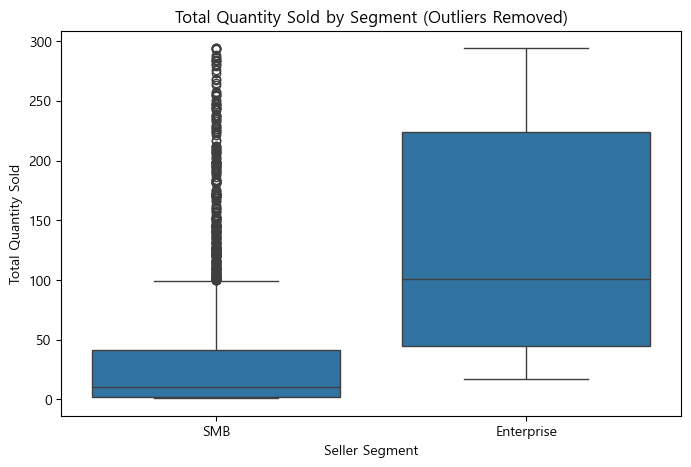

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
Enterprise,37.0,133.702703,98.184029,17.0,45.0,101.0,224.0,294.0
SMB,2543.0,35.585529,56.320941,1.0,2.0,10.0,41.0,294.0


In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# IQR
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)].copy()


seller_qty_seg = df_eda.groupby(['seller_id','segment'])['quantity'].sum().reset_index()

clean_qty_seg = remove_outliers_iqr(seller_qty_seg, 'quantity')

print("제거 전:", len(seller_qty_seg), "행")
print("제거 후:", len(clean_qty_seg), "행")


plt.figure(figsize=(8,5))
sns.boxplot(data=clean_qty_seg, x='segment', y='quantity')
plt.title('Total Quantity Sold by Segment (Outliers Removed)')
plt.ylabel('Total Quantity Sold')
plt.xlabel('Seller Segment')
plt.show()

clean_qty_seg.groupby('segment')['quantity'].describe()


In [20]:
# 분석 1-2) Enterprise vs SMB KPI (판매량) 차이

# Enterprise / SMB 판매량 분리
enterprise_qty = seller_qty_seg.loc[
    seller_qty_seg['segment'] == 'Enterprise', 'quantity'
]

smb_qty = seller_qty_seg.loc[
    seller_qty_seg['segment'] == 'SMB', 'quantity'
]

# Mann–Whitney U 검정 (Enterprise > SMB)
stat, p_value = mannwhitneyu(
    enterprise_qty,
    smb_qty,
    alternative='greater'
)

print(f"Mann–Whitney U stat: {stat:.2f}")
print(f"p-value: {p_value:.6f}")


Mann–Whitney U stat: 589333.50
p-value: 0.000000


In [21]:
# 분석 2-2) Enterprise vs SMB 판매량 분산 차이 검정

from scipy.stats import levene

# 세그먼트별 데이터 분리
enterprise_qty = seller_qty_seg.loc[
    seller_qty_seg['segment'] == 'Enterprise', 'quantity'
]

smb_qty = seller_qty_seg.loc[
    seller_qty_seg['segment'] == 'SMB', 'quantity'
]

# Levene 검정 (median 기준 → 비정규 분포에 적합)
stat, p_value = levene(
    smb_qty,
    enterprise_qty,
    center='median'
)

print(f"Levene stat: {stat:.4f}")
print(f"p-value: {p_value:.6f}")


Levene stat: 176.0085
p-value: 0.000000


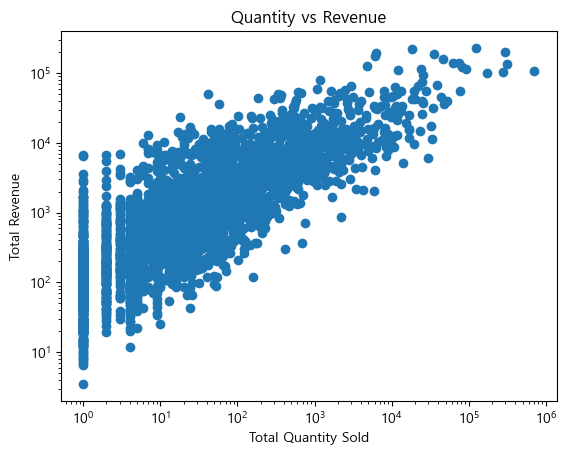

In [22]:
# 판매량 vs 매출 관계

plt.scatter(seller_df['total_quantity'], seller_df['total_revenue'])
plt.xlabel('Total Quantity Sold')
plt.ylabel('Total Revenue')
plt.title('Quantity vs Revenue')
plt.yscale('log')
plt.xscale('log')
plt.show()


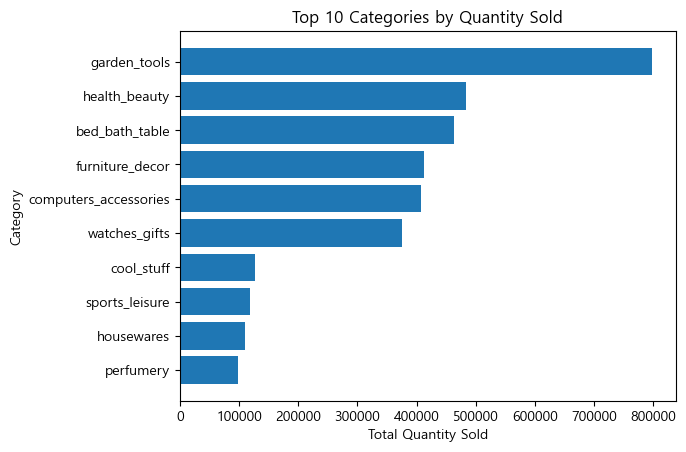

In [23]:
# 카테고리별 판매량 Top 10
cat_qty = df_eda.groupby('product_category_name_english')['quantity'].sum().reset_index()
cat_qty = cat_qty.sort_values('quantity', ascending=False).head(10)

plt.barh(cat_qty['product_category_name_english'], cat_qty['quantity'])
plt.title('Top 10 Categories by Quantity Sold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Category')
plt.gca().invert_yaxis()
plt.show()


#### 평균 리뷰 점수

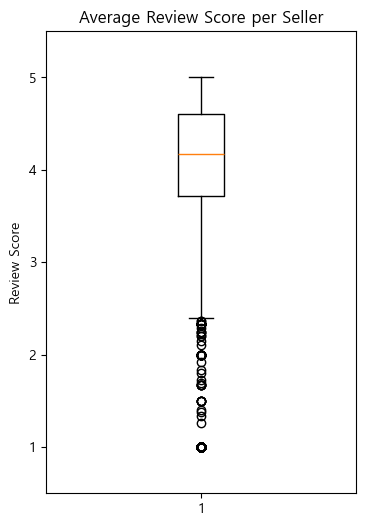

In [24]:
import matplotlib.pyplot as plt

# 평균 리뷰 점수

# seller별 평균 리뷰 점수 계산
seller_df = (
    df_eda.groupby('seller_id')
      .agg(avg_review=('review_score', 'mean'))
      .reset_index()
)

plt.figure(figsize=(4, 6))
plt.boxplot(seller_df['avg_review'].dropna(), vert=True)  # NaN 제거
plt.title('Average Review Score per Seller')
plt.ylabel('Review Score')
plt.ylim(0.5, 5.5) 
plt.show()


In [25]:
seller_df.columns
seller_df.head()

,seller_id,avg_review
0,0015a82c2db000af6aaaf3ae2ecb0532,3.666667
1,001cca7ae9ae17fb1caed9dfb1094831,3.902542
2,001e6ad469a905060d959994f1b41e4f,1.000000
3,002100f778ceb8431b7a1020ff7ab48f,3.981818
4,003554e2dce176b5555353e4f3555ac8,5.000000


In [26]:
seller_df = df_eda.groupby('seller_id').agg(
    total_revenue=('seller_total_revenue', 'first'),
    avg_price=('price', 'mean'),
    total_products=('product_id', 'nunique'),
    total_orders=('order_id', 'nunique'),
    total_quantity=('quantity', 'sum'),
    avg_review=('review_score', 'mean'),
    cancel_rate=('is_canceled', 'mean')
).reset_index()


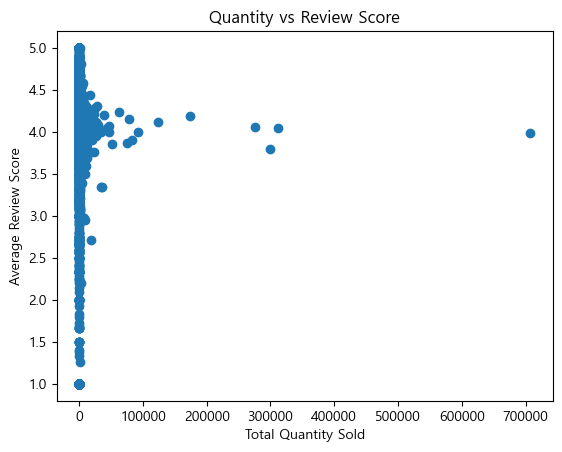

In [27]:
# 판매량 vs 평균 리뷰 점수

plt.scatter(seller_df['total_quantity'], seller_df['avg_review'])
plt.xlabel('Total Quantity Sold')
plt.ylabel('Average Review Score')
plt.title('Quantity vs Review Score')
plt.show()

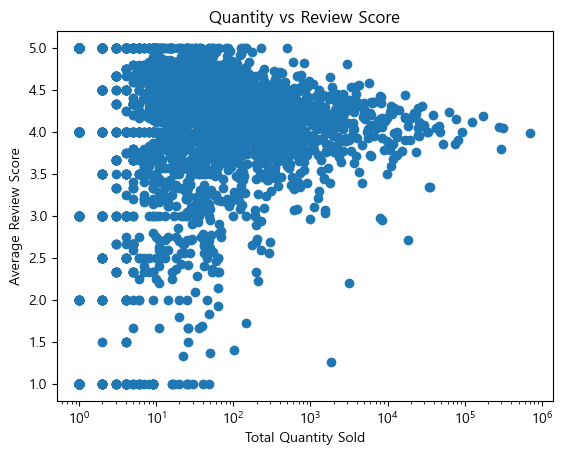

In [28]:
# 판매량 vs 리뷰 점수 (log)
 
plt.scatter(seller_df['total_quantity'], seller_df['avg_review'])
plt.xlabel('Total Quantity Sold')
plt.ylabel('Average Review Score')
plt.title('Quantity vs Review Score')
plt.xscale('log')
plt.show()


- 판매량이 많을수록 리뷰 점수가 좋아지는 패턴 X 
- 평균 리뷰 점수는 약 3.5~4.5 사이

-> 판매량과 리뷰 점수의 직접적 상관은 약함(거의 없음)

- 판매량이 매우 적은 셀러는 리뷰 점수 편차가 큼

-> low-volume seller는 리뷰 안정성이 낮음 (= 리스크 높음)

- 그치만, 판매량이 많은 셀러는 대체로 리뷰 점수가 안정적으로 중간에서 높은 범위에 모임
- 리뷰 점수는 3.7~4.5 사이, 극단적으로 낮은 점수(1~2점대)는 거의 없음

-> high-volume seller는 리뷰 품질이 안정적이며 운영 효율이 높다

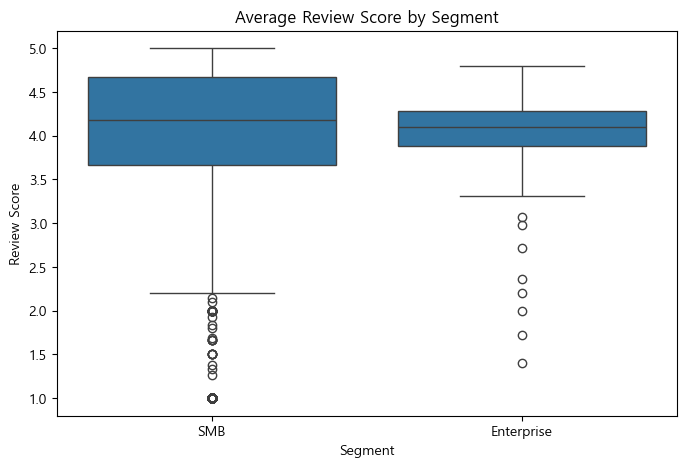

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
Enterprise,219.0,4.022720,0.447385,1.4,3.879895,4.102804,4.283603,4.8
SMB,2871.0,3.967971,1.002783,1.0,3.666667,4.181818,4.666667,5.0


In [29]:
review_seg = df_eda.groupby(['seller_id','segment'])['review_score'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.boxplot(data=review_seg, x='segment', y='review_score')
plt.title('Average Review Score by Segment')
plt.ylabel('Review Score')
plt.xlabel('Segment')
plt.show()

review_seg.groupby('segment')['review_score'].describe()


In [30]:
# Enterprise vs SMB 리뷰 등급 분포 차이

import pandas as pd
from scipy.stats import chi2_contingency

# 리뷰 등급 이진화 (High / Low)
df_review = df_eda[df_eda['review_score'].isin([1,2,3,4,5])].copy()

df_review['review_group'] = df_review['review_score'].apply(
    lambda x: 'High' if x >= 4 else 'Low'
)

# 그룹(Enterprise/SMB) × 리뷰 등급 교차표
contingency_table = pd.crosstab(
    df_review['segment'],
    df_review['review_group']
)

print(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square stat: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")


review_group   High    Low
segment                   
Enterprise    43748  14556
SMB           40607  12797
Chi-square stat: 15.1130
p-value: 0.000101


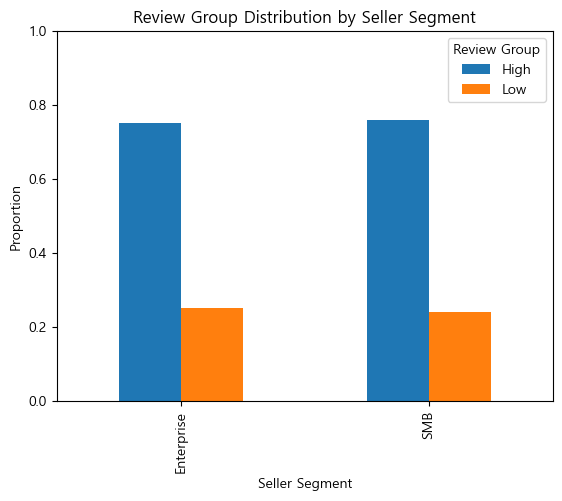

In [31]:
import matplotlib.pyplot as plt

# 비율로 변환
ratio_table = contingency_table.div(contingency_table.sum(axis=1), axis=0)

ratio_table.plot(kind="bar")

plt.title("Review Group Distribution by Seller Segment")
plt.xlabel("Seller Segment")
plt.ylabel("Proportion")
plt.legend(title="Review Group")
plt.ylim(0, 1)

plt.show()


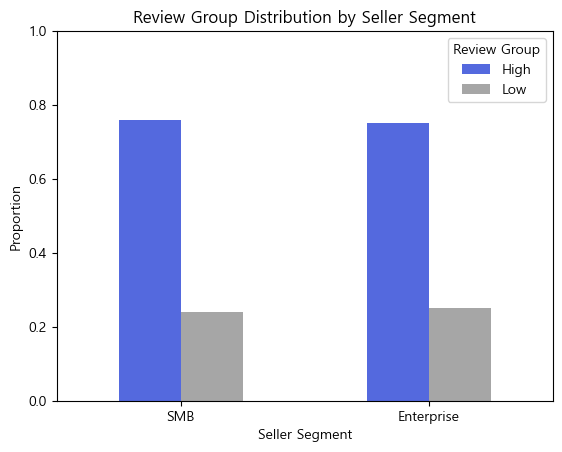

In [32]:
import matplotlib.pyplot as plt

# 1) 비율 테이블 + 순서 변경 (SMB 먼저)
ratio_table = contingency_table.div(contingency_table.sum(axis=1), axis=0)
ratio_table = ratio_table.loc[["SMB", "Enterprise"]]

# 2) 그래프
ratio_table.plot(
    kind="bar",
    color={
        "High": "#0c29d0",
        "Low": "grey"
    },
    alpha=0.7
)

plt.title("Review Group Distribution by Seller Segment")
plt.xlabel("Seller Segment")
plt.ylabel("Proportion")
plt.ylim(0, 1)

# 3) x축 글자 가로
plt.xticks(rotation=0)

plt.legend(title="Review Group")
plt.show()


#### 평균 배송시간, 배송지연

In [33]:
df_eda[['order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date']].dtypes


order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [34]:
# 문자열 → datetime 변환
df_eda['order_purchase_timestamp']     = pd.to_datetime(df_eda['order_purchase_timestamp'])
df_eda['order_delivered_customer_date'] = pd.to_datetime(df_eda['order_delivered_customer_date'])
df_eda['order_estimated_delivery_date'] = pd.to_datetime(df_eda['order_estimated_delivery_date'])


In [35]:
# 실제 배송 소요시간 (일 단위)
df_eda['delivery_time'] = (
    df_eda['order_delivered_customer_date'] - df_eda['order_purchase_timestamp']
).dt.days


In [36]:
df_eda.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delayed,is_canceled,product_category_name,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_message,review_creation_date,geolocation_zip_code_prefix,lat_mode,lng_mode,geolocation_city,geolocation_state,seller_total_revenue,segment,quantity,delivery_time
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,-9.0,0.0,0,cool_stuff,cool_stuff,27277,volta redonda,SP,volta redonda,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,97ca439bc427b48bc1cd7177abe71365,5.0,"Perfeito, produto entregue antes do combinado.",NaN,27277.0,-22.501227,-44.124864,volta redonda,RJ,12271.71,SMB,9,7.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,-3.0,0.0,0,pet_shop,pet_shop,3471,sao paulo,SP,sao paulo,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,3471.0,-23.571687,-46.521540,sao paulo,SP,9178.51,SMB,1,16.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,-14.0,0.0,0,moveis_decoracao,furniture_decor,37564,borda da mata,MG,borda da mata,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,0c5b33dea94867d1ac402749e5438e8b,5.0,Chegou antes do prazo previsto e o produto sur...,NaN,37564.0,-22.324906,-46.239752,borda da mata,MG,3280.00,SMB,3,7.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,-6.0,0.0,0,perfumaria,perfumery,14403,franca,SP,franca,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,14403.0,-20.545472,-47.381048,franca,SP,1054.82,SMB,2,6.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,-16.0,0.0,0,ferramentas_jardim,garden_tools,87900,loanda,PR,loanda,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,940144190dcba6351888cafa43f3a3a5,5.0,Gostei pois veio no prazo determinado .,NaN,87900.0,-22.939806,-53.148630,loanda,PR,3661.18,SMB,12,25.0


In [37]:
# 평균 배송시간 컬럼
df_eda['delivery_time_days'] = (
    df_eda['order_delivered_customer_date'] - df_eda['order_purchase_timestamp']
).dt.days


In [38]:
seller_ship = df_eda.groupby('seller_id').agg(
    avg_delivery_time = ('delivery_time_days', 'mean'),      # 평균 배송시간
    avg_delay_days    = ('delivery_delay_days', 'mean'),     # 평균 지연일수
    delay_rate        = ('is_delayed', 'mean')               # 지연률 (0~1)
).reset_index()


In [39]:
seller_df = seller_df.merge(seller_ship, on='seller_id', how='left')

In [40]:
# seller_df: 매출, 리뷰, 취소율 등
# seller_ship: 배송 KPI
seller_ship = df_eda.groupby('seller_id').agg(
    avg_delivery_time = ('delivery_time_days', 'mean'),
    avg_delay_days    = ('delivery_delay_days', 'mean'),
    delay_rate        = ('is_delayed', 'mean')
).reset_index()

seller_df = seller_df.merge(seller_ship, on='seller_id', how='left')

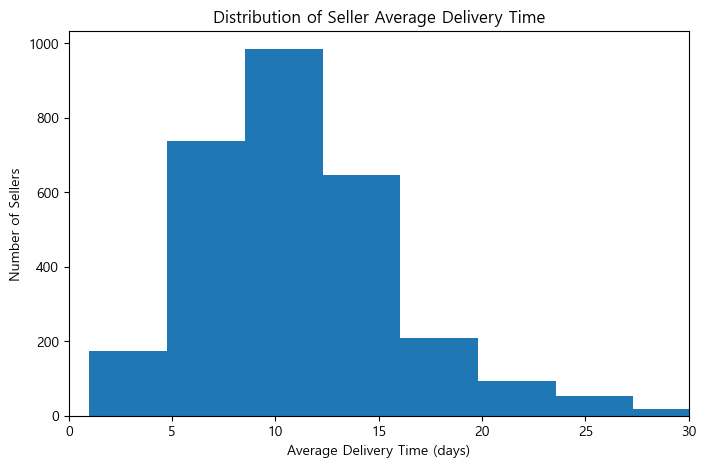

In [41]:
# 셀러별 평균 배송시간 분포
# 셀러 평균 배송시간 분포
plt.figure(figsize=(8, 5))
plt.hist(seller_ship['avg_delivery_time'], bins=50)
plt.title('Distribution of Seller Average Delivery Time')
plt.xlabel('Average Delivery Time (days)')
plt.ylabel('Number of Sellers')
plt.xlim(0, 30)
plt.show()

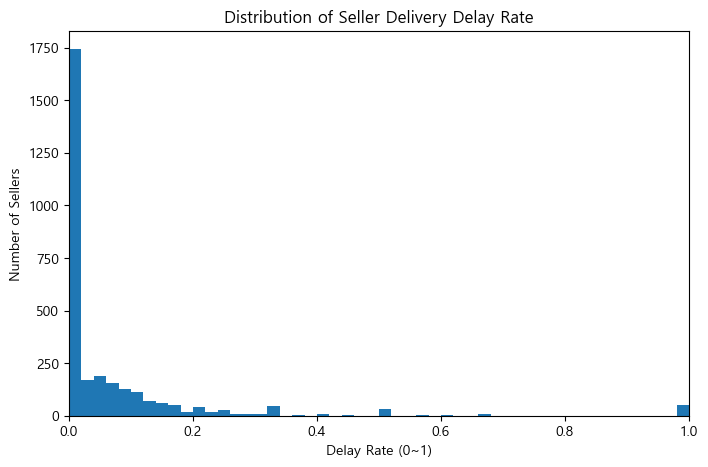

In [42]:
# 셀러 배송 지연률 분포
plt.figure(figsize=(8, 5))
plt.hist(seller_ship['delay_rate'], bins=50)
plt.title('Distribution of Seller Delivery Delay Rate')
plt.xlabel('Delay Rate (0~1)')
plt.ylabel('Number of Sellers')
plt.xlim(0, 1)
plt.show()


- 대부분의 셀러는 지연률 0~0.05
- 대부분의 셀러는 거의 배송 지연이 없다 → 배송 품질이 전반적으로 안정적이다

- 일부 셀러만 지연 문제, 지연률 0.05 ~ 0.20
- 배송 지연이 반복적으로 발생

- 극단값(Outlier) 셀러, 지연률 0.4, 0.6, 1.0
- 배송이 거의 다 지연되는 문제 셀러
- 지연률 1.0 = 모든 배송이 지연 → 운영 리스크

-> 리스크 조기 탐지 모델에도 활용 가능

In [43]:
# 배송 지연 셀러: SMB vs Enterprise 분석 

# 1. seller_ship 에 segment 붙이기
seg_map = df_eda[['seller_id', 'segment']].drop_duplicates()
seller_ship_seg = seller_ship.merge(seg_map, on='seller_id', how='left')

# 2. 기본 sanity check
print(seller_ship_seg[['delay_rate', 'segment']].isna().sum())

# 3. Segment별 delay_rate 분포 요약
delay_desc = seller_ship_seg.groupby('segment')['delay_rate'].describe()
delay_desc

# 4. 지연 발생 여부 기준 비교 (delay_rate > 0)
seller_ship_seg['is_delayed'] = seller_ship_seg['delay_rate'] > 0

delay_flag_table = (
    seller_ship_seg.groupby(['segment', 'is_delayed'])['seller_id']
    .nunique()
    .unstack(fill_value=0)
)

delay_flag_table['delay_ratio'] = (
    delay_flag_table[True] /
    (delay_flag_table[True] + delay_flag_table[False])
)

delay_flag_table

# 5. 문제 셀러 기준 (delay_rate > 0.05)
threshold = 0.05
seller_ship_seg['is_heavy_delayed'] = seller_ship_seg['delay_rate'] > threshold

heavy_delay_table = (
    seller_ship_seg.groupby(['segment', 'is_heavy_delayed'])['seller_id']
    .nunique()
    .unstack(fill_value=0)
)

heavy_delay_table['heavy_delay_ratio'] = (
    heavy_delay_table[True] /
    (heavy_delay_table[True] + heavy_delay_table[False])
)

heavy_delay_table


delay_rate    125
segment         0
dtype: int64


is_heavy_delayed,False,True,heavy_delay_ratio
segment,,,
Enterprise,80,139,0.634703
SMB,2068,808,0.280946


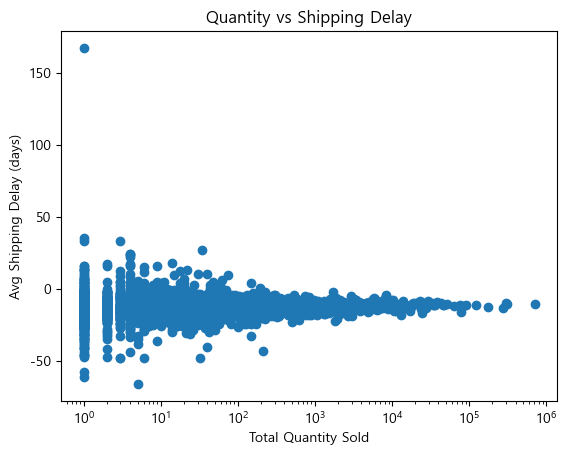

In [44]:
# 판매량 vs 배송 지연

df_eda['shipping_delay'] = (
    pd.to_datetime(df_eda['order_delivered_customer_date']) -
    pd.to_datetime(df_eda['order_estimated_delivery_date'])
).dt.days

delay_qty = df_eda.groupby('seller_id').agg({
    'quantity':'sum',
    'shipping_delay':'mean'
}).reset_index()

plt.scatter(delay_qty['quantity'], delay_qty['shipping_delay'])
plt.xlabel('Total Quantity Sold')
plt.ylabel('Avg Shipping Delay (days)')
plt.title('Quantity vs Shipping Delay')
plt.xscale('log')
plt.show()


- 판매량이 적은 셀러일수록 지연 편차가 매우 크다
- 판매량 1~10개에서 흩어짐 정도가 큼

- +150일 지연 셀러 vs -60일(예정보다 매우 빠름), 0일
- 소량 판매 셀러는 운영 품질이 들쭉날쭉하고 안정성이 매우 낮다.

이유?
배송 프로세스가 안정적으로 구축되지 않음
재고 / 준비 시간 / 물류 협력사가 매번 달라짐?

- 판매량이 늘어날수록 배송 지연이 0
→ 판매량이 높은 셀러는 배송 지연이 거의 없다
→ 운영 효율, 자동화, 파트너 물류 협력사가 안정적으로 구축되어 있음
high-volume seller = 운영 품질이 좋고 배송 지연이 거의 0
- High-volume 셀러에서 outlier가 거의 없음
- 상위 셀러들은 배송 품질이 안정적인 핵심 셀러군

전략: 
신규/저판매량 셀러는 배송 리스크가 매우 크다
→ 초기 지원, 물류 가이드 강화 필요

중/고판매량 셀러는 배송 품질이 안정적
→ 성장을 집중할 가치가 높은 그룹

배송 지연을 리스크 예측 모델의 주요 feature로 활용 가능
→ low-volume sellers + 높은 평균 delay = 문제 셀러 early signal

#### 주문 취소율(is_canceled 평균)

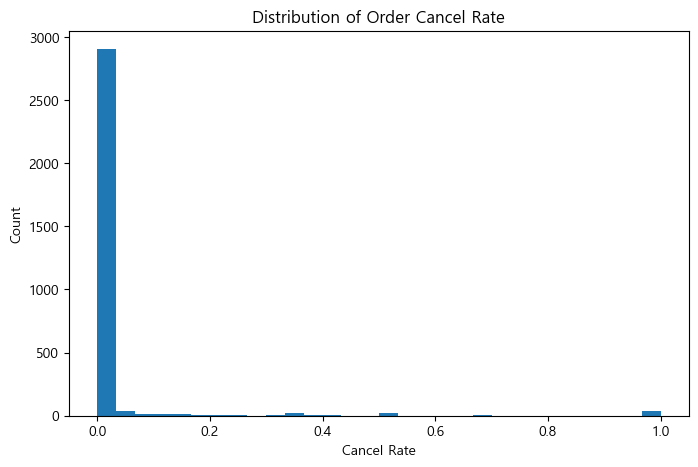

In [45]:
# 주문 취소율 분포

plt.figure(figsize=(8,5))
plt.hist(seller_df['cancel_rate'], bins=30)
plt.xlabel('Cancel Rate')
plt.ylabel('Count')
plt.title('Distribution of Order Cancel Rate')
plt.show()

1) 대부분의 셀러가 취소율이 거의 0에 가까움 (0~0.02 구간에 집중)
- 대부분의 셀러는 주문 취소가 거의 발생하지 않음
- 플랫폼 전체적으로 주문 신뢰도(order reliability) 가 높음

2) 취소율이 1에 찍혀 있는 소수 셀러 
- 1.0(100% 취소율)에 극히 작은 막대가 있음
- **이 셀러들은 받았던 모든 주문이 취소된 극단적인 경우**
- 정상적인 판매 패턴이 아니기 때문에 문제 셀러(outlier) 또는 신규/비활성 셀러일 가능성이 높음

3) 분포가 극도로 비대칭(skewed distribution)
- 거의 모든 값이 0 근처이고 아주 소수만 높은 취소율을 가지고 있음
- 취소율은 평균으로 분석하면 왜곡됨
- median, percentile로 보는 것이 더 적합한 변수

4) 인사이트
- 취소율은 대부분 셀러에게 큰 문제가 아니지만
- 취소율이 높은 소수 셀러는 특별 관리 대상
- CS 문제, 배송 이탈, 잘못된 상품 등록, 재고 부족, 신규 셀러 학습 부족 등 문제 가능성 등의 원인?

취소율 상위 셀러만 별도로 추적하는 “리스크 초기 감지” 지표로 활용 가능

#### product 평균 가격(avg_price)

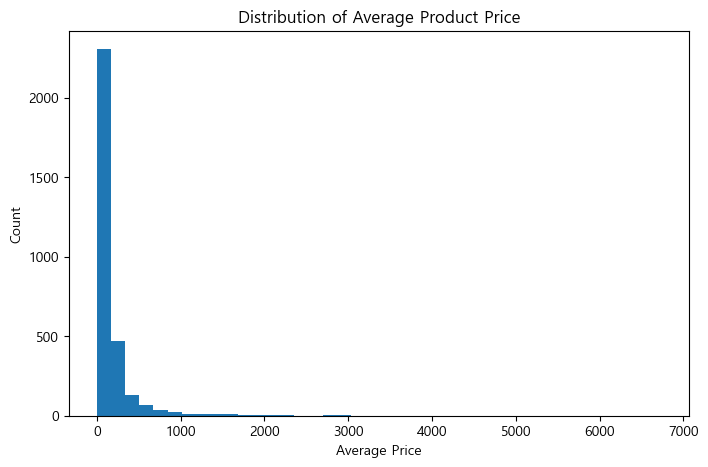

In [46]:
# product 평균 가격

plt.figure(figsize=(8,5))
plt.hist(seller_df['avg_price'], bins=40)
plt.xlabel('Average Price')
plt.ylabel('Count')
plt.title('Distribution of Average Product Price')
plt.show()

#### 그 외 KPI 간 관계 분석

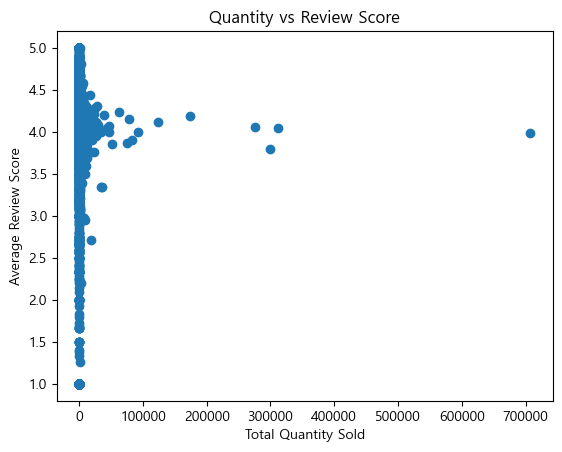

In [47]:
# Quantity vs Review Score: 판매량이 높은 셀러가 고객 만족을 유지하는지?

plt.scatter(seller_df['total_quantity'], seller_df['avg_review'])
plt.xlabel('Total Quantity Sold')
plt.ylabel('Average Review Score')
plt.title('Quantity vs Review Score')
plt.show()


(위에 찍었던 코드, 해석 참고)
판매량이 많다고 해서 리뷰 점수가 높아지는 것은 아니다
둘 사이에 뚜렷한 상관관계가 없다

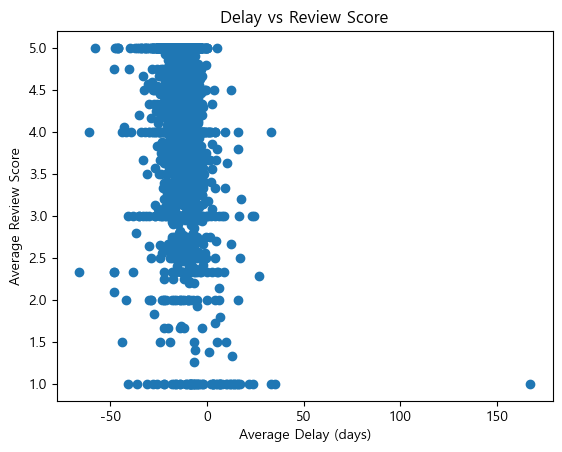

In [48]:
# Delay vs Review Score: 리스크 조기 탐지 변수

plt.scatter(seller_ship['avg_delay_days'], seller_df['avg_review'])
plt.xlabel('Average Delay (days)')
plt.ylabel('Average Review Score')
plt.title('Delay vs Review Score')
plt.show()


(위에 찍었던 코드, 해석 참고) 
배송 지연이 심한 셀러가 리뷰 점수가 낮아지는 경향은 있지만 관계가 완전히 선형적이지는 않다

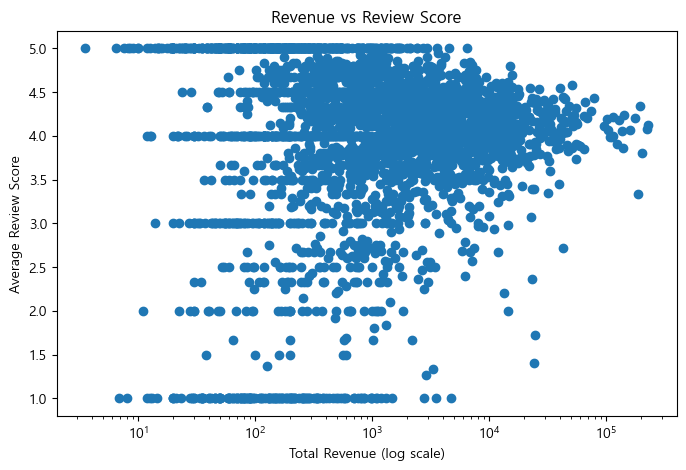

In [49]:
# 매출(total_revenue) vs 리뷰(avg_review): 고매출 셀러가 고객 만족을 유지하는지?

plt.figure(figsize=(8,5))
plt.scatter(seller_df['total_revenue'], seller_df['avg_review'])
plt.xscale('log') 
plt.xlabel('Total Revenue (log scale)')
plt.ylabel('Average Review Score')
plt.title('Revenue vs Review Score')
plt.show()


고매출 셀러가 고객 만족도가 높은지 확인
- 매출과 리뷰는 뚜렷한 양의 상관관계를 보이지 않는다
- 하지만 매출이 높을수록 리뷰 점수가 극단적으로 낮은 셀러는 거의 없음 → 고매출 셀러는 기본적인 품질/CS를 유지한다


1) 매출이 매우 낮은 셀러(왼쪽 구간: 10¹~10³)는 리뷰 점수가 1~5까지 다양
- 소규모 셀러는 리뷰 분포가 불안정하고 편차가 큼
- 리뷰 개수가 적어 1~2개의 리뷰만으로 점수가 크게 요동치는 구조
- 성장팀(Growth Team)이 가장 집중 관리해야 할 불안정 셀러층

2) 매출이 일정 수준 이상(10³~10⁵)으로 올라가면 리뷰 점수는 3~5점 사이로 안정화
- 매출 규모가 커지는 셀러는 리뷰 품질이 안정적으로 유지됨
- 고객 불만(1~2점)이 많은 중대 문제 셀러는 매출을 크게 키우지 못함
- 매출 성장은 고객 경험 관리 능력과 어느 정도 동행한다
- 고매출 셀러는 품질 관리·배송·CS 프로세스가 더 잘 갖춰져 있음

3) 고매출 셀러 중 리뷰가 2점 이하로 내려가는 사례는 거의 없음
- 매출이 높은데 리뷰가 낮다면 비즈니스적으로 지속 불가능
- Olist 플랫폼에서 살아남는 고매출 셀러들은 고객 만족을 최소 기준 이상 유지하고 있음
- “고매출 셀러 = 품질·배송 관리가 안정된 핵심 파트너” 라고 볼 수 있음

4) 강한 선형 관계(매출 ↑ → 리뷰 ↑)는 보이지 않음
- 리뷰는 어느 정도 ceiling effect(상한 효과)가 있음
- 대부분 3.5~5점 사이에 몰려 있어 매출과 함께 증가하는 패턴이 약함

**고객 만족은 매출 증가의 결과라기보다 → 셀러 운영 역량의 기본 요건에 더 가까움**

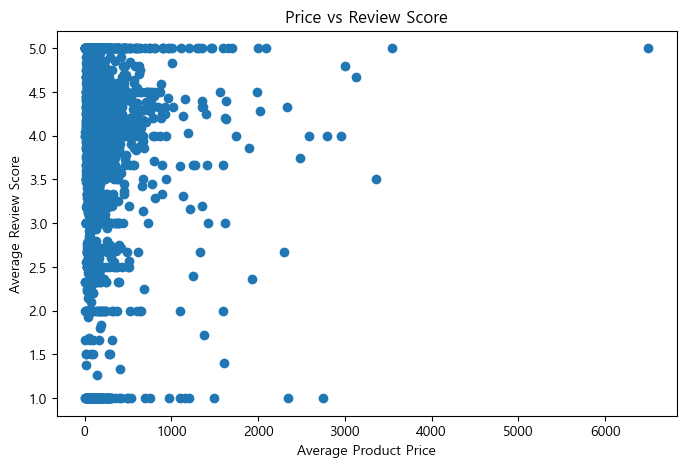

In [50]:
# 평균 가격(avg_price) vs 리뷰(avg_review)
plt.figure(figsize=(8,5))
plt.scatter(seller_df['avg_price'], seller_df['avg_review'])
plt.xlabel('Average Product Price')
plt.ylabel('Average Review Score')
plt.title('Price vs Review Score')
plt.show()


카테고리 전략, 셀러 품질관리 인사이트로 연결 가능

가격이 높다고 해서 리뷰 점수가 높아지는 것은 아니다
대부분의 셀러는 평균 가격이 매우 낮고(0~200), 그 범위에서 리뷰 점수 차이가 크게 나타난다

리뷰 품질은 가격보다는 배송·상품 품질·CS 등에 의해 좌우되는 경향이 더 크다

1) 대다수 셀러의 average price는 0~200 구간에 몰려 있다
- Olist 플랫폼 구조 특성: 저가 제품·대량 판매 위주
- 평균 가격이 1000 이상인 셀러는 극히 소수의 niche/high-end 판매자
- 가격 변수는 매우 오른쪽으로 꼬리가 긴(skewed) 분포

2) 저가 제품 판매 셀러에서도 리뷰 점수는 크게 요동친다 (1~5점 분포 넓음)
- 저가 제품은 품질 편차가 크기 때문에 점수 낮은 리뷰가 쉽게 발생
- 리뷰 수 자체가 적으면 점수 변동성이 더 커짐
- 배송 문제, 오배송 같은 기본 운영 이슈가 가격과 무관하게 리뷰에 영향
- 저가 제품 판매 셀러는 리뷰 관리가 더 어렵다(시장 포지션 특성)

3) 고가 제품(avg_price > 1000)의 리뷰는 대체로 안정적이고 높은 편
- 고가 상품일수록 고객 기대가 높지만
- 실제로는 리뷰 점수가 대체로 4~5점 사이로 유지됨
- 고가 셀러들이 CS/배송/포장 품질이 더 높거나 안정적일 가능성을 시사
- 고가 셀러는 품질 기반 브랜드 운영을 하고 있을 가능성이 높음

4) 전체적으로 price와 review 사이에 뚜렷한 상관관계는 없다
- 선형 관계가 거의 없고, 데이터가 넓게 퍼져 있음
- 고객 만족(리뷰)은 가격 자체보다 상품 품질의 일관성, 배송 경험, CS 대응, 상품 설명의 정확도 같은 요소에 의해 결정됨

→ 즉 가격은 리뷰의 예측 변수로서 중요도가 낮은 변수다

가격은 리뷰 품질을 결정하는 강한 요인은 아니며, 저가 셀러는 리뷰 변동성이 크고 고가 셀러는 고객 만족도가 비교적 안정적으로 유지되는 경향이 있다

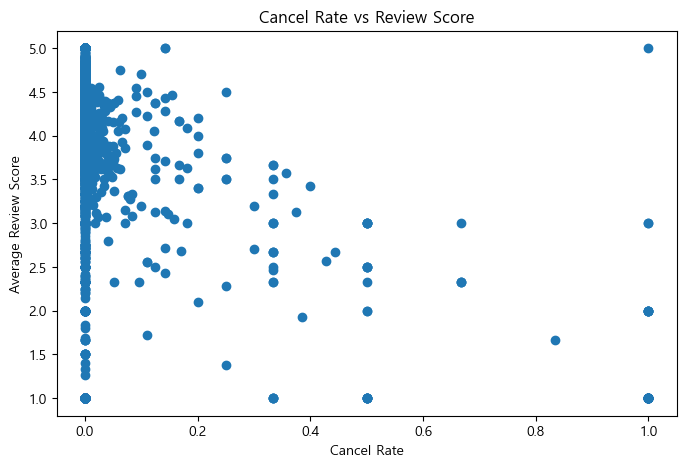

In [51]:
# 취소율(cancel_rate) vs 리뷰(avg_review): CS 품질과 고객경험 관계
plt.figure(figsize=(8,5))
plt.scatter(seller_df['cancel_rate'], seller_df['avg_review'])
plt.xlabel('Cancel Rate')
plt.ylabel('Average Review Score')
plt.title('Cancel Rate vs Review Score')
plt.show()


취소율이 높아질수록 리뷰 점수는 전반적으로 낮아지는 경향이 있다 ?? 취소율은 고객 불만을 반영하는 강력한 CS 품질 지표다

1) 대부분의 셀러는 취소율이 거의 0에 가깝다 (왼쪽에 수직으로 몰림)
- Olist 플랫폼에서 취소율은 대부분 매우 낮음
- 정상 운영 중인 셀러는 리뷰 점수가 3~5점 사이에서 안정적으로 유지됨
- 취소율이 낮은 셀러의 리뷰 품질은 안정적
- 취소율 0~0.05 구간에서 점수 분포가 조밀한 이유

2) 취소율이 0.1~0.5 사이로 증가하면 리뷰 점수가 확실히 낮아지는 패턴이 보임
- 리뷰 점수가 1~3점으로 내려가는 셀러들이 다수 등장
- 주문 취소 경험은 고객 불만족을 초래하고 리뷰 점수 하락으로 이어짐
- 품질 문제, 배송 문제, 재고 부족 등 물류/운영 리스크 가능성
- 취소율 10% 이상은 고객경험 악화의 신호

3) 취소율이 1(=100%)인 셀러는 리뷰 점수가 대부분 매우 낮음
- 몇몇 점들이 5점에 찍혀 있지만 이는 리뷰 수가 매우 적은 신규 셀러일 가능성이 높음
- 일반적으로 취소율 1.0은 심각한 운영 문제
- 상품 등록 오류, 배송 불가, 정책 위반 등 가능성
- 리스크 관리팀이 즉시 개입해야 하는 유형

4) 점들이 퍼져 있지만 전반적 경향은 명확함
- 취소율이 증가할수록 리뷰 점수의 평균이 낮아지고, 분산은 더 커짐

즉불안정한 셀러일수록 고객경험의 일관성이 떨어짐

취소율은 리뷰 점수보다 “더 빠른” 시그널
리뷰가 쌓이기 전에 취소가 먼저 발생하기 때문에

→ 리스크 조기 감지 시스템의 핵심 변수로 활용 가능

취소율이 높은 셀러일수록 리뷰 점수가 낮게 나타나며, 이는 CS·배송·재고 관리 문제를 반영하는 중요한 위험 신호로 활용할 수 있다

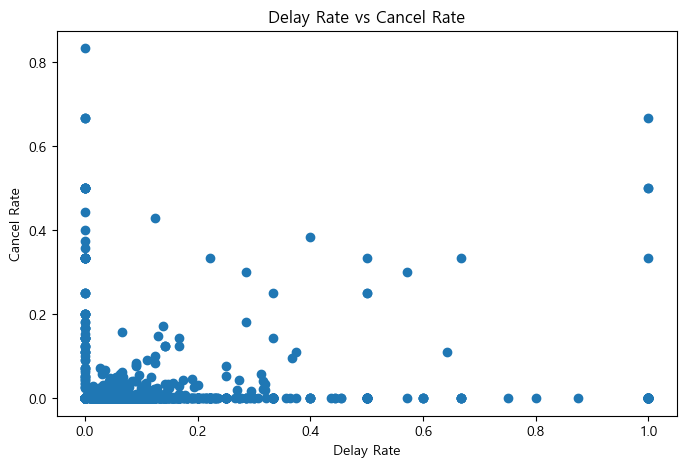

In [52]:
# 배송 지연(delay_rate) vs 취소율(cancel_rate): 배송문제 → 취소로 이어지는지 검증
plt.figure(figsize=(8,5))
plt.scatter(seller_ship['delay_rate'], seller_df['cancel_rate'])
plt.xlabel('Delay Rate')
plt.ylabel('Cancel Rate')
plt.title('Delay Rate vs Cancel Rate')
plt.show()

배송 지연이 높아질수록 취소율이 증가하는 경향
특히 delay_rate가 높은 셀러 대부분은 cancel_rate도 높아지는 패턴을 가진다

1) delay_rate = 0 근처인 셀러 대부분은 cancel_rate도 거의 0
- 지연이 거의 없으면 취소율도 거의 없음
- 이는 배송 품질이 취소율을 결정하는 핵심 요인 중 하나임을 의미
- 정상적으로 운영되는 셀러들의 전형적인 패턴
→ 기본적인 운영 품질이 유지되면 취소는 거의 발생하지 않는다

2) delay_rate가 높아질수록 cancel_rate가 넓게 퍼짐
- delay_rate가 0.2~0.6 사이로 올라가면 cancel_rate도 0.1~0.6 구간으로 증가
- 배송 문제 → 고객 불만 → 주문 취소 로 이어지는 구조
- **배송 지연은 취소 가능성을 높이는 강력한 리스크 요인**
→ 리스크 관리 팀읙 관리 필요

3) delay_rate가 1.0(=100% 전부 지연)인 셀러는 cancel_rate도 매우 높다
몇몇
delay_rate = 1.0
cancel_rate = 0.5 ~ 1.0
- 이런 셀러는 전체 주문이 지연되며 그중 절반 이상이 취소되는 심각한 문제 셀러
→ 즉시 대응/제거 대상
→ 상품 등록 오류, 배송 불가 상태, 사기 셀러 가능성도 있음

배송 지연은 취소율을 설명하는 핵심 원인 중 하나

- 운영 제대로 되는 셀러: delay도 cancel도 모두 낮음
- 운영 문제 있는 셀러: delay가 높고 cancel도 높음

즉, 배송 지연률은 리스크 조기 감지 지표로 매우 유효

배송 지연이 심할수록 취소율이 높아지는 패턴이 명확하게 나타나며, delay_rate는 문제 셀러를 조기 감지하는 핵심 리스크 지표로 활용할 수 있다

In [53]:
seller_df

,seller_id,total_revenue,avg_price,total_products,total_orders,total_quantity,avg_review,cancel_rate,avg_delivery_time_x,avg_delay_days_x,delay_rate_x,avg_delivery_time_y,avg_delay_days_y,delay_rate_y
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,895.000000,1,3,9,3.666667,0.000000,10.333333,-16.333333,0.000000,10.333333,-16.333333,0.000000
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,104.937364,11,200,16633,3.902542,0.000000,12.628205,-13.213675,0.051282,12.628205,-13.213675,0.051282
2,001e6ad469a905060d959994f1b41e4f,250.00,250.000000,1,1,1,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,002100f778ceb8431b7a1020ff7ab48f,1234.50,22.445455,24,51,467,3.981818,0.000000,15.777778,-8.185185,0.166667,15.777778,-8.185185,0.166667
4,003554e2dce176b5555353e4f3555ac8,120.00,120.000000,1,1,1,5.000000,0.000000,4.000000,-27.000000,0.000000,4.000000,-27.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3090,ffcfefa19b08742c5d315f2791395ee5,69.90,69.900000,1,1,1,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
3091,ffdd9f82b9a447f6f8d4b91554cc7dd3,2101.20,105.060000,12,18,60,4.250000,0.000000,9.800000,-12.200000,0.000000,9.800000,-12.200000,0.000000
3092,ffeee66ac5d5a62fe688b9d26f83f534,1839.86,131.418571,3,14,110,4.214286,0.000000,17.642857,-8.357143,0.142857,17.642857,-8.357143,0.142857
3093,fffd5413c0700ac820c7069d66d98c89,9062.30,148.562295,29,60,183,3.866667,0.016393,13.327586,-11.327586,0.120690,13.327586,-11.327586,0.120690


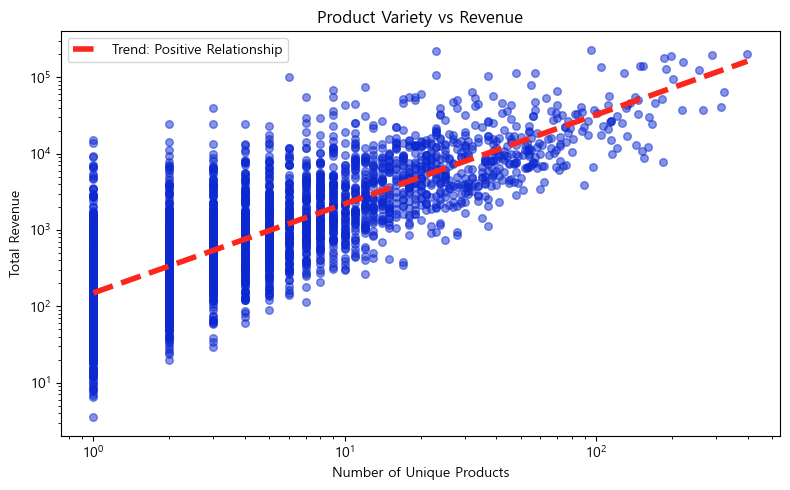

In [54]:
# 상품 다양성(total_products) vs 매출(total_revenue): 제품 다양성 전략 효과
# 데이터
x = seller_df['total_products']
y = seller_df['total_revenue']
# 0 값 제거 (log 스케일 대비)
mask = (x > 0) & (y > 0)
log_x = np.log10(x[mask])
log_y = np.log10(y[mask])
# log-log 선형 회귀
coef = np.polyfit(log_x, log_y, 1)
poly = np.poly1d(coef)
# 추세선용 x
x_fit = np.linspace(log_x.min(), log_x.max(), 200)
y_fit = poly(x_fit)
# 시각화
plt.figure(figsize=(8, 5))
# 산점도 (파란색)
plt.scatter(
    x,
    y,
    color="#0C29D0",
    alpha=0.5,
    s=30
)
# 추세선 (빨간색)
plt.plot(
    10**x_fit,
    10**y_fit,
    color="#FC261D",
    linewidth=4,
    linestyle="--",
    zorder=10,
    label="Trend: Positive Relationship"
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of Unique Products")
plt.ylabel("Total Revenue")
plt.title("Product Variety vs Revenue")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
from scipy.stats import spearmanr
import numpy as np

# 분석에 사용할 컬럼만 선택 + 결측/0 제거
analysis_df = seller_df[
    (seller_df['total_products'] > 0) & 
    (seller_df['total_revenue'] > 0)
][['total_products', 'total_revenue']]

# Spearman correlation
rho, p_value = spearmanr(
    analysis_df['total_products'],
    analysis_df['total_revenue']
)

print(f"Spearman rho: {rho:.4f}")
print(f"p-value: {p_value:.6f}")


Spearman rho: 0.7855
p-value: 0.000000


제품 수가 많아질수록 매출이 증가하는 우상향 경향
즉, 상품 다양성은 셀러 매출 성장의 중요한 성장 레버(growth lever)다

1) 좌하단(상품 수가 1~5개인 셀러)은 매출도 대부분 매우 낮다
- 제품 종류가 적은 셀러는 매출이 10~1,000 사이에서 머무는 경우가 많음
- 단일 제품 전략(single SKU sellers)은 매출 성장에 한계가 있음
- → 입점 초기 셀러는 SKU 확대가 가장 효과적인 성장 전략이라는 시사점.

2) SKU 수가 10~50개로 늘어나면 매출도 10³ ~ 10⁵까지 증가
제품 다양성이 일정 threshold을 넘을 때
    → 고객 유입 증가
    → 노출 증가
    → 교차판매(cross-selling) 증가
- 데이터상 명확히 “우상향” 패턴이 보임
- → SKU 확장은 매출 증가의 강력한 드라이버

3) SKU가 100개 이상인 Top 셀러들은 대부분 고매출 구간(10⁵ 이상)에 
대형 셀러 구조와 동일
카테고리별 재고 풀을 갖추고, 운영 시스템이 안정된 셀러들
리뷰·배송도 비교적 안정적으로 유지하는 경향
- → Olist Growth Team의 전략적 파트너로 육성해야 하는 셀러군

4) 완벽한 선형 관계는 아니지만, 전반적 추세는 명확한 양의 상관관계
상품 다양성이 높을수록 매출 상위권 셀러가 많음
반대로 SKU가 적은데 매출이 높은 outlier는 극히 드묾 → niche category 효과일 가능성
예외적 셀러들을 따로 분석하면 카테고리 전략에 도움됨

신규/저매출 셀러에게
→ SKU 확장(5 → 20개 이상) 을 유도하는 전략 필요

매출 성장 여력이 가장 높은 셀러 유형:
→ 상품 다양성은 있지만 리뷰/배송 문제로 매출이 억제되는 셀러

- SKU 1~5: 매출 대부분이 10¹~10³
- SKU 10~50: 매출 분포가 10³~10⁵까지 급격히 확장, 즉 성장 가속 구간 (growth phase)
- SKU 100 이상: 매출이 거의 대부분 10⁴~10⁵ 이상, 저매출 셀러가 거의 없음
-> SKU ≈ 100은 ‘저매출 셀러가 거의 관측되지 않는 구간’

근거 1. SKU ≥ 100인 셀러 중 total_revenue < 10³ 인 사례가 드묾 (거의 없음)
→ 이는 하위 25% 매출선(1st quartile)이 SKU 100 미만 대비 1~2 자릿수 이상 상승했다는 의미

근거 2. 산점도에서
    - SKU < 50 → 매출 분산 ↑ (성공/실패 공존)
    - SKU ≥ 100 → 매출이 특정 구간 이상에서만 관측
→ 이는 단순 선형 관계가 아니라 임계점 (100) 이후 구조 변화 (regime shift)

근거 3. SKU가 100개 이상이면:
    - 단일 히트 상품 의존 불가
    - 카테고리 분산 → 수요 변동 적음
    - 재고·물류 운영 시스템화 필요
→ Enterprise 셀러 구조와 일치


- SKU 100개 이상부터 저매출 리스크가 급격히 감소하는 구간이 관측된다
- SKU 수가 약 100개를 초과하는 시점부터 저매출 셀러가 거의 존재하지 않으며 매출 분포의 하한선이 뚜렷하게 상승하는 포인트가 나타난다
- SKU 100개: 저성과 셀러가 사라지고 매출 하방이 없어지는 안정화 구간이다

- 통계

H₀ (귀무가설): 상품의 개수 증가와 매출 증가 사이에는 의미 있는 관계가 없다

H₁ (대립가설): 상품의 개수가 증가할수록 매출이 함께 증가하는 경향이 있다

p-value < 0.05 → 귀무가설(H₀) 기각, 대립가설(H₁) 채택

상품 다양성(total_products)과 매출(total_revenue) 간에는 통계적으로 유의미한 강한 양(+)의 단조 관계가 존재한다
-> SKU 수가 많을수록 매출 순위가 높은 셀러일 확률이 매우 높다

## ✔️ Sum UP

### KPI
1. 판매량 vs 리뷰: 판매량이 높다고 리뷰가 꼭 높아지는 것은 아니지만, 고판매량 셀러들은 리뷰 품질이 비교적 안정적으로 유지된다

2. 배송 지연 vs 리뷰: 배송 지연이 증가할수록 리뷰 점수는 뚜렷하게 하락하여 배송 품질이 고객경험의 핵심 결정 요인임을 보여준다

3. 매출 vs 리뷰: 고매출 셀러는 리뷰 점수가 극단적으로 낮아지는 경우가 거의 없어 매출 성장을 위해서는 일정 수준 이상의 고객경험 관리가 필수적이다

4. 평균 가격 vs 리뷰: 가격은 리뷰 점수를 결정하는 강한 요인은 아니며 저가상품 셀러는 리뷰 변동성이 높고 고가상품 셀러는 리뷰가 상대적으로 안정적이다

5. 취소율 vs 리뷰: 취소율이 높아지는 셀러는 리뷰 점수가 전체적으로 낮아져 취소율은 고객 불만족을 조기에 드러내는 핵심 CS 지표가 된다

6. 배송 지연률 vs 취소율: 배송 지연률이 높아지면 취소율도 함께 증가하여 배송 문제가 실제 주문 이탈로 이어지는 구조가 명확히 확인된다

7. 상품 다양성 vs 매출: SKU 다양성이 늘어날수록 매출이 우상향하는 패턴이 분명해 제품 수 확대가 셀러 성장의 주요 성장 레버로 작용한다

### seller 규모별

1. 판매량: Enterprise 셀러는 평균 판매량이 SMB 대비 높고 최소·중간값 수준에서도 격차가 커 규모가 곧 판매력의 차이로 이어진다

2. 매출: Enterprise 셀러는 평균·중앙값 모두 SMB를 수십 배 이상 높으며 상위 매출 분포에서도 안정적인 고매출 구조가 뚜렷하게 나타난다

3. 상품 다양성: Enterprise는 SKU 종류가 많고 카테고리 폭도 넓고 SMB는 소수 SKU 중심의 단일 사업 구조가 대부분이다

4. 리뷰 점수: Enterprise 셀러는 리뷰 점수의 변동성이 적어 품질 관리가 상대적으로 안정적이다 SMB 셀러는 리뷰 분포가 넓어 품질 편차가 더 크게 나타난다

5. 배송 지연률: Enterprise 셀러는 물류 지연률이 일관적으로 낮고 SMB는 운영 리스크로 인해 지연률 편차가 큰 경향을 보인다

6. 취소율: Enterprise 셀러는 취소율이 낮고 안정적이지만 SMB는 취소율이 상대적으로 높아 고객 경험 관리 리스크가 크다

## 주문 컨펌 소요 시간(`confirm_time_min`) 통계 및 시각화

리뷰 평점이 높은, 낮은 그룹의 주문 컨펌 소요 시간 ( = order_approved_at - order_purchase_timestampo) 을 구해서 비교 
→ 리뷰 평점이 높은 그룹의 소요 시간이 평점이 낮은 그룹의 소요시간보다 적다면 고객 경험/만족도를 높이는 패턴이라고 할 수 있음 

In [56]:
# 주문 컨펌 소요 시간 계산
# (order_approved_at - order_purchase_timestamp)

df_eda['order_purchase_timestamp'] = pd.to_datetime(df_eda['order_purchase_timestamp'])
df_eda['order_approved_at'] = pd.to_datetime(df_eda['order_approved_at'])

# 주문 컨펌 소요 시간 (분 단위)
df_eda['confirm_time_min'] = (
    df_eda['order_approved_at'] - df_eda['order_purchase_timestamp']
).dt.total_seconds() / 60

df_confirm = df_eda[df_eda['confirm_time_min'].notna() & (df_eda['confirm_time_min'] >= 0)]

# 리뷰 High vs Low
df_confirm = df_confirm[df_confirm['review_score'].isin([1,2,4,5])]

df_confirm['review_group'] = df_confirm['review_score'].apply(
    lambda x: 'High' if x >= 4 else 'Low'
)

confirm_time_summary = (
    df_confirm.groupby('review_group')['confirm_time_min']
              .describe()
)

confirm_time_summary


,count,mean,std,min,25%,50%,75%,max
review_group,,,,,,,,
High,84342.0,617.177589,1203.816222,0.0,12.933333,20.733333,882.975000,24253.733333
Low,17977.0,704.156892,1846.534867,0.0,13.166667,22.216667,1021.033333,87051.983333


- 리뷰 평점이 높은(High) 주문은 평균·중앙값 기준으로 주문 컨펌 소요 시간이 더 짧다
    - High 그룹 중앙값: 약 20.7분
    - Low 그룹 중앙값: 약 22.2분

- 리뷰 평점이 낮은(Low) 그룹은 컨펌 지연의 변동성과 극단값이 훨씬 크다
    - Low 그룹 최대값: 87,051분 = 60일 10시간 51분
    - High 그룹 최대값: 24,254분 = 16일 20시간 14분

- 이는 주문 승인 지연이 누적될수록 고객 불만이 커지고 낮은 리뷰로 이어질 가능성이 높다
- **주문 승인 속도가 빠를수록 리뷰 평점이 높고, 승인 지연이 반복되거나 극단적으로 길어질 경우 낮은 리뷰로 이어지는 고객 경험 악화 패턴이 명확히 확인된다**

### Mann–Whitney : H₀ (귀무가설): 주문 승인 소요 시간이 리뷰 평점이 높은 주문일수록 더 길다



In [57]:
from scipy.stats import mannwhitneyu

# High / Low 그룹 분리
high = df_confirm.loc[
    df_confirm['review_group'] == 'High',
    'confirm_time_min'
]

low = df_confirm.loc[
    df_confirm['review_group'] == 'Low',
    'confirm_time_min'
]

stat, p_value = mannwhitneyu(high, low, alternative='less')

print(f"Mann–Whitney U stat: {stat:.2f}, p-value: {p_value:.5f}")


Mann–Whitney U stat: 736802550.00, p-value: 0.00000


p-value < 0.05
→ 리뷰 평점이 높은 주문의 주문 컨펌 소요 시간이 통계적으로 유의미하게 더 짧다

검정 결과, 리뷰 평점이 높은 주문은 구매 후 승인까지의 소요 시간이 리뷰 평점이 낮은 주문보다 통계적으로 유의미하게 더 짧다 (p < 0.01)

주문 승인 속도가 초기 고객 경험과 리뷰 만족도에 유의미한 영향을 미친다

In [58]:
q1 = df_confirm["confirm_time_min"].quantile(0.25)
q3 = df_confirm["confirm_time_min"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_confirm_no_out = df_confirm[
    (df_confirm["confirm_time_min"] >= lower) &
    (df_confirm["confirm_time_min"] <= upper)
].copy()


In [59]:
upper = df_confirm["confirm_time_min"].quantile(0.99)

df_confirm_no_out = df_confirm[
    df_confirm["confirm_time_min"] <= upper
].copy()

<Figure size 700x500 with 0 Axes>

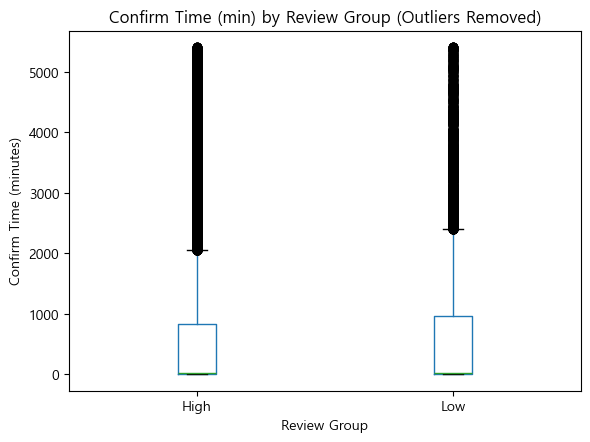

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
df_confirm_no_out.boxplot(column="confirm_time_min", by="review_group", grid=False)

plt.title("Confirm Time (min) by Review Group (Outliers Removed)")
plt.suptitle("")
plt.xlabel("Review Group")
plt.ylabel("Confirm Time (minutes)")
plt.show()


### 리뷰 그룹별 주문 확정 소요 시간 (로그 스케일)

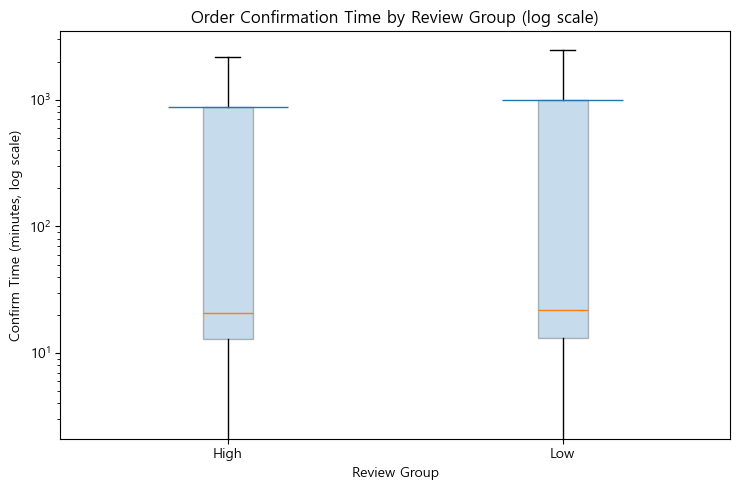

In [ ]:
# df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
# df["order_approved_at"] = pd.to_datetime(df["order_approved_at"])

df_eda["confirm_time_min"] = (df_eda["order_approved_at"] - df_eda["order_purchase_timestamp"]).dt.total_seconds() / 60

df_confirm = df_eda[df_eda["confirm_time_min"].notna() & (df_eda["confirm_time_min"] >= 0)].copy()

# review_score 1~5만 사용
df_confirm = df_confirm[df_confirm["review_score"].isin([1, 2, 3, 4, 5])].copy()

# High: 4~5, Low: 1~3
df_confirm["review_group"] = np.where(df_confirm["review_score"] >= 4, "High", "Low")

# 발표용 Figure 1: log boxplot + median 라벨 + upper tail 주석
groups = ["High", "Low"]
data_list = [df_confirm.loc[df_confirm["review_group"] == g, "confirm_time_min"].values for g in groups]

def upper_whisker(vals):
    s = pd.Series(vals)
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    uw = s[s <= q3 + 1.5 * iqr].max()  # 이상치 제외 upper whisker
    return float(q3), float(uw), float(s.median())

fig, ax = plt.subplots(figsize=(7.5, 5))

bp = ax.boxplot(
    data_list,
    tick_labels=groups,
    showfliers=False,
    patch_artist=True
)

# 박스 채우기 
for box in bp["boxes"]:
    box.set(alpha=0.25)

ax.set_yscale("log")
ax.set_title("Order Confirmation Time by Review Group (log scale)")
ax.set_xlabel("Review Group")
ax.set_ylabel("Confirm Time (minutes, log scale)")

# 중앙값 + upper tail 화살표 주석
for i, g in enumerate(groups, start=1):
    q3, uw, med = upper_whisker(df_confirm.loc[df_confirm["review_group"] == g, "confirm_time_min"].values)

    # median 라벨
    # ax.text(i, med, f"median: {med:.1f}m", ha="center", va="bottom", fontsize=9)

    # # upper tail 구간 강조 (Q3 -> upper whisker)
    # ax.annotate(
    #     "upper tail\n(delay-heavy cases)",
    #     xy=(i, uw),
    #     xytext=(i + 0.18, uw * 1.8),
    #     arrowprops=dict(arrowstyle="->", lw=1.2),
    #     fontsize=9
    # )

    # Q3 위치도 얇게 표시 (선택)
    ax.hlines(q3, i - 0.18, i + 0.18, linewidth=1)

fig.tight_layout()
plt.show()


### 리뷰 그룹별 주문 확정 소요 시간 분포 (로그 스케일)

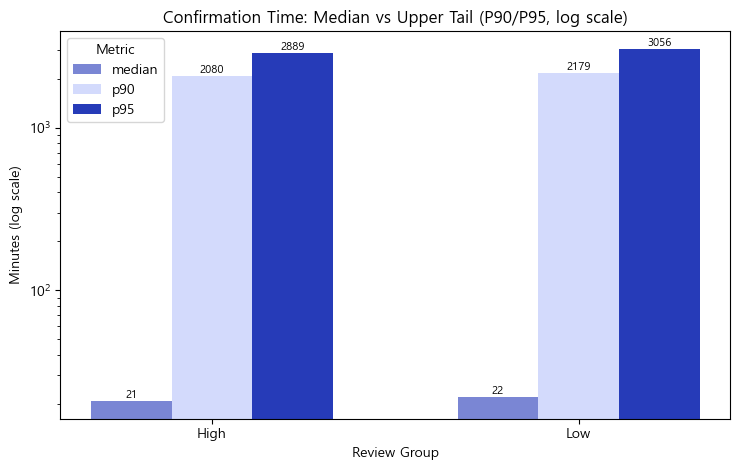

In [ ]:
colors = {
    "median": "#7a86d4",  # 중간값
    "p90": "#d3dafc",     # 상위 10%
    "p95": "#263bb8"      # 상위 5% (강조)
}

# 발표용 Figure 2: median / P90 / P95 비교 막대 (꼬리 차이 한 방에)
summary = (
    df_confirm.groupby("review_group")["confirm_time_min"]
    .agg(
        median="median",
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95)
    )
    .reindex(groups)
)

metrics = ["median", "p90", "p95"]
x = np.arange(len(groups))
width = 0.22

fig, ax = plt.subplots(figsize=(7.5, 4.8))

for j, m in enumerate(metrics):
    ax.bar(x + (j - 1) * width, summary[m].values, width=width, label=m, color=colors[m])

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_title("Confirmation Time: Median vs Upper Tail (P90/P95, log scale)")
ax.set_xlabel("Review Group")
ax.set_ylabel("Minutes (log scale)")
ax.legend(title="Metric")

# 값 라벨(선택):
for j, m in enumerate(metrics):
    for i in range(len(groups)):
        val = summary.iloc[i][m]
        ax.text(x[i] + (j - 1) * width, val, f"{val:.0f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plt.show()


## 물류사 전달 소요 시간(`purchase_to_carrier_min`) 통계 및 시각화

### Mann–Whitney : H₀ (귀무가설): 리뷰 평점이 높은 주문은 낮은 주문보다 주문 이후 물류사 전달까지의 소요 시간이 더 길다

                count         mean          std       min      25%  \
review_group                                                         
High          84093.0  4340.469257  4320.352909  0.533333  1594.65   
Low           26255.0  6016.129498  7185.792559  1.416667  1885.20   

                      50%          75%        max  
review_group                                       
High          3080.750000  5688.566667  181116.75  
Low           4047.066667  7173.683333  150202.80  


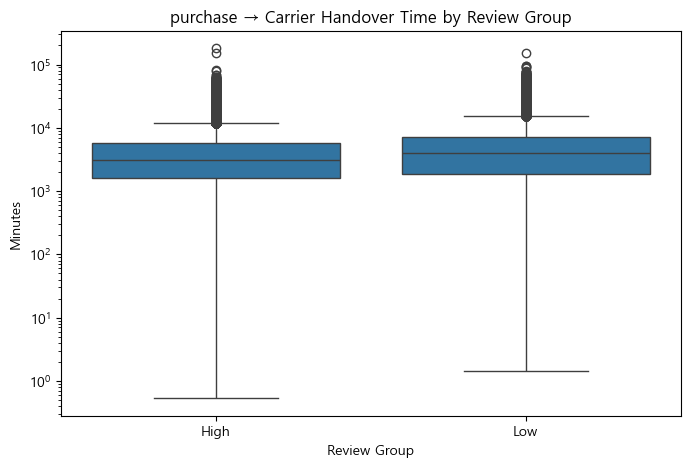

Mann–Whitney U stat: 950047296.00, p-value: 0.00000


In [63]:
from scipy.stats import mannwhitneyu

df_eda["order_purchase_timestamp"] = pd.to_datetime(df_eda["order_purchase_timestamp"], errors="coerce")
df_eda["order_delivered_carrier_date"] = pd.to_datetime(df_eda["order_delivered_carrier_date"], errors="coerce")


#  구매 → 물류사 인계까지 소요 시간(분)
df_eda['purchase_to_carrier_min'] = (
    df_eda['order_delivered_carrier_date'] - df_eda['order_purchase_timestamp']
).dt.total_seconds() / 60

# 리뷰 그룹 (4~5점 = High, 1~3점 = Low)
df_eda = df_eda[df_eda['review_score'].notna()]
df_eda['review_group'] = np.where(df_eda['review_score'] >= 4, 'High', 'Low')

analysis_df = df_eda[
    (df_eda['purchase_to_carrier_min'].notna()) &
    (df_eda['purchase_to_carrier_min'] >= 0)
]

summary = (
    analysis_df.groupby('review_group')['purchase_to_carrier_min']
               .describe()
)
print(summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=analysis_df, x='review_group', y='purchase_to_carrier_min')
plt.title('purchase → Carrier Handover Time by Review Group')
plt.xlabel('Review Group')
plt.ylabel('Minutes')
plt.yscale('log')
plt.show()

high = analysis_df.loc[analysis_df['review_group'] == 'High', 'purchase_to_carrier_min']
low = analysis_df.loc[analysis_df['review_group'] == 'Low', 'purchase_to_carrier_min']

stat, p_value = mannwhitneyu(high, low, alternative='less')
print(f"Mann–Whitney U stat: {stat:.2f}, p-value: {p_value:.5f}")


승인 → 물류사 인계 소요 시간 (분)

중앙값(50%) 기준
    - High 리뷰 그룹: 4,373분 ≈ 3.04일
    - Low 리뷰 그룹: 5,653분 ≈ 3.93일
→ 리뷰 평점이 높은 주문은 물류사 전달까지 약 0.89일 더 빠름

최대값
    - High: 348.84일
    - Low: 357.54일
→ 극단값은 존재하지만, 분포 전반은 Low 그룹이 더 나쁨

시각화
Low 리뷰 그룹은
    - 중앙값이 더 위에 있고
    - IQR(박스 높이)이 더 크다
→ 일관성 없이 늦어지는 주문이 많다는 의미
→ 고객 경험의 ‘불안정성’이 큼

H₀ (귀무가설): 리뷰 평점 High와 Low의 배송 인계 소요 시간 차이가 없다
H₁ (대립가설): 리뷰 평점이 높은 주문은 리뷰 평점이 낮은 주문보다 주문 승인 이후 물류사에 전달되기까지의 소요 시간이 더 짧다


- 결과: 귀무가설 기각
- p-value < 0.05라서 리뷰 평점이 높은 주문이 통계적으로 유의미하게 더 빠르게 물류사에 전달됨

- 리뷰 평점이 높은 주문은 주문 승인 이후 물류사로 전달되는 속도가 더 빠르고, 이 차이는 통계적으로도 유의미하여 ‘초기 물류 대응 속도’가 고객 만족의 핵심 요인임이 확인된다

### 리뷰 그룹별 구매 → 배송 인계 소요 시간 (로그 스케일)
min 값에 1440 나눠서 일수 구함

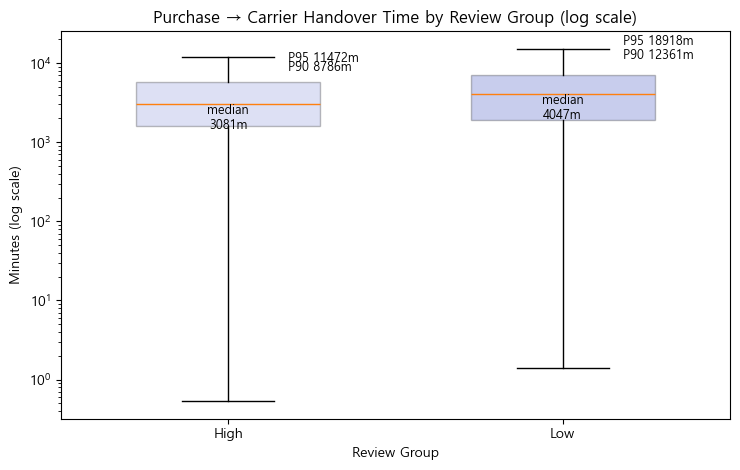

In [64]:
# 요약 통계 (median/p90/p95)
summary = (
    analysis_df.groupby("review_group")["purchase_to_carrier_min"]
    .agg(
        median="median",
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        n="count"
    )
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))

data_list = [
    analysis_df.loc[analysis_df["review_group"] == "High", "purchase_to_carrier_min"].values,
    analysis_df.loc[analysis_df["review_group"] == "Low", "purchase_to_carrier_min"].values
]

bp = ax.boxplot(
    data_list,
    tick_labels=["High", "Low"],
    showfliers=False,      # 점 제거(발표 가독성)
    patch_artist=True,
    widths=0.55
)

# 색 
box_colors = ["#7a86d4", "#263bb8"]
for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.25)

ax.set_yscale("log")
ax.set_title("Purchase → Carrier Handover Time by Review Group (log scale)")
ax.set_xlabel("Review Group")
ax.set_ylabel("Minutes (log scale)")

# 수치 주석: median / P90 / P95
for i, g in enumerate(["High", "Low"], start=1):
    med = summary.loc[g, "median"]
    p90 = summary.loc[g, "p90"]
    p95 = summary.loc[g, "p95"]

    ax.text(i, med, f"median\n{med:.0f}m", ha="center", va="top", fontsize=9)
    ax.text(i + 0.18, p90, f"P90 {p90:.0f}m", ha="left", va="center", fontsize=9)
    ax.text(i + 0.18, p95, f"P95 {p95:.0f}m", ha="left", va="center", fontsize=9)

fig.tight_layout()
plt.show()


### 중앙값 대비 상위 구간 비교 (P90/P95, 로그 스케일)

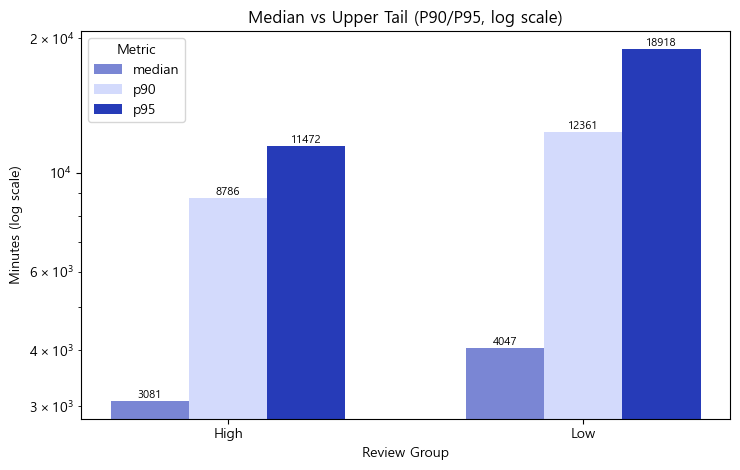

In [65]:
metrics = ["median", "p90", "p95"]
colors = {"median": "#7a86d4", "p90": "#d3dafc", "p95": "#263bb8"}

x = np.arange(2)  # High, Low
width = 0.22

fig, ax = plt.subplots(figsize=(7.5, 4.8))

for j, m in enumerate(metrics):
    ax.bar(
        x + (j - 1) * width,
        [summary.loc["High", m], summary.loc["Low", m]],
        width=width,
        label=m,
        color=colors[m]
    )

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(["High", "Low"])
ax.set_title("Median vs Upper Tail (P90/P95, log scale)")
ax.set_xlabel("Review Group")
ax.set_ylabel("Minutes (log scale)")
ax.legend(title="Metric")

# 라벨
for j, m in enumerate(metrics):
    for i, g in enumerate(["High", "Low"]):
        val = summary.loc[g, m]
        ax.text(x[i] + (j - 1) * width, val, f"{val:.0f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plt.show()


# 2️⃣ SMB -> K-Means 피처 탐색

## 1) SMB 파일 생성 (`df_smb_vF`)

In [66]:
df_copy = pd.read_csv("merged_df_segment_Final.csv")

In [67]:
df_copy.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'delivery_delay_days', 'is_delayed',
       'is_canceled', 'product_category_name', 'product_category_name_english',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'seller_city_clean', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'review_id', 'review_score',
       'review_comment_message', 'review_creation_date',
       'geolocation_zip_code_prefix', 'lat_mode', 'lng_mode',
       'geolocation_city', 'geolocation_state', 'seller_total_revenue',
       'segment'],
      dtype='object')

In [68]:
# 주문 취소 제거
df_copy = df_copy[df_copy['is_canceled'] == 0].copy()

# SMB / Enterprise 분리
df_smb_full = df_copy[df_copy['segment'] == 'SMB'].copy()
df_ent_full = df_copy[df_copy['segment'] == 'Enterprise'].copy()

In [69]:
print(df_smb_full.shape)

(53497, 38)


In [70]:
ordered_cols = [
    # 식별자
    'order_id',
    'product_id',
    'seller_id',

    # 주문 시간
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',

    # 리뷰
    'review_id',
    'review_score',

    # 상품 / 주문 금액
    'price',

    # 셀러 정보
    'segment',
    'seller_total_revenue',
]


df_smb = df_smb_full[ordered_cols].copy()
display(df_smb.head())
print(df_smb.shape)

,order_id,product_id,seller_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,review_id,review_score,price,segment,seller_total_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,97ca439bc427b48bc1cd7177abe71365,5.0,58.90,SMB,12271.71
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,7b07bacd811c4117b742569b04ce3580,4.0,239.90,SMB,9178.51
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,0c5b33dea94867d1ac402749e5438e8b,5.0,199.00,SMB,3280.00
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,f4028d019cb58564807486a6aaf33817,4.0,12.99,SMB,1054.82
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,940144190dcba6351888cafa43f3a3a5,5.0,199.90,SMB,3661.18


(53497, 11)


In [71]:
df_smb.isnull().sum().sort_values(ascending=False)

order_delivered_carrier_date    545
review_id                       480
review_score                    480
order_approved_at                 8
seller_id                         0
order_id                          0
product_id                        0
order_purchase_timestamp          0
price                             0
segment                           0
seller_total_revenue              0
dtype: int64

In [72]:
# 결측치 제거
df_smb = df_smb.dropna(subset=["order_delivered_carrier_date", 'review_score','order_approved_at'])

In [ ]:
# 저장
# df_smb.to_csv('df_smb_2.csv', index=False)

In [74]:
df_smb_vF = pd.read_csv('df_smb_2.csv')

In [75]:
display(df_smb_vF.head())
df_smb_vF["seller_id"].nunique()

,order_id,product_id,seller_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,review_id,review_score,price,segment,seller_total_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2010-02-17 10:56,2010-02-17 11:07,2010-04-17 19:55,a54f0611adc9ed256b57ede6b6eb5114,4,29.99,SMB,2349.94
1,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2013-02-18 21:18,2013-02-18 22:20,2014-02-18 19:46,e50934924e227544ba8246aeb3770dd4,5,19.90,SMB,6109.44
2,76c6e866289321a7c93b82b54852dc33,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,2023-01-17 18:29,2025-01-17 2:50,2026-01-17 14:16,fc4af8aea8ec3f1a3cd181d3d0cadbd5,1,19.90,SMB,139.50
3,82566a660a982b15fb86e904c8d32918,72a97c271b2e429974398f46b93ae530,094ced053e257ae8cae57205592d6712,2006-07-18 10:06,2006-09-18 3:13,2006-11-18 13:29,ed220e853e96b629118a3576e02900b6,5,31.90,SMB,1519.20
4,432aaf21d85167c2c86ec9448c4e42cc,72d3bf1d3a790f8874096fcf860e3eff,0bae85eb84b9fb3bd773911e89288d54,2003-01-18 14:14,2003-01-18 15:10,2003-02-18 21:09,8f39f09c22b1ceb6e3eb178d8e50bb8a,4,38.25,SMB,7482.21


2639

## 2) 파생 컬럼 생성

피처 컬럼명 정리

- 셀러별 총 매출: seller_total_revenue
- 셀러 상품 고유 개수: n_unique_products
- 셀러별 평균 리뷰 점수: avg_review_score
- 4, 5점 리뷰 비율: high_review_ratio
- 주문 승인 소요 시간: confirm_time_min
- 택배사 전달 소요 시간: purchase_to_carrier_min
- 주문당 평균 수량: avg_quantity_per_order

In [76]:
# 셀러 상품 고유 개수 = product id 고유 개수 
df_smb_vF["n_unique_products"] = (
    df_smb_vF.groupby("seller_id")["product_id"]
      .transform("nunique"))

In [77]:
# 셀러별 평균 리뷰 점수: avg_review_score
df_smb_vF["avg_review_score"] = (
    df_smb_vF
    .groupby("seller_id")["review_score"]
    .transform("mean")
)
df_smb_vF["avg_review_score"] = df_smb_vF["avg_review_score"].round(2)

In [78]:
# High 리뷰 여부 컬럼 생성 (리뷰 단위)
df_smb_vF["is_high_review"] = np.where(
    df_smb_vF["review_score"] >= 4,
    1,
    0
)

In [79]:
# 리뷰 그룹
df_smb_vF['review_group'] = df_smb_vF['review_score'].apply(
    lambda x: 'High' if x >= 4 else 'Low'
)

In [80]:
# seller별 High 리뷰 비율 계산
high_review_ratio_df = (
    df_smb_vF
    .groupby("seller_id")["is_high_review"]
    .mean()
    .reset_index()
    .rename(columns={"is_high_review": "high_review_ratio"})
)

In [81]:
# seller-level df에 병합
df_smb_vF = df_smb_vF.merge(
    high_review_ratio_df,
    on="seller_id",
    how="left"
)

In [82]:
# datetime 변환
time_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date"
]
for col in time_cols:
    df_smb_vF[col]  = pd.to_datetime(df_smb_vF[col], errors='coerce')

In [83]:
# 주문 승인 소요 시간: confirm_time_min
df_smb_vF["confirm_time_min"] = (
    (df_smb_vF["order_approved_at"] - df_smb_vF["order_purchase_timestamp"])
    .dt.total_seconds() / 60
)
print(f"NA 개수: {df_smb_vF['confirm_time_min'].isna().sum()}")

NA 개수: 0


In [84]:
# 택배사 전달 소요 시간: purchase_to_carrier_min
df_smb_vF["purchase_to_carrier_min"] = (
    (df_smb_vF["order_delivered_carrier_date"] - df_smb_vF["order_purchase_timestamp"])
    .dt.total_seconds() / 60
)
print(f"NA 개수: {df_smb_vF['purchase_to_carrier_min'].isna().sum()}")
print(f"음수값 개수: {df_smb_vF['purchase_to_carrier_min'].lt(0).sum()}")  # 음수값 여부

NA 개수: 0
음수값 개수: 2699


In [85]:
df_smb_vF['seller_id'].nunique()

2639

In [86]:
df_smb_vF['purchase_to_carrier_min'].describe()

count    4.460400e+04
mean    -1.149500e+06
std      1.090402e+07
min     -5.207138e+07
25%      4.493875e+04
50%      5.254360e+05
75%      1.052807e+06
max      4.790745e+07
Name: purchase_to_carrier_min, dtype: float64

In [87]:
# 내보내기
df_smb_vF.to_csv(
    "df_smb_seller_level_final.csv",
    index=False,
    encoding="utf-8-sig"
)

## 3) `seller_id` 단위로 groupby

In [88]:
df_seller_level = (
    df_smb_vF
    .groupby("seller_id", as_index=False)
    .agg({
        "seller_total_revenue": "first",
        "n_unique_products": "first",
        "avg_review_score": "first",
        "high_review_ratio": "first",
        "confirm_time_min": "mean",
        "purchase_to_carrier_min": "mean"
    })
)

In [89]:
df_seller_level.shape

(2639, 7)

## 4) ML 피처 결정

- 셀러별 총 매출: seller_total_revenue
- 셀러 상품 고유 개수: n_unique_products
- 셀러별 평균 리뷰 점수: avg_review_score
- 4, 5점 리뷰 비율: high_review_ratio
- 주문 승인 소요 시간: confirm_time_min
- 택배사 전달 소요 시간: purchase_to_carrier_min
- 주문당 평균 수량: avg_quantity_per_order

In [90]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(df_seller_level, features):
    """
    df: 전체 데이터프레임
    features: VIF 계산할 컬럼 리스트
    """
    X = df_seller_level[features].copy()
    X = X.dropna()   # 결측치 제거
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                       for i in range(len(X.columns))]
    return vif_data

In [91]:
# 사용
features = [
    'seller_total_revenue',
    'n_unique_products',
    'avg_review_score',
    # 'high_review_ratio',
    'confirm_time_min',
    'purchase_to_carrier_min',
    # 'avg_quantity_per_order'
]
vif_df = calculate_vif(df_seller_level, features)
print(vif_df)

                   feature       VIF
0     seller_total_revenue  2.340709
1        n_unique_products  2.144422
2         avg_review_score  1.572126
3         confirm_time_min  1.143224
4  purchase_to_carrier_min  1.166522


In [92]:
# ML용 피처 후보만 모아서
features = [
    'seller_total_revenue',
    'n_unique_products',
    'high_review_ratio',
    'confirm_time_min',
    'purchase_to_carrier_min'
]

ml_features = df_seller_level[features].copy()


In [93]:
def check_histogram(df, columns, bins=30):
    """
    분포 + 이상치 확인용 함수
    - histogram (kde 포함)
    - boxplot
    """
    # 히스토그램
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=columns, bins=bins, kde=True)
    plt.title(f'Histogram of {columns}')
    plt.show()
    # 박스플롯
    plt.figure(figsize=(6, 2))
    sns.boxplot(data=df, x=columns)
    plt.title(f'Boxplot of {columns}')
    plt.show()

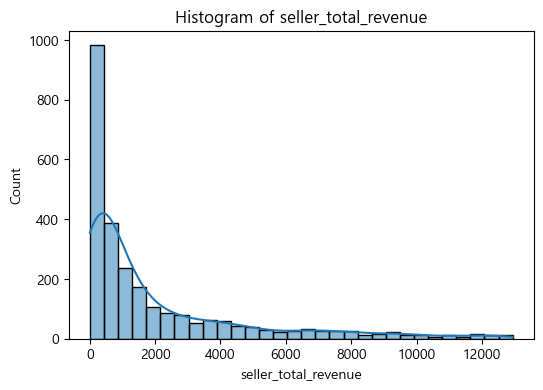

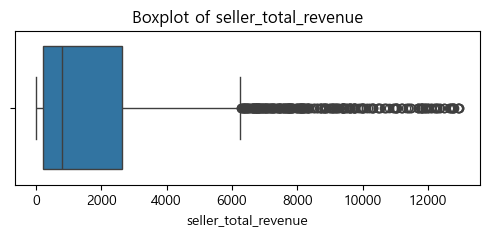

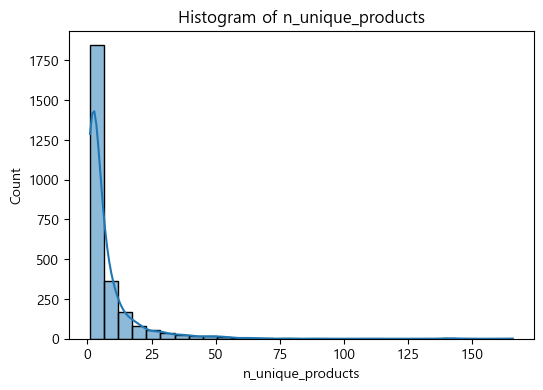

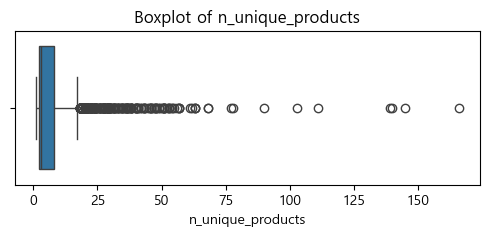

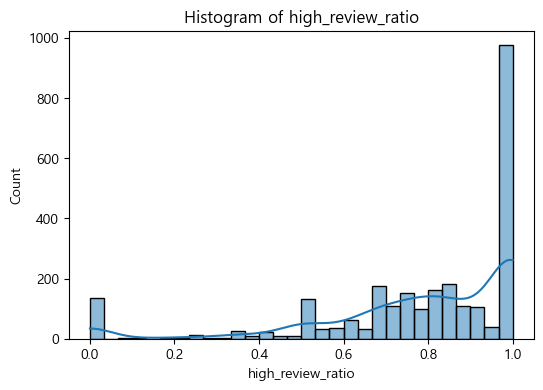

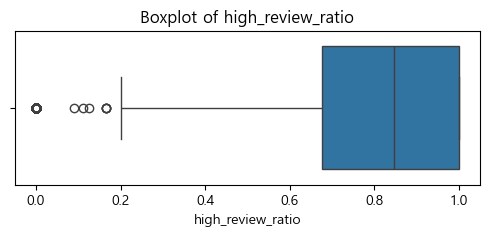

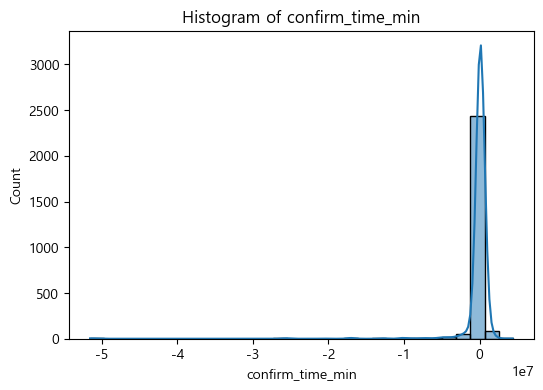

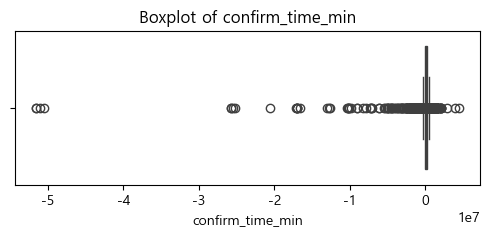

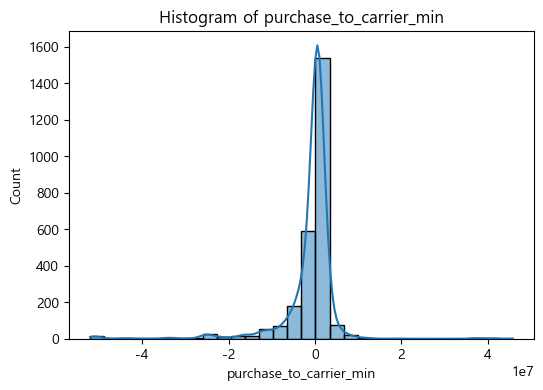

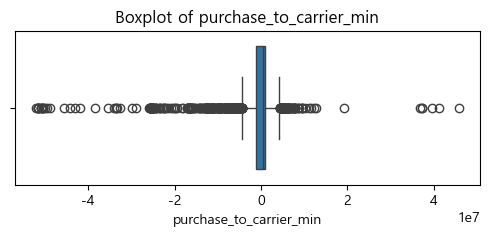

In [94]:
# 매출
check_histogram(ml_features, 'seller_total_revenue', 30)

# 셀러 상품 고유 개수
check_histogram(ml_features, 'n_unique_products', 30)

# 리뷰 비율
check_histogram(ml_features, 'high_review_ratio', 30)

# 주문 승인 소요 시간
check_histogram(ml_features, 'confirm_time_min', 30)

# 택배사 전달 소요 시간
check_histogram(ml_features, 'purchase_to_carrier_min', 30)


## 5) 피처 전처리

In [95]:
# 매출 로그 변환
ml_features['seller_total_revenue_log'] = np.log1p(
    ml_features['seller_total_revenue']
)

# 상품 고유 개수 로그 변환
ml_features['n_unique_products_log'] = np.log1p(
    ml_features['n_unique_products']
)


# 주문 승인 소요 시간 로그 변환
ml_features['confirm_time_min_log'] = np.log1p(
    ml_features['confirm_time_min']
)

# 택배사 전달 소요 시간 로그 변환
ml_features['purchase_to_carrier_min_log'] = np.log1p(
    ml_features['purchase_to_carrier_min']
)


c:\Users\LG\OneDrive\Desktop\sparta_python\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\LG\OneDrive\Desktop\sparta_python\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


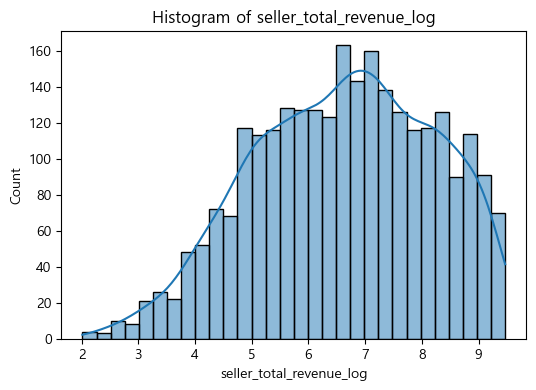

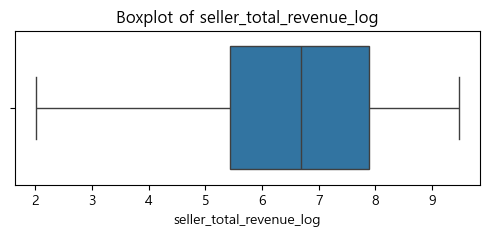

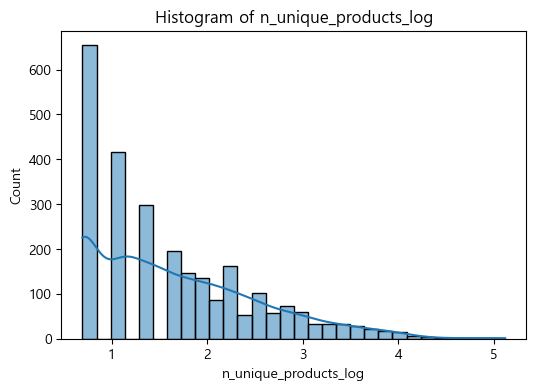

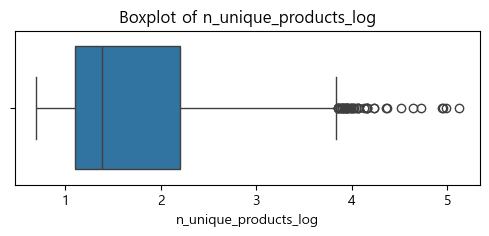

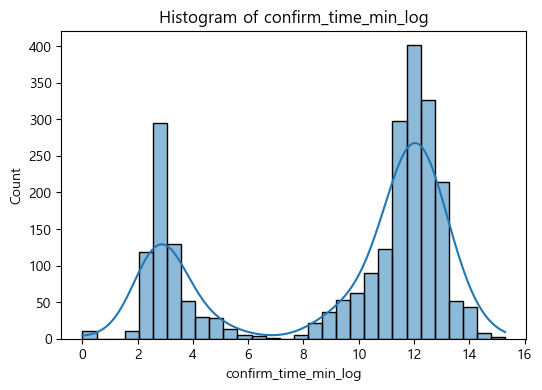

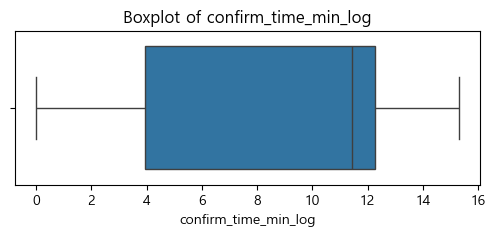

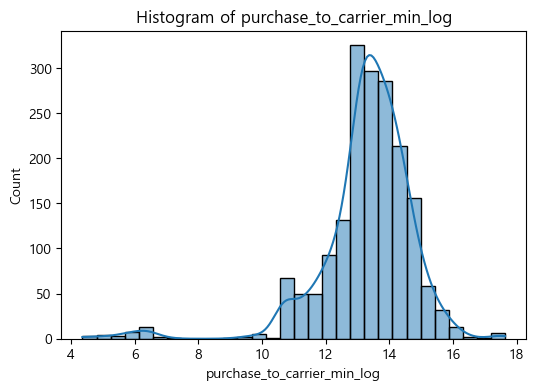

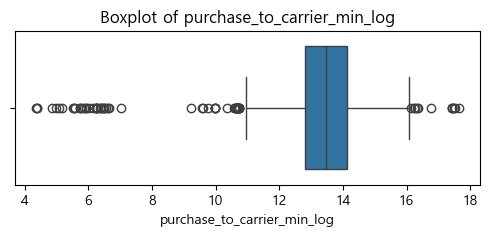

In [96]:
check_histogram(ml_features, 'seller_total_revenue_log', 30)
check_histogram(ml_features, 'n_unique_products_log', 30)
check_histogram(ml_features, 'confirm_time_min_log', 30)
check_histogram(ml_features, 'purchase_to_carrier_min_log', 30)


In [97]:
ml_features.columns.tolist()

['seller_total_revenue',
 'n_unique_products',
 'high_review_ratio',
 'confirm_time_min',
 'purchase_to_carrier_min',
 'seller_total_revenue_log',
 'n_unique_products_log',
 'confirm_time_min_log',
 'purchase_to_carrier_min_log']

In [98]:
final_features = [
    # 셀러 매출
    'seller_total_revenue_log',

    # 상품 SKU
    'n_unique_products_log',

    # 리뷰 평점 high 비율
    'high_review_ratio',    

    # 운영 - 고객만족도
    'confirm_time_min_log',
    'purchase_to_carrier_min_log'
]
ml_features_final = ml_features[final_features].copy()

In [99]:
# 저장
# ml_features_final.to_csv("ml_features_final.csv", index=False)

### ML Feature 전처리 기준 정리 (통합)

공통 원칙
- 셀러 단위 집계 데이터이므로 극단값은 오류가 아닌 의미 있는 신호로 판단
- 이상치 제거 및 평균 대체는 적용하지 않음
- 분포 왜곡 문제는 로그 변환과 스케일링으로 해결

---

1. seller_total_revenue
- 분포: 우측 꼬리 존재하나 자연스러운 셀러 규모 분포
- 처리:
  - log1p 변환 적용
  - 로그 + 클리핑 비교 결과 추가 개선 효과 없음 → 클리핑 미적용
- 최종 사용: seller_total_revenue_log

---

2. n_unique_products
- 분포: 강한 우측 편향 (다품종 셀러 소수)
- 처리:
  - log1p 변환 적용
  - 로그 후 분포 안정 → 클리핑 미적용
- 최종 사용: n_unique_products_log

---

3. high_review_ratio
- 정의: (4~5점 리뷰 수) / (전체 리뷰 수)
- 특성: 0~1 bounded 변수
- 처리:
  - 로그 변환 불필요
  - 스케일링만 적용
- 최종 사용: high_review_ratio

---

4. confirm_time_min
- 분포: 극단적 우측 꼬리 (분 단위, 최대 수십만 분)
- 해석: 승인 지연 셀러 = 운영 리스크 신호
- 처리:
  - log1p 변환 적용
  - 클리핑 비교 후 최종 미적용
- 최종 사용: confirm_time_min_log

---

5. purchase_to_carrier_min
- 분포: 배송 지연 셀러 존재
- 처리:
  - log1p 변환 적용
  - 클리핑 비교 후 최종 미적용
- 최종 사용: purchase_to_carrier_min_log

---

6. avg_review_score / avg_quantity_per_order
- 분포 안정
- 처리: 스케일링만 적용


# 3️⃣ SMB K-Means

In [100]:
ml_features_final_F = pd.read_csv("ml_features_final.csv")
df_smb_f = pd.read_csv("df_smb_seller_level_final.csv")

## 1) 엘보우 그래프
- ml_features : 전처리 된 테이블 사용
- 그래프가 큰 폭으로 감소하는 k 후보를 추려서 실루엣 계수와 종합하여 최적의 k를 선정

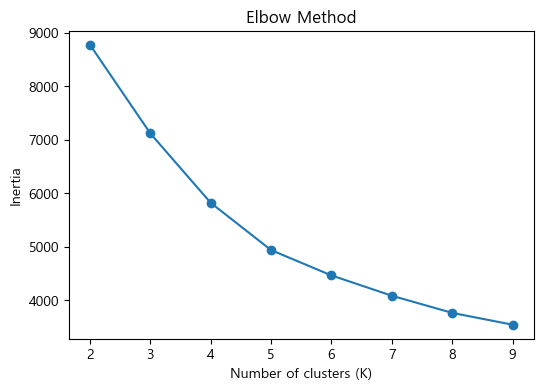

In [101]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ===============================================
# 추가된 내용: NA 값 제거
# -----------------------------------------------
ml_features_final_dropped = ml_features_final_F.dropna()

# 스케일링
X_scaled = StandardScaler().fit_transform(ml_features_final_dropped) # standard scaler로 스케일링
# ===============================================

inertias = []
K_range = range(2, 10) # 임의의 k 범위 (더 많은 범위를 보기 원하시면 범위를 넓히셔서 진행 하시면 됩니다.)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42, # 결과 고정을 위한 장치
        n_init=10 # 서로 다른 초기 중심값으로 K-Means를 몇 번 반복할지
    )
    km.fit(X_scaled) # 선언한 모델로 스케일링 된 피쳐를 학습 
    inertias.append(km.inertia_) # 군집 내 제곱거리 합을 위 리스트에 추가

# 엘보우 그래프
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertias, marker='o') 
plt.xlabel('Number of clusters (K)') # 클러스터 갯수 
plt.ylabel('Inertia') # 각 클러스터 갯수에 따른 군집 내 제곱거리 합
plt.title('Elbow Method')
plt.show()

-> k 후보 3, 4, 5

## 2) 실루엣 계수 시각화
- 높을수록 좋음
- 위 엘보우 그래프에서 선정한 k후보에서 실루엣 계수가 높은 것을 최종 k로 선정

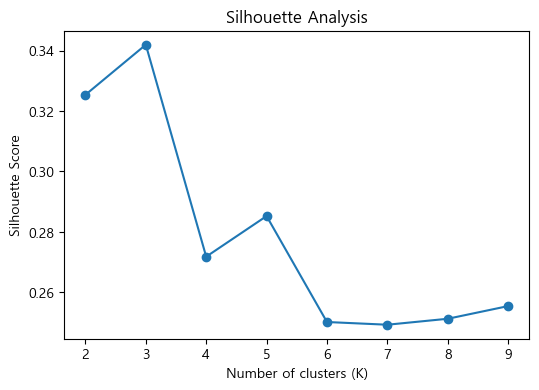

In [102]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K_range = [2, 3, 4, 5, 6, 7, 8, 9] 
silhouette_scores = [ ]

for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels) # 실루엣 계수 계산
    silhouette_scores.append(score) # 계산된 실루엣 계수 리스트에 추가

# 실루엣 그래프
plt.figure(figsize=(6, 4))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

=> `k = 3`으로 선정

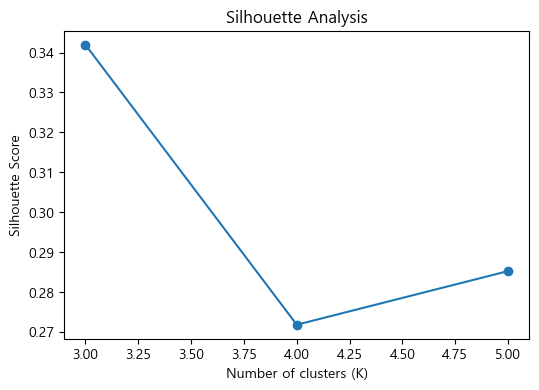

In [103]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K_range_1 = [3, 4, 5] 
silhouette_scores = [ ]

for k in K_range_1:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels) # 실루엣 계수 계산
    silhouette_scores.append(score) # 계산된 실루엣 계수 리스트에 추가

# 실루엣 그래프
plt.figure(figsize=(6, 4))
plt.plot(K_range_1, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

### 실루엣 계수 시각화 2

In [104]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

def plot_silhouette_panels(
    X,
    k_range=range(2, 6),
    random_state=42,
    n_init=10,
    scale=True,
    figsize_per_panel=(4.2, 4.2)
):
    """
    예시 이미지처럼 k별 실루엣 플롯을 패널로 시각화

    Parameters
    ----------
    X : array-like or pd.DataFrame
        피처 행렬 (예: ml_features_final)
    k_range : iterable
        비교할 k 범위 (예: range(2,6) -> 2,3,4,5)
    scale : bool
        True면 StandardScaler 적용
    """
    X_arr = X.values if hasattr(X, "values") else np.asarray(X)

    if scale:
        scaler = StandardScaler()
        X_use = scaler.fit_transform(X_arr)
    else:
        X_use = X_arr

    k_list = list(k_range)
    n_panels = len(k_list)

    fig_w = figsize_per_panel[0] * n_panels
    fig_h = figsize_per_panel[1]
    fig, axes = plt.subplots(1, n_panels, figsize=(fig_w, fig_h), sharex=True, sharey=False)

    if n_panels == 1:
        axes = [axes]

    for ax, k in zip(axes, k_list):
        km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        labels = km.fit_predict(X_use)

        sil_avg = silhouette_score(X_use, labels)
        sil_vals = silhouette_samples(X_use, labels)

        y_lower = 10
        for c in range(k):
            c_sil = sil_vals[labels == c]
            c_sil.sort()

            size_c = c_sil.shape[0]
            y_upper = y_lower + size_c

            ax.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                c_sil,
                alpha=0.85
            )

            ax.text(-0.05, y_lower + 0.5 * size_c, str(c))
            y_lower = y_upper + 10

        ax.axvline(sil_avg, linestyle="--")
        ax.set_title(f"Number of Cluster : {k}\nSilhouette Score : {sil_avg:.3f}")
        ax.set_xlabel("The silhouette coefficient values")

        ax.set_xlim(-0.1, 1.0)
        ax.set_yticks([])
        if ax is axes[0]:
            ax.set_ylabel("Cluster label")

    plt.tight_layout()
    plt.show()


# 사용 예시 1) 최종 피처 DF로 바로
# plot_silhouette_panels(ml_features_final, k_range=range(2, 6), scale=True)

# 사용 예시 2) 이미 스케일링된 X_scaled가 있으면 scale=False로
# plot_silhouette_panels(X_scaled, k_range=range(2, 6), scale=False)


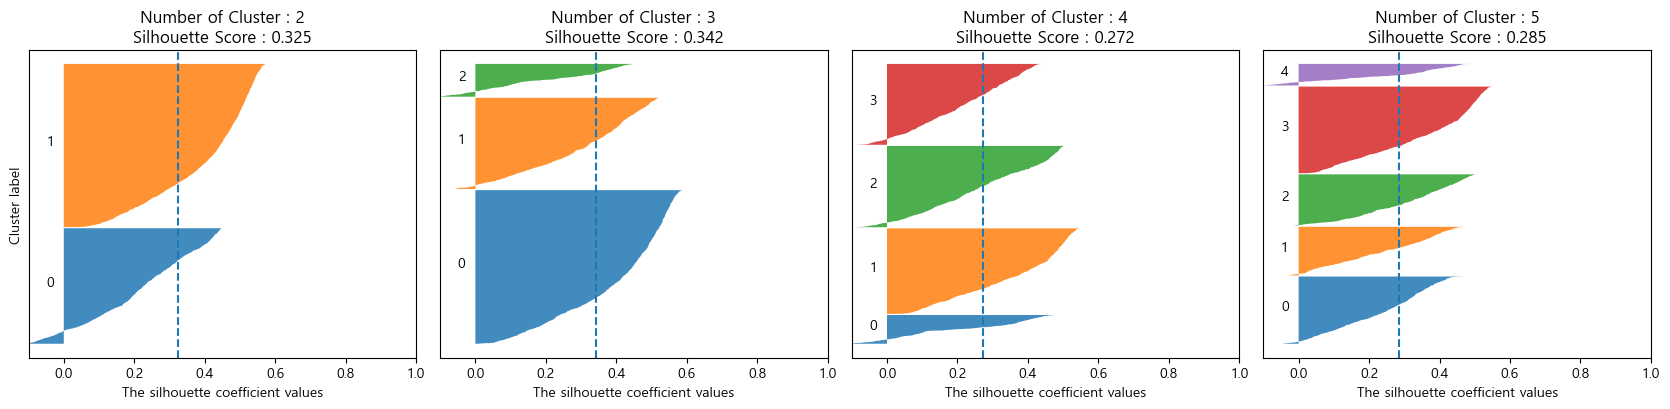

In [105]:
plot_silhouette_panels(ml_features_final_dropped, k_range=range(2, 6), scale=True)

## 3) 최종 K-Means 코드
- 위에서 최종 k를 결정해서 모델링 학습 진행

### 3-1) standard scaler

In [106]:
ml_features_final_F.isna().sum()

seller_total_revenue_log       0
n_unique_products_log          0
high_review_ratio              0
confirm_time_min_log           0
purchase_to_carrier_min_log    0
dtype: int64

In [107]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 원본 보존용
clustered_df = ml_features_final_F.copy()

# 파이프라인 (standardscaler, K-Means) : 한번에 진행
kmeans_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters=3, # 4는 임의의 숫자로 넣어놓음. 위 엘보우 그래프와 실루엣 계수로 결정한 최종 k를 넣으면 됩니다. 
        random_state=42,
        n_init=10,
        max_iter=300 # 최대 300번까지만 반복
    ))
])

# 모델 학습과 예측
clustered_df['cluster'] = kmeans_pipeline.fit_predict(clustered_df)

### 3-2) 차원 축소 해서 산점도로 확인

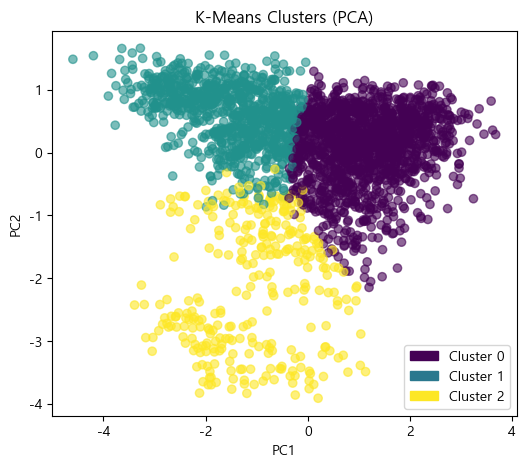

In [108]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA (2차원)
pca = PCA(n_components=2, random_state=42) # 2차원으로 축소
X_pca = pca.fit_transform(
    kmeans_pipeline.named_steps['scaler']
    .transform(clustered_df.drop(columns='cluster')) # cluster는 머신러닝의 결과물이므로 제외하고 차원축소 진행. 
                                                     # cluster는 차원축소에 넣으면 안 됨.
)

# 시각화
plt.figure(figsize=(6, 5))
plt.scatter(
    X_pca[:, 0], #PC1 좌표
    X_pca[:, 1], #PC2 좌표
    c=clustered_df['cluster'], # 색을 클러스터별로 구분 
    alpha=0.6
)

import matplotlib.patches as mpatches

legend_elements = [
    mpatches.Patch(color='#440154', label='Cluster 0'),  # 보라
    mpatches.Patch(color='#2a788e', label='Cluster 1'),  # 초록
    mpatches.Patch(color='#fde725', label='Cluster 2')   # 노랑
]

plt.legend(handles=legend_elements)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters (PCA)')
plt.show()

### 3-3) 클러스터 해석

In [109]:
clustered_df['cluster'].value_counts()

cluster
0    1460
1     867
2     312
Name: count, dtype: int64

In [110]:
cluster_profile = (
    clustered_df
    .groupby('cluster')
    .mean()
)

cluster_profile


,seller_total_revenue_log,n_unique_products_log,high_review_ratio,confirm_time_min_log,purchase_to_carrier_min_log
cluster,,,,,
0,7.566064,2.155497,0.799408,8.680082,10.626519
1,5.421326,1.010149,0.956667,4.574297,9.122430
2,5.513818,1.016879,0.252555,5.361984,9.785396


- cluster 0 (보라):\
 매출 규모 큼, 상품 다양성 높음, 리뷰 품질 좋음, 주문 확정까지 느림, 물류 인계까지 느림 -> 매출은 잘 나오지만 운영 속도 느림 => 고매출 · 운영 병목 셀러
- cluster 1 (초록):\
 매출 규모 중간, 상품 다양성 적음, 리뷰 품질 최고점, 주문 확정까지 가장 빠름, 물류 인계까지 빠른 편 -> 상품 수는 적지만 운영 효율 최고, 고객 경험 관리가 매우 잘 되는 셀러 => 운영 효율 우수 셀러
- cluster 2 (노랑):\
 매출 규모 중간, 상품 다양성 적음, 리뷰 품질 최저점, 주문 확정까지 보통, 물류 인계까지 보통 -> 매출은 잘 나오고 운영 속도 느림, 리뷰 품질이 압도적으로 나쁨 => 고객경험 취약 셀러

### 3-4) cluster 안에 어떤 seller가 있는지 파악

In [111]:
seller_level_df = (
    df_smb_f
    .drop_duplicates(subset='seller_id')
    .reset_index(drop=True)
)

In [112]:
print(f"seller_level_df 행 개수: {len(seller_level_df)}")
print(f"clustered_df 행 개수: {len(clustered_df)}")

seller_level_df 행 개수: 2639
clustered_df 행 개수: 2639


In [113]:
# 클러스터 기입
seller_level_df['cluster'] = clustered_df['cluster'].values
seller_level_df[['seller_id', 'cluster']].head()

,seller_id,cluster
0,3504c0cb71d7fa48d967e0e4c94d59d9,2
1,2c9e548be18521d1c43cde1c582c6de8,0
2,63b9ae557efed31d1f7687917d248a8d,1
3,094ced053e257ae8cae57205592d6712,0
4,0bae85eb84b9fb3bd773911e89288d54,1


In [114]:
cluster_sellers = (
    seller_level_df
    .groupby('cluster')['seller_id']
    .apply(list)
)

cluster_sellers

cluster
0    [2c9e548be18521d1c43cde1c582c6de8, 094ced053e2...
1    [63b9ae557efed31d1f7687917d248a8d, 0bae85eb84b...
2    [3504c0cb71d7fa48d967e0e4c94d59d9, 977f9f63dd3...
Name: seller_id, dtype: object

In [115]:
seller_level_df # 여기에 피처 컬럼 합쳐야함 cluster 기준으로

,order_id,product_id,seller_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,review_id,review_score,price,segment,seller_total_revenue,n_unique_products,avg_review_score,is_high_review,review_group,high_review_ratio,confirm_time_min,purchase_to_carrier_min,cluster
0,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2010-02-17 10:56:00,2010-02-17 11:07:00,2010-04-17 19:55:00,a54f0611adc9ed256b57ede6b6eb5114,4,29.99,SMB,2349.94,14,4.41,1,High,0.857143,11.0,85499.0,2
1,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2013-02-18 21:18:00,2013-02-18 22:20:00,2014-02-18 19:46:00,e50934924e227544ba8246aeb3770dd4,5,19.90,SMB,6109.44,15,4.01,1,High,0.750000,62.0,525508.0,0
2,76c6e866289321a7c93b82b54852dc33,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,2023-01-17 18:29:00,2025-01-17 02:50:00,2026-01-17 14:16:00,fc4af8aea8ec3f1a3cd181d3d0cadbd5,1,19.90,SMB,139.50,3,3.67,0,Low,0.666667,1051701.0,1577987.0,1
3,82566a660a982b15fb86e904c8d32918,72a97c271b2e429974398f46b93ae530,094ced053e257ae8cae57205592d6712,2006-07-18 10:06:00,2006-09-18 03:13:00,2006-11-18 13:29:00,ed220e853e96b629118a3576e02900b6,5,31.90,SMB,1519.20,13,4.05,1,High,0.736842,88867.0,177323.0,0
4,432aaf21d85167c2c86ec9448c4e42cc,72d3bf1d3a790f8874096fcf860e3eff,0bae85eb84b9fb3bd773911e89288d54,2003-01-18 14:14:00,2003-01-18 15:10:00,2003-02-18 21:09:00,8f39f09c22b1ceb6e3eb178d8e50bb8a,4,38.25,SMB,7482.21,42,4.19,1,High,0.773050,56.0,45055.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2634,fbff77db5421bb7e1da292db45d07e75,654ccc4e5459e7ba6b8d9fb04c45b9db,2d8cfba3fcd3170555941605edaa196a,2015-03-17 11:41:00,2015-03-17 11:41:00,2016-03-17 04:19:00,c13d0d31c88734e32cd3067bf14d34d7,5,45.00,SMB,45.00,1,5.00,1,High,1.000000,0.0,526598.0,0
2635,1ab38815794efa43d269d62b98dae815,31ec3a565e06de4bdf9d2a511b822b4d,babcc0ab201e4c60188427cae51a5b8b,2007-01-18 10:23:00,2007-05-18 16:17:00,2007-04-18 14:34:00,7f9849fcbfdf9fa3070c05b5501bf066,5,79.00,SMB,79.00,1,5.00,1,High,1.000000,173154.0,129851.0,0
2636,735dce2d574afe8eb87e80a3d6229c48,1d187e8e7a30417fda31e85679d96f0f,d263fa444c1504a75cbca5cc465f592a,2024-07-18 09:46:00,2024-07-18 11:24:00,2024-07-18 15:14:00,19f21ead7ffe5b1b5147a7877c22bae5,5,399.00,SMB,399.00,1,5.00,1,High,1.000000,98.0,328.0,0
2637,25d2bfa43663a23586afd12f15b542e7,6e1c2008dea1929b9b6c27fa01381e90,edf3fabebcc20f7463cc9c53da932ea8,2022-05-18 21:13:00,2022-05-18 21:35:00,2024-05-18 12:28:00,ec2817e750153dfdd61894780dfc5d9e,4,219.90,SMB,219.90,1,4.00,1,High,1.000000,22.0,1052115.0,0


# ✅ 대시보드 파일 1
`seller_cluster_df_clean.csv` 생성

In [116]:
# 이거 확인용 
seller_level_df["cluster"] = seller_level_df["cluster"].map({
    0: "고매출 · 운영 병목 셀러",
    1: "운영 효율 우수 셀러",
    2: "고객경험 취약 셀러"
})
print(seller_level_df["cluster"].value_counts())
display(seller_level_df)

# 남길 컬럼 목록
keep_cols = [
    'cluster',
    'seller_id',
    'review_group',
    'avg_review_score',
    'n_unique_products',
    'is_high_review',
    'high_review_ratio'
]

# 컬럼 정리
seller_cluster_df_clean = seller_level_df[keep_cols].copy()

# 확인
seller_cluster_df_clean.info()

# CSV로 저장
seller_cluster_df_clean.to_csv(
    'seller_cluster_df_clean.csv',
    index=False,
    encoding='utf-8-sig'
)
print(f"\n✅ seller_cluster_df_clean.csv 저장")

cluster
고매출 · 운영 병목 셀러    1460
운영 효율 우수 셀러        867
고객경험 취약 셀러         312
Name: count, dtype: int64


,order_id,product_id,seller_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,review_id,review_score,price,segment,seller_total_revenue,n_unique_products,avg_review_score,is_high_review,review_group,high_review_ratio,confirm_time_min,purchase_to_carrier_min,cluster
0,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2010-02-17 10:56:00,2010-02-17 11:07:00,2010-04-17 19:55:00,a54f0611adc9ed256b57ede6b6eb5114,4,29.99,SMB,2349.94,14,4.41,1,High,0.857143,11.0,85499.0,고객경험 취약 셀러
1,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2013-02-18 21:18:00,2013-02-18 22:20:00,2014-02-18 19:46:00,e50934924e227544ba8246aeb3770dd4,5,19.90,SMB,6109.44,15,4.01,1,High,0.750000,62.0,525508.0,고매출 · 운영 병목 셀러
2,76c6e866289321a7c93b82b54852dc33,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,2023-01-17 18:29:00,2025-01-17 02:50:00,2026-01-17 14:16:00,fc4af8aea8ec3f1a3cd181d3d0cadbd5,1,19.90,SMB,139.50,3,3.67,0,Low,0.666667,1051701.0,1577987.0,운영 효율 우수 셀러
3,82566a660a982b15fb86e904c8d32918,72a97c271b2e429974398f46b93ae530,094ced053e257ae8cae57205592d6712,2006-07-18 10:06:00,2006-09-18 03:13:00,2006-11-18 13:29:00,ed220e853e96b629118a3576e02900b6,5,31.90,SMB,1519.20,13,4.05,1,High,0.736842,88867.0,177323.0,고매출 · 운영 병목 셀러
4,432aaf21d85167c2c86ec9448c4e42cc,72d3bf1d3a790f8874096fcf860e3eff,0bae85eb84b9fb3bd773911e89288d54,2003-01-18 14:14:00,2003-01-18 15:10:00,2003-02-18 21:09:00,8f39f09c22b1ceb6e3eb178d8e50bb8a,4,38.25,SMB,7482.21,42,4.19,1,High,0.773050,56.0,45055.0,운영 효율 우수 셀러
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2634,fbff77db5421bb7e1da292db45d07e75,654ccc4e5459e7ba6b8d9fb04c45b9db,2d8cfba3fcd3170555941605edaa196a,2015-03-17 11:41:00,2015-03-17 11:41:00,2016-03-17 04:19:00,c13d0d31c88734e32cd3067bf14d34d7,5,45.00,SMB,45.00,1,5.00,1,High,1.000000,0.0,526598.0,고매출 · 운영 병목 셀러
2635,1ab38815794efa43d269d62b98dae815,31ec3a565e06de4bdf9d2a511b822b4d,babcc0ab201e4c60188427cae51a5b8b,2007-01-18 10:23:00,2007-05-18 16:17:00,2007-04-18 14:34:00,7f9849fcbfdf9fa3070c05b5501bf066,5,79.00,SMB,79.00,1,5.00,1,High,1.000000,173154.0,129851.0,고매출 · 운영 병목 셀러
2636,735dce2d574afe8eb87e80a3d6229c48,1d187e8e7a30417fda31e85679d96f0f,d263fa444c1504a75cbca5cc465f592a,2024-07-18 09:46:00,2024-07-18 11:24:00,2024-07-18 15:14:00,19f21ead7ffe5b1b5147a7877c22bae5,5,399.00,SMB,399.00,1,5.00,1,High,1.000000,98.0,328.0,고매출 · 운영 병목 셀러
2637,25d2bfa43663a23586afd12f15b542e7,6e1c2008dea1929b9b6c27fa01381e90,edf3fabebcc20f7463cc9c53da932ea8,2022-05-18 21:13:00,2022-05-18 21:35:00,2024-05-18 12:28:00,ec2817e750153dfdd61894780dfc5d9e,4,219.90,SMB,219.90,1,4.00,1,High,1.000000,22.0,1052115.0,고매출 · 운영 병목 셀러


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2639 entries, 0 to 2638
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cluster            2639 non-null   object 
 1   seller_id          2639 non-null   object 
 2   review_group       2639 non-null   object 
 3   avg_review_score   2639 non-null   float64
 4   n_unique_products  2639 non-null   int64  
 5   is_high_review     2639 non-null   int64  
 6   high_review_ratio  2639 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 144.4+ KB

✅ seller_cluster_df_clean.csv 저장


# ✅ 대시보드 파일 2
`ach_merged_df_segment_Final_v2.csv` 생성

In [117]:
df_dash = df.copy()
df_dash.shape

(112650, 38)

In [118]:
# 주문 승인 소요 시간 (confirm_time_min)
df_dash['confirm_time_min'] = (
    df_dash['order_approved_at'] - df_dash['order_purchase_timestamp']
).dt.total_seconds() / 60

# 택배사 인계 소요 시간 컬럼 (purchase_to_carrier_min)
df_dash['purchase_to_carrier_min'] = (
    df_dash['order_delivered_carrier_date'] - df_dash['order_purchase_timestamp']
).dt.total_seconds() / 60

# 수량 컬럼 (quantity)
df_dash['quantity'] = df_dash.groupby('product_id')['order_item_id'].transform('count')

# confirm_time_min, purchase_to_carrier_min 이상치 필터링 (df_dash_clean)
df_dash_clean = df_dash[
    (df_dash['confirm_time_min'] >= 0) & 
    (df_dash['purchase_to_carrier_min'] >= 0)
]

df_dash_clean_1 = df_dash_clean[
    (df_dash_clean["order_purchase_timestamp"] >= "2016-09-01") &
    (df_dash_clean["order_purchase_timestamp"] <= "2018-08-31")
]

In [119]:
# 최종 대시보드용 파일 저장
# df_dash_clean_1.to_csv("ach_merged_df_segment_Final_2.csv", index=False)
# print("\n✅ ach_merged_df_segment_Final_2.csv 저장 완료!")

# 4️⃣ Enterprise 분석

In [120]:
# 분석 파라미터 설정 (CONFIG)
"""
분석에 사용되는 모든 기준값을 한 곳에서 관리
재현성과 투명성을 위해 코드 최상단에 배치
"""
CONFIG = {
    # 기간 설정
    'RECENT_MONTHS': ['2018-06', '2018-07', '2018-08'],
    'PREVIOUS_MONTHS': ['2018-03', '2018-04', '2018-05'],
    
    # 성과 그룹 분류 기준
    # ±10%: 매출 성장률 분포의 약 30/70 분위수 기준
    # 비즈니스 관점에서 의미있는 변화 수준
    'GROWTH_THRESHOLD': 10,      # +10% 이상: 성장
    'DECLINE_THRESHOLD': -10,    # -10% 미만: 하락
    
    # 리뷰 신뢰도 필터
    # 5개 미만의 리뷰는 통계적 신뢰도가 낮아 제외
    # 'MIN_REVIEW_COUNT': 5,
    
    # 성장 타입 구분 기준 (성장 그룹 내부)
    # 주문증가형 vs 객단가증가형 구분
    # 성장 그룹 내 주문수 변화율 중앙값을 기준으로 설정
    # 중앙값 기준: 데이터 내부 구조를 반영하며, 극단값에 영향받지 않음
    'ORDER_GROWTH_THRESHOLD': None,  # 후반부에서 동적 계산
}

print("=== 분석 파라미터 설정 완료 ===")
for key, value in CONFIG.items():
    print(f"{key}: {value}")


=== 분석 파라미터 설정 완료 ===
RECENT_MONTHS: ['2018-06', '2018-07', '2018-08']
PREVIOUS_MONTHS: ['2018-03', '2018-04', '2018-05']
GROWTH_THRESHOLD: 10
DECLINE_THRESHOLD: -10
ORDER_GROWTH_THRESHOLD: None


In [121]:
df_ach = pd.read_csv('ach_merged_df_segment_Final_v2.csv')  # 태블로 파일

# 상품별 주문 수량 계산
df_ach['quantity'] = df_ach.groupby('product_id')['order_item_id'].transform('count')

# 상품별 매출
# total_revenue = 가격 × 수량
df_ach['total_revenue'] = df_ach['price'] * df_ach['quantity']


print("=== 데이터 로딩 완료 ===")
print(f"전체 데이터 shape: {df_ach.shape}")
df_ach.head()

=== 데이터 로딩 완료 ===
전체 데이터 shape: (90893, 42)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delayed,is_canceled,product_category_name,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_message,review_creation_date,geolocation_zip_code_prefix,lat_mode,lng_mode,geolocation_city,geolocation_state,seller_total_revenue,segment,quantity,confirm_time_min,purchase_to_carrier_min,total_revenue
0,dabf2b0e35b423f94618bf965fcb7514,1,473795a355d29305c3ea6b156833adf5,620c87c171fb2a6dd6e8bb4dec959fc6,2016-10-13 13:36:00,59.9,0.48,5cdec0bb8cbdf53ffc8fdc212cd247c6,canceled,2016-09-10 00:56:00,2016-09-10 13:36:00,2016-10-13 13:36:00,2016-10-16 14:36:00,2016-11-30,-45.0,0.0,1,perfumaria,perfumery,25645,petropolis,RJ,petropolis,2f96790fba243100730c8d1185dd2f25,5846,sao paulo,SP,28112c56c882286e0b235173e84c5370,5.0,Compraria novamente pq cumprem com o prazo de ...,NaN,25645.0,-22.550469,-43.221092,petrópolis,RJ,114774.50,Enterprise,79,760.0,48280.0,4732.1
1,dabf2b0e35b423f94618bf965fcb7514,2,7cd29da0653abeb444703cc5a957f479,620c87c171fb2a6dd6e8bb4dec959fc6,2016-10-13 13:36:00,49.9,29.94,5cdec0bb8cbdf53ffc8fdc212cd247c6,canceled,2016-09-10 00:56:00,2016-09-10 13:36:00,2016-10-13 13:36:00,2016-10-16 14:36:00,2016-11-30,-45.0,0.0,1,beleza_saude,health_beauty,25645,petropolis,RJ,petropolis,2f96790fba243100730c8d1185dd2f25,5846,sao paulo,SP,28112c56c882286e0b235173e84c5370,5.0,Compraria novamente pq cumprem com o prazo de ...,NaN,25645.0,-22.550469,-43.221092,petrópolis,RJ,114774.50,Enterprise,16,760.0,48280.0,798.4
2,90bd4466c2905d7b5b56370149e62bcc,1,269e87010f6d5e57015a90b00983e334,0db783cfcd3b73998abc6e10e59a102f,2016-10-14 00:22:00,35.0,16.05,f11278c6a8edfe30db8bb9506ecbdff2,delivered,2016-09-10 11:33:00,2016-10-10 00:22:00,2016-10-15 10:09:00,2016-10-21 21:17:00,2016-06-12,131.0,1.0,0,informatica_acessorios,computers_accessories,11010,santos,SP,santos,1881f0742867dc75d6e0bcc24f866710,98290,condor,RS,2961357aed5485e126a05fc91fa8e9f3,4.0,Recomendo este vendedor.,NaN,11010.0,-23.936657,-46.338208,santos,SP,9077.40,SMB,1,42529.0,50316.0,35.0
3,0a5d7e24850c68bf00d39bd62a9a45ee,1,a8fe47ad6f852f93cc92c7b408687de3,aaed1309374718fdd995ee4c58c9dfcd,2016-10-14 00:23:00,62.9,17.35,cb544b0c548dbf3e9e52914472d56415,delivered,2016-09-10 11:43:00,2016-10-10 00:23:00,2016-10-21 18:02:00,2016-10-28 06:07:00,2016-06-12,138.0,1.0,0,esporte_lazer,sports_leisure,89120,timbo,SC,timbo,f706755df4abce09ff6fcdfadbe76166,27940,macae,RJ,3590167a693b2f2312743bc9a03a8d28,5.0,Tudo certo. Recomendo.,NaN,89120.0,-26.866974,-49.306033,timbo,SC,9376.95,SMB,30,42520.0,59419.0,1887.0
4,2e8e21db96a8ab922e51cd297678c6b2,1,87ecdbf76c33c8f2dabc40eeb821dc6b,d4d99b60c4c94cd35acd502cec65dc8d,2016-10-14 01:16:00,72.9,14.39,6a58b195be76f8ad6544e032b6c7316b,delivered,2016-09-10 12:13:00,2016-10-10 01:16:00,2016-10-25 13:54:00,2016-10-28 14:11:00,2016-02-12,259.0,1.0,0,moveis_decoracao,furniture_decor,4904,sao paulo,SP,sao paulo,f7ace36f8a10c4b2ede9ea7708e01454,80820,curitiba,PR,429856d721b6d33c24c79f7c319c177d,3.0,O único problema foi que um dos potes veio com...,NaN,4904.0,-23.685467,-46.749486,são paulo,SP,72.90,SMB,1,42543.0,64901.0,72.9


In [122]:
# df_ach.drop(columns=['Unnamed: 0'], inplace=True)  # 필요시 실행
df_ach.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90893 entries, 0 to 90892
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       90893 non-null  object 
 1   order_item_id                  90893 non-null  int64  
 2   product_id                     90893 non-null  object 
 3   seller_id                      90893 non-null  object 
 4   shipping_limit_date            90893 non-null  object 
 5   price                          90893 non-null  float64
 6   freight_value                  90893 non-null  float64
 7   customer_id                    90893 non-null  object 
 8   order_status                   90893 non-null  object 
 9   order_purchase_timestamp       90893 non-null  object 
 10  order_approved_at              90893 non-null  object 
 11  order_delivered_carrier_date   90893 non-null  object 
 12  order_delivered_customer_date  89888 non-null 

## 1) Enterprise 데이터 분리

In [123]:
# Enterprise 세그먼트 추출
## Enterprise 내 성장/정체/하락 그룹 간 차이 분석
df_ach_ent = df_ach[df_ach['segment'] == 'Enterprise']

print("=== Enterprise 세그먼트 추출 ===")
print(f"Enterprise 셀러 데이터: {df_ach_ent.shape}")

=== Enterprise 세그먼트 추출 ===
Enterprise 셀러 데이터: (47583, 42)


In [124]:
# 주문 취소 현황 확인
print("\n=== 주문 취소 현황 ===")
print(df_ach_ent['is_canceled'].value_counts())
print(f"취소율: {df_ach_ent['is_canceled'].mean() * 100:.2f}%")


=== 주문 취소 현황 ===
is_canceled
0    47547
1       36
Name: count, dtype: int64
취소율: 0.08%


In [125]:
# 유효 데이터 필터링
# 취소 주문 제외 (성과 분석은 실제 거래 기준)
df_ent_valid = df_ach_ent[df_ach_ent['is_canceled'] == 0].copy()

# 주문 시점 datetime 변환
df_ent_valid['order_purchase_timestamp'] = pd.to_datetime(
    df_ent_valid['order_purchase_timestamp']
)

# 연-월 컬럼 생성
df_ent_valid['year_month'] = df_ent_valid['order_purchase_timestamp'].dt.strftime('%Y-%m')

print("\n=== 유효 데이터 필터링 완료 ===")
print(f"유효 데이터 shape: {df_ent_valid.shape}")


=== 유효 데이터 필터링 완료 ===
유효 데이터 shape: (47547, 43)


In [126]:
# 월별 주문 건수 확인
print("\n=== 월별 주문 건수 ===")
print(df_ent_valid['year_month'].value_counts().sort_index())


=== 월별 주문 건수 ===
year_month
2016-09      10
2016-10       6
2017-01    1189
2017-02    1107
2017-03    1723
2017-04    1535
2017-05    2089
2017-06    1935
2017-07    2269
2017-08    2190
2017-09    2063
2017-10    2088
2017-11    3431
2017-12    1889
2018-01    3703
2018-02    3248
2018-03    3404
2018-04    3151
2018-05    2816
2018-06    2708
2018-07    2888
2018-08    2105
Name: count, dtype: int64


## 2) 기간 구분 및 간단 탐색

In [127]:
# 기간별 매출 계산 (셀러×월 단위)
# 셀러×월별 상품매출 합계
df_group = (
    df_ent_valid
    .groupby(['seller_id', 'year_month'], as_index=False)['total_revenue']
    .sum()
)

# 기간 구분 (CONFIG 사용)
df_group['period'] = df_group['year_month'].apply(
    lambda x: 'recent' if x in CONFIG['RECENT_MONTHS'] 
    else ('previous' if x in CONFIG['PREVIOUS_MONTHS'] else 'other')
)

print("=== 기간별 매출 계산 완료 ===")
print(df_group['period'].value_counts())
df_group.head()

=== 기간별 매출 계산 완료 ===
period
other       2289
previous     568
recent       547
Name: count, dtype: int64


,seller_id,year_month,total_revenue,period
0,001cca7ae9ae17fb1caed9dfb1094831,2017-01,64548.00,other
1,001cca7ae9ae17fb1caed9dfb1094831,2017-02,74955.50,other
2,001cca7ae9ae17fb1caed9dfb1094831,2017-03,131494.50,other
3,001cca7ae9ae17fb1caed9dfb1094831,2017-04,75228.90,other
4,001cca7ae9ae17fb1caed9dfb1094831,2017-05,175679.72,other


In [128]:
# 최근/이전 3개월 매출 집계
# 최근 3개월 매출
df_recent = df_group[df_group['period'] == 'recent']
recent_sum = df_recent.groupby('seller_id', as_index=False)['total_revenue'].sum()

# 이전 3개월 매출
df_previous = df_group[df_group['period'] == 'previous']
previous_sum = df_previous.groupby('seller_id', as_index=False)['total_revenue'].sum()

# 병합
agg = recent_sum.merge(previous_sum, on='seller_id', how='outer')
agg = agg.rename(columns={
    'total_revenue_x': 'recent_revenue',
    'total_revenue_y': 'previous_revenue'
})

print("=== 매출 집계 완료 ===")
print(f"총 셀러 수: {len(agg)}")
agg.head()


=== 매출 집계 완료 ===
총 셀러 수: 207


,seller_id,recent_revenue,previous_revenue
0,001cca7ae9ae17fb1caed9dfb1094831,12173.00,28338.00
1,004c9cd9d87a3c30c522c48c4fc07416,1016.40,3671.84
2,00ee68308b45bc5e2660cd833c3f81cc,27475.00,42984.00
3,01fdefa7697d26ad920e9e0346d4bd1b,45659.48,10024.08
4,0241d4d5d36f10f80c644447315af0bd,269225.90,233930.30


In [129]:
# 셀러의 첫 주문 날짜 계산
# 각 셀러의 첫 주문 날짜 (신규/재활성화 구분용)
first_order_date = (
    df_ent_valid
    .groupby('seller_id')['order_purchase_timestamp']
    .min()
    .reset_index()
)
first_order_date.columns = ['seller_id', 'first_order_date']

# agg 테이블에 합치기
agg_with_first = agg.merge(first_order_date, on='seller_id', how='left')

# 첫 주문 월 확인
agg_with_first['first_order_month'] = agg_with_first['first_order_date'].dt.to_period('M')

print("=== 셀러들의 첫 주문 시기 ===")
print(agg_with_first['first_order_month'].value_counts().sort_index())


=== 셀러들의 첫 주문 시기 ===
first_order_month
2016-09      4
2016-10      4
2017-01    136
2017-02     17
2017-03      3
2017-04      3
2017-05      4
2017-06      1
2017-07      1
2017-09      1
2017-10      2
2017-11      2
2017-12      3
2018-01     24
2018-03      1
2018-07      1
Freq: M, Name: count, dtype: int64


In [130]:
# 신규 vs 재활성화 구분
# 진짜 신규 셀러 = 2018-06 이후 첫 주문
agg_with_first['is_real_new'] = (
    agg_with_first['first_order_date'] >= '2018-06-01'
)

# "이전 매출 없음" 그룹 분석
no_previous = agg_with_first[agg_with_first['previous_revenue'].isna()]

print("=== '이전 매출 없음' 그룹 분석 ===")
print(f"총 {len(no_previous)}명")
print(f"\n진짜 신규 (2018-06 이후 가입): {no_previous['is_real_new'].sum()}명")
print(f"기존 셀러인데 쉬었음 (재활성화): {(~no_previous['is_real_new']).sum()}명")

# 각각 샘플 확인
print("\n=== 진짜 신규 셀러 샘플 ===")
real_new = no_previous[no_previous['is_real_new']]
print(real_new[['seller_id', 'first_order_date', 'recent_revenue']].head())

print("\n=== 재활성화 셀러 샘플 ===")
just_resting = no_previous[~no_previous['is_real_new']]
print(just_resting[['seller_id', 'first_order_date', 'recent_revenue']].head())


=== '이전 매출 없음' 그룹 분석 ===
총 3명

진짜 신규 (2018-06 이후 가입): 1명
기존 셀러인데 쉬었음 (재활성화): 2명

=== 진짜 신규 셀러 샘플 ===
                            seller_id    first_order_date  recent_revenue
148  b37c4c02bda3161a7546a4e6d222d5b2 2018-07-15 14:49:00         28640.0

=== 재활성화 셀러 샘플 ===
                            seller_id    first_order_date  recent_revenue
77   6061155addc1e54b4cfb51c1c2a32ad8 2018-01-06 01:20:00        19146.80
175  d50d79cb34e38265a8649c383dcffd48 2017-01-12 11:23:00          969.99


## 4) 성장률 분포 시각화

In [131]:
# 성장률 계산
# 매출 성장률 = (최근 - 이전) / 이전 × 100
agg['growth_rate'] = np.where(
    agg['previous_revenue'].isna() | (agg['previous_revenue'] == 0),
    np.nan,  # 이전 매출 없으면 성장률 계산 불가
    (agg['recent_revenue'] - agg['previous_revenue']) / agg['previous_revenue'] * 100
)

print("=== 성장률 계산 완료 ===")
print(agg['growth_rate'].describe())

=== 성장률 계산 완료 ===
count      195.000000
mean       140.598964
std       1493.230362
min        -98.036944
25%        -56.722954
50%        -27.444444
75%         16.624706
max      20355.694618
Name: growth_rate, dtype: float64


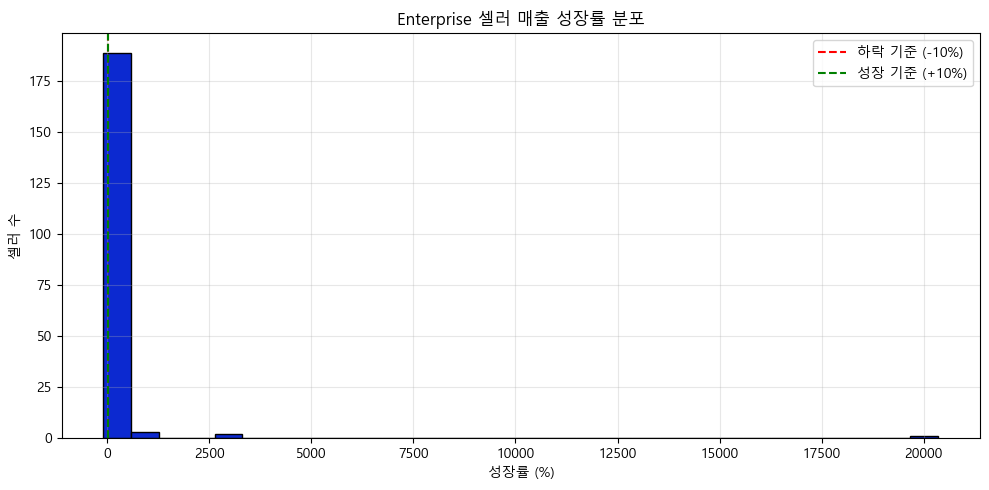

In [132]:
# 성장률 분포 시각화
# Enterprise 셀러 매출 성장률 분포

plt.figure(figsize=(10, 5))
plt.hist(agg['growth_rate'].dropna(), bins=30, edgecolor='black', color="#0c29d0")
plt.axvline(
    -CONFIG['DECLINE_THRESHOLD'], 
    color='red', 
    linestyle='--', 
    label=f'하락 기준 ({CONFIG["DECLINE_THRESHOLD"]}%)'
)
plt.axvline(
    CONFIG['GROWTH_THRESHOLD'], 
    color='green', 
    linestyle='--', 
    label=f'성장 기준 (+{CONFIG["GROWTH_THRESHOLD"]}%)'
)
plt.xlabel('성장률 (%)')
plt.ylabel('셀러 수')
plt.title('Enterprise 셀러 매출 성장률 분포')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

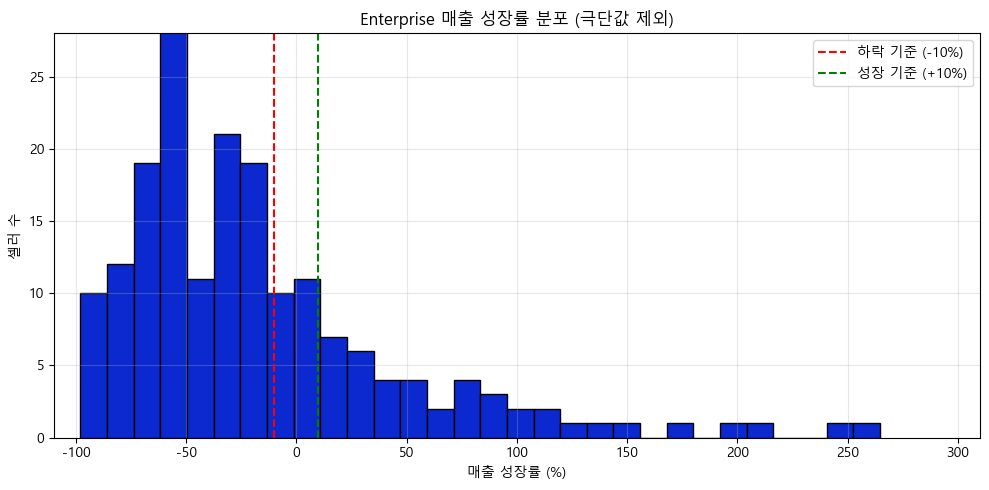

In [133]:
# ============================
# 추가
# ============================

plot_df = agg['growth_rate'].dropna()
plot_df = plot_df[(plot_df >= -100) & (plot_df <= 300)]

plt.figure(figsize=(10, 5))

plt.hist(
    plot_df,
    bins=30,
    edgecolor='black',
    color="#0c29d0"
)

# 기준선: -10%, +10%
plt.axvline(
    CONFIG['DECLINE_THRESHOLD'],   # -10
    color='red',
    linestyle='--',
    label='하락 기준 (-10%)'
)
plt.axvline(
    CONFIG['GROWTH_THRESHOLD'],    # +10
    color='green',
    linestyle='--',
    label='성장 기준 (+10%)'
)

plt.xlim(-110, 310)
plt.xticks([-100, -50, 0, 50, 100, 150, 200, 250, 300])

plt.ylim(0, 28)
plt.yticks([0, 5, 10, 15, 20, 25])

plt.xlabel('매출 성장률 (%)')
plt.ylabel('셀러 수')
plt.title('Enterprise 매출 성장률 분포 (극단값 제외)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




## 5) 관련 지표 계산

In [134]:
# 주문수 관련 지표 계산
# 1. 최근 3개월 주문수
recent_orders = (
    df_ent_valid[df_ent_valid['year_month'].isin(CONFIG['RECENT_MONTHS'])]
    .groupby('seller_id')['order_id']
    .nunique()
    .reset_index()
)
recent_orders.columns = ['seller_id', 'recent_orders']

# 2. 이전 3개월 주문수
previous_orders = (
    df_ent_valid[df_ent_valid['year_month'].isin(CONFIG['PREVIOUS_MONTHS'])]
    .groupby('seller_id')['order_id']
    .nunique()
    .reset_index()
)
previous_orders.columns = ['seller_id', 'previous_orders']

# 3. 병합
orders_metrics = recent_orders.merge(
    previous_orders, 
    on='seller_id', 
    how='outer'
).fillna(0)

# 4. 주문수 변화율 계산
orders_metrics['order_change_rate'] = np.where(
    orders_metrics['previous_orders'] == 0,
    np.nan,  # 이전 주문 없으면 계산 불가
    ((orders_metrics['recent_orders'] - orders_metrics['previous_orders']) / 
     orders_metrics['previous_orders'] * 100)
)

print("=== 주문수 변화율 계산 완료 ===")
print(f"총 {len(orders_metrics)}명")
print(f"변화율 계산 가능: {orders_metrics['order_change_rate'].notna().sum()}명")


=== 주문수 변화율 계산 완료 ===
총 207명
변화율 계산 가능: 204명


In [135]:
# 리뷰 관련 지표 계산
# 1. 최근 3개월 리뷰
recent_reviews = (
    df_ent_valid[df_ent_valid['year_month'].isin(CONFIG['RECENT_MONTHS'])]
    .groupby('seller_id')['review_score']
    .agg(['mean', 'count'])
    .reset_index()
)
recent_reviews.columns = ['seller_id', 'recent_review_score', 'recent_review_count']

# 2. 이전 3개월 리뷰
previous_reviews = (
    df_ent_valid[df_ent_valid['year_month'].isin(CONFIG['PREVIOUS_MONTHS'])]
    .groupby('seller_id')['review_score']
    .agg(['mean', 'count'])
    .reset_index()
)
previous_reviews.columns = ['seller_id', 'previous_review_score', 'previous_review_count']

# 3. 병합
review_metrics = recent_reviews.merge(previous_reviews, on='seller_id', how='outer')

# 4. 리뷰 점수 변화 계산
review_metrics['review_score_change'] = (
    review_metrics['recent_review_score'] - review_metrics['previous_review_score']
)

print("\n=== 리뷰 점수 변화 계산 완료 ===")
print(f"총 {len(review_metrics)}명")
print(f"변화 계산 가능: {review_metrics['review_score_change'].notna().sum()}명")



=== 리뷰 점수 변화 계산 완료 ===
총 207명
변화 계산 가능: 195명


## 6) 성과 그룹 분류

In [136]:
# 성과 그룹 분류 함수 정의 (4그룹 체계)
def classify_seller_4groups(row, order_growth_threshold):
    """
    시계열 맥락을 고려한 4그룹 셀러 분류
    
    Parameters:
    -----------
    row : Series
        셀러별 집계 데이터 행
    order_growth_threshold : float
        주문증가형 vs 객단가증가형 구분 기준 (주문수 변화율 중앙값)
    
    Returns:
    --------
    str : 분류 그룹명
    
    분류 로직:
    - 신규: 최근 3개월에 처음 등장 (2018-06 이후 가입)
    - 재활성화: 과거 활동 이력 있으나 이전 3개월 휴면 후 최근 재등장
    - 이탈: 이전 3개월에는 있었으나 최근 3개월 매출 없음
    - 주문증가형: 매출 성장률 > +10% AND 주문수 변화율 >= 중앙값
                  (주문 수 증가가 매출 성장의 주 원인)
    - 객단가증가형: 매출 성장률 > +10% AND 주문수 변화율 < 중앙값
                    (객단가 상승, 제품 믹스 변화 등이 매출 성장의 주 원인)
    - 정체: 매출 성장률 -10% ~ +10%
    - 하락: 매출 성장률 < -10%
    """
    
    # 케이스 1: 데이터 없음
    if pd.isna(row['recent_revenue']) and pd.isna(row['previous_revenue']):
        return '데이터_없음'
    
    # 케이스 2: 이탈 (과거에만 매출 있음)
    if pd.isna(row['recent_revenue']) and pd.notna(row['previous_revenue']):
        return '이탈'
    
    # 케이스 3: 이전 매출 없음 → 신규 vs 재활성화 구분
    if pd.isna(row['previous_revenue']) and pd.notna(row['recent_revenue']):
        # 2018-06 이후 첫 주문 = 진짜 신규
        if row['first_order_date'] >= pd.Timestamp('2018-06-01'):
            return '신규'
        else:
            # 과거 활동 이력 있으나 휴면 후 복귀
            return '재활성화'
    
    # 케이스 4: 정상 운영 (최근/이전 모두 매출 있음)
    if pd.notna(row['previous_revenue']) and pd.notna(row['recent_revenue']):
        # 성장 그룹 → 주문수 변화율로 추가 구분
        if row['growth_rate'] > CONFIG['GROWTH_THRESHOLD']:
            # 주문수 변화율이 중앙값 이상이면 주문증가형
            if pd.notna(row['order_change_rate']) and row['order_change_rate'] >= order_growth_threshold:
                return '주문증가형'
            else:
                return '객단가증가형'
        elif row['growth_rate'] < CONFIG['DECLINE_THRESHOLD']:
            return '하락'
        else:
            return '정체'
    
    return '분류_불가'


In [137]:
# 최종 분석 테이블 생성
# 주문 지표 병합
agg_final = agg.merge(
    orders_metrics[['seller_id', 'recent_orders', 'previous_orders', 'order_change_rate']], 
    on='seller_id', 
    how='left'
)

# 리뷰 지표 병합
agg_final = agg_final.merge(
    review_metrics[[
        'seller_id', 
        'review_score_change', 
        'recent_review_count', 
        'previous_review_count'
    ]], 
    on='seller_id', 
    how='left'
)

# 첫 주문 날짜 병합
agg_final = agg_final.merge(first_order_date, on='seller_id', how='left')

print("\n=== 최종 분석 테이블 생성 완료 ===")
print(f"Shape: {agg_final.shape}")
print("\n컬럼 목록:")
print(agg_final.columns.tolist())

# 결측치 확인
print("\n종속변수 결측치:")
print(agg_final[[
    'order_change_rate', 
    'recent_orders', 
    'review_score_change'
]].isnull().sum())

agg_final.head()




=== 최종 분석 테이블 생성 완료 ===
Shape: (207, 11)

컬럼 목록:
['seller_id', 'recent_revenue', 'previous_revenue', 'growth_rate', 'recent_orders', 'previous_orders', 'order_change_rate', 'review_score_change', 'recent_review_count', 'previous_review_count', 'first_order_date']

종속변수 결측치:
order_change_rate       3
recent_orders           0
review_score_change    12
dtype: int64


,seller_id,recent_revenue,previous_revenue,growth_rate,recent_orders,previous_orders,order_change_rate,review_score_change,recent_review_count,previous_review_count,first_order_date
0,001cca7ae9ae17fb1caed9dfb1094831,12173.00,28338.00,-57.043546,2.0,8.0,-75.000000,0.250000,2.0,8.0,2017-01-06 13:40:00
1,004c9cd9d87a3c30c522c48c4fc07416,1016.40,3671.84,-72.319055,3.0,10.0,-70.000000,0.833333,3.0,10.0,2017-01-03 17:58:00
2,00ee68308b45bc5e2660cd833c3f81cc,27475.00,42984.00,-36.080867,16.0,24.0,-33.333333,-0.289474,19.0,26.0,2017-02-10 17:49:00
3,01fdefa7697d26ad920e9e0346d4bd1b,45659.48,10024.08,355.497961,25.0,7.0,257.142857,-0.053571,24.0,7.0,2017-01-08 23:30:00
4,0241d4d5d36f10f80c644447315af0bd,269225.90,233930.30,15.088084,76.0,53.0,43.396226,-0.180912,78.0,54.0,2017-02-12 14:05:00


In [138]:
# 빠른성장 기준값 동적 계산 및 4그룹 분류 적용
# 성장 그룹(growth_rate > 10%)의 주문수 변화율 중앙값 계산
"""
성장 타입 구분 기준 설정 근거:
- 성장 그룹(growth_rate > 10%) 내 주문수 변화율의 중앙값을 기준으로 설정
- 중앙값 사용 이유:
  1) 극단값(outlier)의 영향을 최소화
  2) 성장 그룹을 균등하게 2개 타입으로 구분 (50:50 분할)
  3) 데이터의 내재적 구조를 반영한 객관적 기준
- 중앙값 이상: 주문 수 증가가 뚜렷 → 주문증가형
- 중앙값 미만: 주문 증가 제한적, 객단가·제품믹스 변화 추정 → 객단가증가형
"""

# 성장 그룹(growth_rate > 10%)의 주문수 변화율 중앙값 계산
growth_temp = agg_final[
    (agg_final['growth_rate'] > CONFIG['GROWTH_THRESHOLD']) &
    (agg_final['order_change_rate'].notna())
]

if len(growth_temp) > 0:
    order_growth_threshold = growth_temp['order_change_rate'].median()
    CONFIG['ORDER_GROWTH_THRESHOLD'] = order_growth_threshold
    
    print("="*70)
    print("성장 타입 구분 기준값 설정")
    print("="*70)
    print(f"주문수 변화율 중앙값 (성장 그룹 내): {order_growth_threshold:.2f}%")
    print(f"\n근거:")
    print(f"  - 성장 그룹 셀러 수: {len(growth_temp)}명")
    print(f"  - 주문수 변화율 분포:")
    print(f"    · 25% 분위수: {growth_temp['order_change_rate'].quantile(0.25):.2f}%")
    print(f"    · 50% 분위수(중앙값): {order_growth_threshold:.2f}%")
    print(f"    · 75% 분위수: {growth_temp['order_change_rate'].quantile(0.75):.2f}%")
    print(f"\n해석:")
    print(f"  - 중앙값 이상: 주문 수 증가 중심 성장 → 주문증가형")
    print(f"  - 중앙값 미만: 객단가·제품믹스 변화 중심 성장 → 객단가증가형")
    print("="*70)
else:
    # 데이터가 없는 경우 기본값 사용
    CONFIG['ORDER_GROWTH_THRESHOLD'] = 20.0
    order_growth_threshold = 20.0
    print("경고: 성장 그룹 데이터 부족, 기본값 20% 사용")

# 4그룹 분류 적용
agg_final['growth_group'] = agg_final.apply(
    lambda row: classify_seller_4groups(row, order_growth_threshold), 
    axis=1
)

print("\n=== 4그룹 분류 완료 ===")
print(agg_final['growth_group'].value_counts())

성장 타입 구분 기준값 설정
주문수 변화율 중앙값 (성장 그룹 내): 45.26%

근거:
  - 성장 그룹 셀러 수: 52명
  - 주문수 변화율 분포:
    · 25% 분위수: 4.52%
    · 50% 분위수(중앙값): 45.26%
    · 75% 분위수: 129.17%

해석:
  - 중앙값 이상: 주문 수 증가 중심 성장 → 주문증가형
  - 중앙값 미만: 객단가·제품믹스 변화 중심 성장 → 객단가증가형

=== 4그룹 분류 완료 ===
growth_group
하락        126
주문증가형      26
객단가증가형     26
정체         17
이탈          9
재활성화        2
신규          1
Name: count, dtype: int64


### 6-1) Kruskal_Wallis 검정 (4그룹)

In [139]:
# Kruskal-Wallis 검정 준비 (4그룹)
from scipy import stats
from scipy.stats import kruskal

# 분석 대상: 주문증가형/객단가증가형/정체/하락
analysis_groups = ['주문증가형', '객단가증가형', '정체', '하락']
df_kw = agg_final[agg_final['growth_group'].isin(analysis_groups)].copy()

print("=== 분석 대상 (필터링 전) ===")
print(f"총 {len(df_kw)}명")
print(df_kw['growth_group'].value_counts())

# 결측치 제거
df_kw_clean = df_kw.dropna(subset=['order_change_rate', 'review_score_change'])

print("\n=== 분석 대상 (결측치 제거 후) ===")
print(f"총 {len(df_kw_clean)}명")
print(df_kw_clean['growth_group'].value_counts())

=== 분석 대상 (필터링 전) ===
총 195명
growth_group
하락        126
주문증가형      26
객단가증가형     26
정체         17
Name: count, dtype: int64

=== 분석 대상 (결측치 제거 후) ===
총 195명
growth_group
하락        126
주문증가형      26
객단가증가형     26
정체         17
Name: count, dtype: int64


In [140]:
# Kruskal-Wallis 검정 실행 (4그룹)
print("\n" + "="*70)
print("Kruskal-Wallis 검정 결과 (4그룹 비교)")
print("H₀ (귀무가설): 그룹 간 차이 없음")
print("="*70)

results = []

# 검정할 종속변수 정의
test_variables = [
    ('주문수 변화율 (%)', 'order_change_rate'),
    # ('최근 3개월 주문수 (건)', 'recent_orders'),
    ('리뷰 점수 변화 (점)', 'review_score_change')
]

for var_name, col_name in test_variables:
    # 각 그룹의 데이터 추출
    groups_data = [
        df_kw_clean[df_kw_clean['growth_group'] == g][col_name].dropna()
        for g in analysis_groups
    ]
    
    # Kruskal-Wallis 검정
    H, p = kruskal(*groups_data)
    
    # 결과 저장
    results.append({
        '종속변수': var_name,
        'N': len(df_kw_clean),
        'H 통계량': f'{H:.2f}',
        'p-value': f'{p:.4f}',
        '유의미 (p<0.05)': 'Yes ✅' if p < 0.05 else 'No ❌'
    })
    
    # 상세 출력
    print(f"\n【{var_name}】")
    print(f"  H 통계량: {H:.4f}")
    print(f"  p-value: {p:.4f}")
    
    if p < 0.05:
        print(f"  ✅ 결론: 그룹 간 유의미한 차이 있음 (귀무가설 기각)")
    else:
        print(f"  ❌ 결론: 그룹 간 유의미한 차이 없음 (귀무가설 채택)")
    
    # 그룹별 중앙값/평균
    print(f"\n  그룹별 통계량:")
    for g in analysis_groups:
        group_data = df_kw_clean[df_kw_clean['growth_group'] == g][col_name]
        median_val = group_data.median()
        mean_val = group_data.mean()
        count = len(group_data)
        print(f"    {g:8s} (n={count:2d}): "
              f"중앙값={median_val:7.2f}, 평균={mean_val:7.2f}")

# 결과 테이블 출력
print("\n" + "="*70)
print("검정 결과 요약")
print("="*70)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


Kruskal-Wallis 검정 결과 (4그룹 비교)
H₀ (귀무가설): 그룹 간 차이 없음

【주문수 변화율 (%)】
  H 통계량: 102.3098
  p-value: 0.0000
  ✅ 결론: 그룹 간 유의미한 차이 있음 (귀무가설 기각)

  그룹별 통계량:
    주문증가형    (n=26): 중앙값= 130.56, 평균= 254.27
    객단가증가형   (n=26): 중앙값=   3.01, 평균=   7.33
    정체       (n=17): 중앙값=  -5.77, 평균=   5.91
    하락       (n=126): 중앙값= -43.22, 평균= -37.12

【리뷰 점수 변화 (점)】
  H 통계량: 7.4637
  p-value: 0.0585
  ❌ 결론: 그룹 간 유의미한 차이 없음 (귀무가설 채택)

  그룹별 통계량:
    주문증가형    (n=26): 중앙값=  -0.10, 평균=  -0.07
    객단가증가형   (n=26): 중앙값=  -0.11, 평균=  -0.16
    정체       (n=17): 중앙값=   0.00, 평균=  -0.01
    하락       (n=126): 중앙값=   0.15, 평균=   0.13

검정 결과 요약
        종속변수   N  H 통계량 p-value 유의미 (p<0.05)
 주문수 변화율 (%) 195 102.31  0.0000        Yes ✅
리뷰 점수 변화 (점) 195   7.46  0.0585         No ❌


### 6-2) 박스플롯 시각화

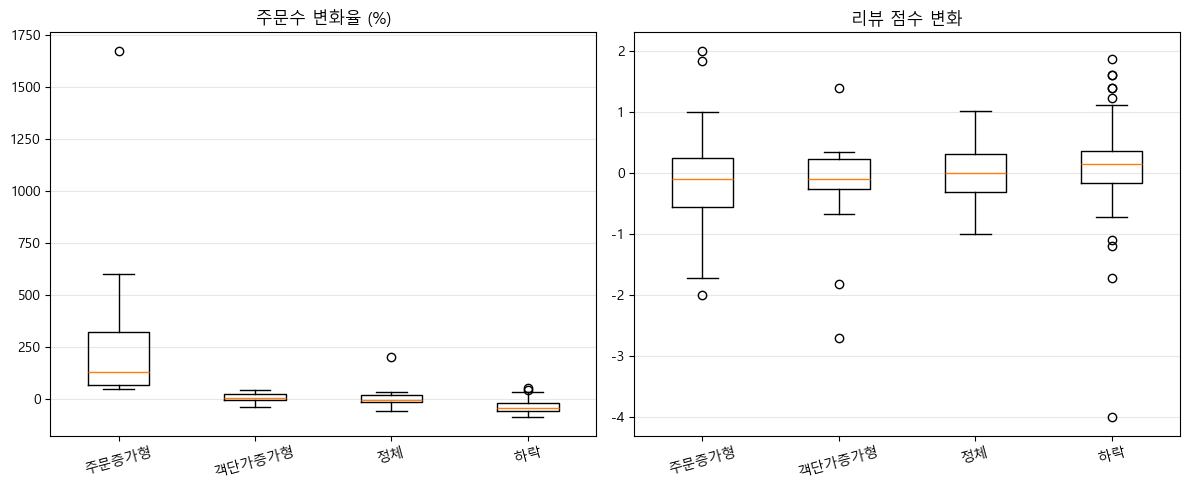

In [141]:
# 박스플롯 시각화 (4그룹)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_vars = [
    ('order_change_rate', '주문수 변화율 (%)'),
    ('review_score_change', '리뷰 점수 변화')
]

for idx, (col, title) in enumerate(plot_vars):
    ax = axes[idx]
    
    df_plot = agg_final.dropna(subset=[col])
    
    data_to_plot = [
        df_plot[df_plot['growth_group'] == g][col]
        for g in analysis_groups
    ]
    
    ax.boxplot(data_to_plot, tick_labels=analysis_groups)
    ax.set_title(title)          # ← 여기
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### 6-3) Dunns's Post-hoc 사후 검정

In [142]:
# Dunn's Post-hoc Test (사후 검정)
import scikit_posthocs as sp

# 분석 대상 그룹
target_groups = ['주문증가형', '객단가증가형', '정체', '하락']

# Dunn test에 사용할 컬럼 (최근 3개월 주문수)
value_col = 'recent_orders'

# 분석용 데이터 준비
tmp = agg_final[['growth_group', value_col]].dropna().copy()
tmp['growth_group'] = tmp['growth_group'].astype(str)

# Dunn test 실행 (Bonferroni 보정)
dunn_results = sp.posthoc_dunn(
    tmp,
    val_col=value_col,
    group_col='growth_group',
    p_adjust='bonferroni'
)

# 그룹 순서 정렬
existing_groups = [g for g in target_groups if g in dunn_results.index]
dunn_results = dunn_results.loc[existing_groups, existing_groups]

print("\n=== Dunn's Post-hoc Test 결과 ===")
print("P-value matrix (0.05 미만이면 유의미한 차이)")
print("="*50)
print(dunn_results.to_string())
print("\n해석: 주문증가형↔하락 간 가장 큰 차이, 객단가증가형과 정체는 중간 영역")



=== Dunn's Post-hoc Test 결과 ===
P-value matrix (0.05 미만이면 유의미한 차이)
        주문증가형  객단가증가형   정체   하락
주문증가형     1.0     1.0  1.0  1.0
객단가증가형    1.0     1.0  1.0  1.0
정체        1.0     1.0  1.0  1.0
하락        1.0     1.0  1.0  1.0

해석: 주문증가형↔하락 간 가장 큰 차이, 객단가증가형과 정체는 중간 영역


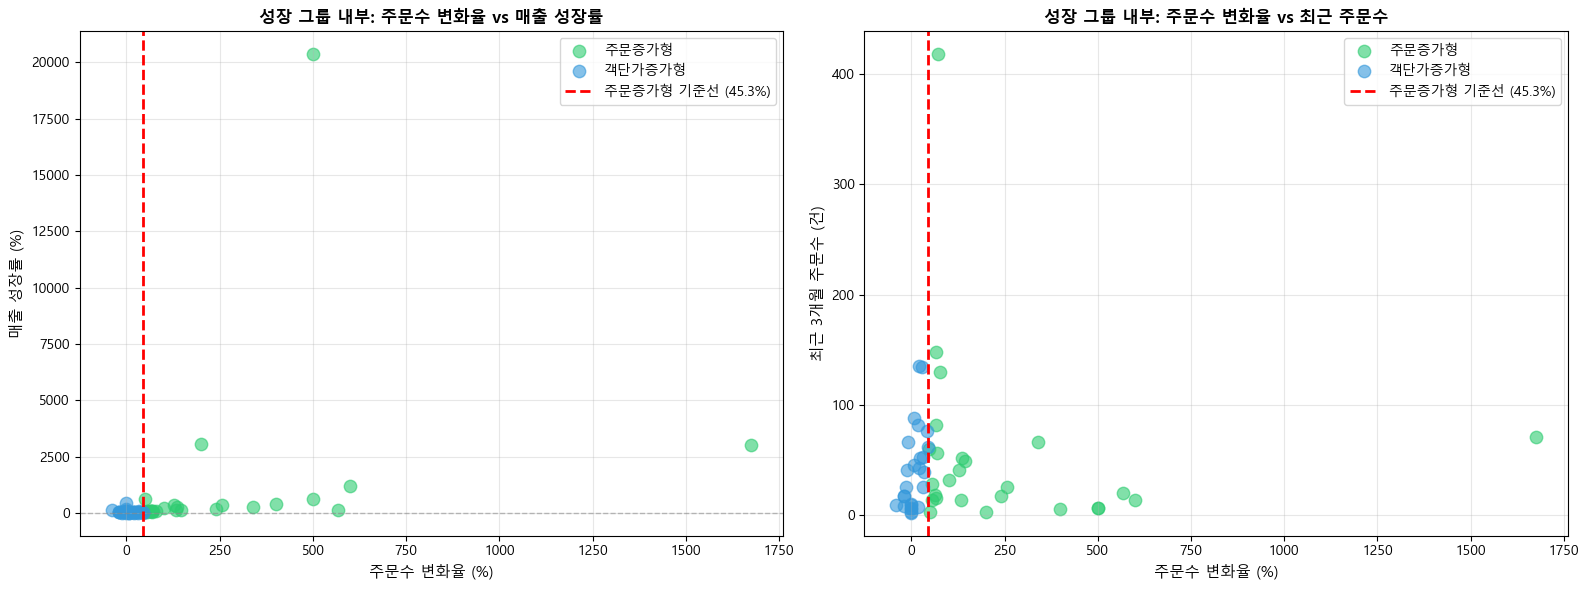


=== 성장 그룹 내부 통계 요약 ===
             seller_id growth_rate         order_change_rate          \
                 count        mean  median              mean  median   
growth_group                                                           
객단가증가형              26       63.86   38.78              7.33    3.01   
주문증가형               26     1234.99  167.52            254.27  130.56   

             recent_orders         
                      mean median  
growth_group                       
객단가증가형               40.73   32.0  
주문증가형                53.58   26.5  

해석:
- 주문증가형: 주문 수 증가가 매출 성장의 주요 동인
- 객단가증가형: 객단가 상승, 제품 믹스 변화 등이 매출 성장의 주요 동인
  (주문 수 증가는 제한적이나 매출은 유의미하게 성장)


In [143]:
# 성장 그룹 내부 Scatter Plot

# 성장 그룹(주문증가형 + 객단가증가형) 데이터만 추출
df_growth_groups = agg_final[
    agg_final['growth_group'].isin(['주문증가형', '객단가증가형'])
].copy()

# 결측치 제거
df_scatter = df_growth_groups.dropna(
    subset=['order_change_rate', 'growth_rate', 'recent_orders']
)

if len(df_scatter) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 그래프 1: 주문수 변화율 vs 매출 성장률
    ax1 = axes[0]
    colors_growth = {'주문증가형': '#2ecc71', '객단가증가형': '#3498db'}
    
    for g in ['주문증가형', '객단가증가형']:
        tmp = df_scatter[df_scatter['growth_group'] == g]
        ax1.scatter(
            tmp['order_change_rate'],
            tmp['growth_rate'],
            label=g,
            color=colors_growth[g],
            alpha=0.6,
            s=80
        )
    
    # 기준선 표시
    ax1.axhline(CONFIG['GROWTH_THRESHOLD'], linestyle='--', color='gray', lw=1, alpha=0.5)
    ax1.axvline(order_growth_threshold, linestyle='--', color='red', lw=2, 
                label=f'주문증가형 기준선 ({order_growth_threshold:.1f}%)')
    
    ax1.set_xlabel('주문수 변화율 (%)', fontsize=11)
    ax1.set_ylabel('매출 성장률 (%)', fontsize=11)
    ax1.set_title('성장 그룹 내부: 주문수 변화율 vs 매출 성장률', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 그래프 2: 주문수 변화율 vs 최근 주문수
    ax2 = axes[1]
    
    for g in ['주문증가형', '객단가증가형']:
        tmp = df_scatter[df_scatter['growth_group'] == g]
        ax2.scatter(
            tmp['order_change_rate'],
            tmp['recent_orders'],
            label=g,
            color=colors_growth[g],
            alpha=0.6,
            s=80
        )
    
    # 기준선
    ax2.axvline(order_growth_threshold, linestyle='--', color='red', lw=2,
                label=f'주문증가형 기준선 ({order_growth_threshold:.1f}%)')
    
    ax2.set_xlabel('주문수 변화율 (%)', fontsize=11)
    ax2.set_ylabel('최근 3개월 주문수 (건)', fontsize=11)
    ax2.set_title('성장 그룹 내부: 주문수 변화율 vs 최근 주문수', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 그룹별 통계 요약
    print("\n=== 성장 그룹 내부 통계 요약 ===")
    growth_summary = df_scatter.groupby('growth_group').agg({
        'seller_id': 'count',
        'growth_rate': ['mean', 'median'],
        'order_change_rate': ['mean', 'median'],
        'recent_orders': ['mean', 'median']
    }).round(2)
    print(growth_summary)
    
    print("\n해석:")
    print("- 주문증가형: 주문 수 증가가 매출 성장의 주요 동인")
    print("- 객단가증가형: 객단가 상승, 제품 믹스 변화 등이 매출 성장의 주요 동인")
    print("  (주문 수 증가는 제한적이나 매출은 유의미하게 성장)")
else:
    print("성장 그룹 데이터가 부족하여 scatter plot을 생성할 수 없습니다.")


## 7) Enterprise 셀러 성과 포트폴리오 (4그룹) 매트릭스 시각화
마이너스 값 깨지는 건 추후 ppt로 수정

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


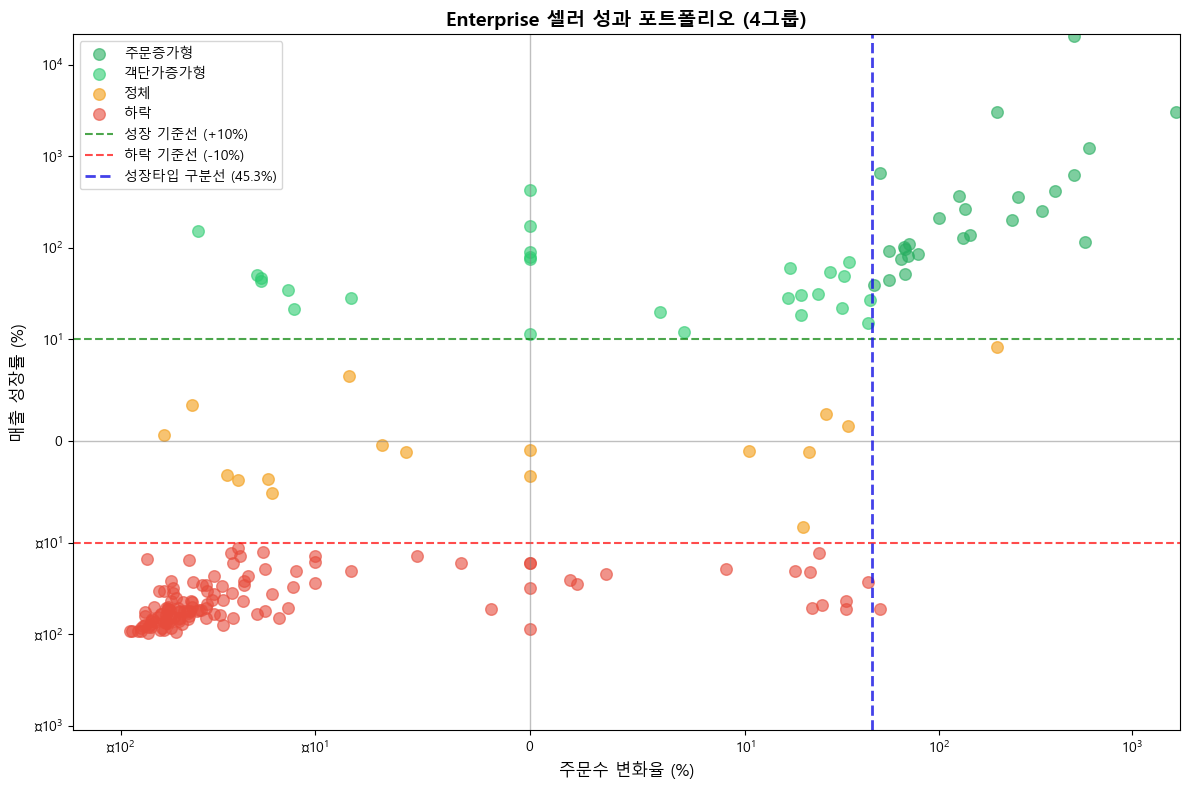

In [144]:
df_portfolio = agg_final[
    agg_final['growth_group'].isin(analysis_groups)
].dropna(subset=['order_change_rate', 'growth_rate'])

if len(df_portfolio) > 0:
    plt.figure(figsize=(12, 8))
    
    # 그룹별 색상 정의
    colors_all = {
        '주문증가형': '#27ae60',
        '객단가증가형': '#2ecc71',
        '정체': '#f39c12',
        '하락': '#e74c3c'
    }
    
    # 그룹별 산점도
    for g in analysis_groups:
        tmp = df_portfolio[df_portfolio['growth_group'] == g]
        plt.scatter(
            tmp['order_change_rate'],
            tmp['growth_rate'],
            label=g,
            color=colors_all[g],
            alpha=0.6,
            s=70
        )
    
    # 기준선 표시
    plt.axhline(CONFIG['GROWTH_THRESHOLD'], linestyle='--', color='green', 
                lw=1.5, alpha=0.7, label=f'성장 기준선 (+{CONFIG["GROWTH_THRESHOLD"]}%)')
    plt.axhline(CONFIG['DECLINE_THRESHOLD'], linestyle='--', color='red', 
                lw=1.5, alpha=0.7, label=f'하락 기준선 ({CONFIG["DECLINE_THRESHOLD"]}%)')
    plt.axhline(0, linestyle='-', color='gray', lw=1, alpha=0.5)
    plt.axvline(0, linestyle='-', color='gray', lw=1, alpha=0.5)
    
    # 주문증가형/객단가증가형 구분선 추가 (빨간색 수직선)
    plt.axvline(order_growth_threshold, linestyle='--', color="#1411e4", 
                lw=2, alpha=0.8, 
                label=f'성장타입 구분선 ({order_growth_threshold:.1f}%)')
    
    # 로그 스케일 (symlog: 0 근처는 선형, 멀리는 로그)
    plt.xscale('symlog', linthresh=10)
    plt.yscale('symlog', linthresh=10)
    
    plt.xlabel('주문수 변화율 (%)', fontsize=12)
    plt.ylabel('매출 성장률 (%)', fontsize=12)
    plt.title('Enterprise 셀러 성과 포트폴리오 (4그룹)', fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=10)
    
    # 그리드 제거
    plt.grid(False) # 명시적으로 그리드를 끄는 코드
    
    plt.tight_layout()
    plt.show()
else:
    print("포트폴리오 시각화를 위한 데이터가 부족합니다.")

In [145]:
# 리뷰 신뢰도 필터 적용
# 성과 분석: 빠른성장/완만한성장/정체/하락 그룹만 대상
performance_groups = ['주문증가형', '객단가증가형', '정체', '하락']

df_perf = agg_final[
    agg_final['growth_group'].isin(performance_groups)
].copy()

print("=== 성과 분석 대상 셀러 수 ===")
print(df_perf['growth_group'].value_counts())


=== 성과 분석 대상 셀러 수 ===
growth_group
하락        126
주문증가형      26
객단가증가형     26
정체         17
Name: count, dtype: int64


In [146]:
# Enterprise 성과 요약 (중앙값 기준)
perf_summary = (
    df_perf
    .groupby('growth_group')
    .agg(
        셀러수=('seller_id', 'count'),
        매출성장률=('growth_rate', 'median'),
        주문수변화율=('order_change_rate', 'median'),
        최근주문수=('recent_orders', 'median'),
        리뷰점수변화=('review_score_change', 'median')
    )
    .round(2)
)

print("\n=== Enterprise 성과 요약 (정상 운영 그룹) ===")
print(perf_summary)


=== Enterprise 성과 요약 (정상 운영 그룹) ===
              셀러수   매출성장률  주문수변화율  최근주문수  리뷰점수변화
growth_group                                    
객단가증가형         26   38.78    3.01   32.0   -0.11
정체             17   -0.97   -5.77   17.0    0.00
주문증가형          26  167.52  130.56   26.5   -0.10
하락            126  -52.57  -43.22   15.0    0.15


In [147]:
# Enterprise 상태 요약 (신규/재활성화/이탈)
# 신규, 재활성화, 이탈 그룹의 현황 파악
status_groups = ['신규', '재활성화', '이탈']

status_summary = (
    agg_final[agg_final['growth_group'].isin(status_groups)]
    .groupby('growth_group')
    .agg(
        셀러수=('seller_id', 'count'),
        최근주문수=('recent_orders', 'median'),
        최근매출=('recent_revenue', 'median')
    )
    .round(2)
)

print("\n=== Enterprise 상태 요약 (비정상 운영 그룹) ===")
print(status_summary)


=== Enterprise 상태 요약 (비정상 운영 그룹) ===
              셀러수  최근주문수     최근매출
growth_group                     
신규              1    1.0  28640.0
이탈              9    0.0      NaN
재활성화            2   11.0  10058.4


## 8) 정체 그룹 후보 선정

In [148]:
#  정체 그룹 전환 후보 선정 (벤치마킹 방식)
"""
전환 후보 선정 로직:
성장 그룹의 하위 25% 수준 = 정체 그룹의 목표 수준
"성장 그룹의 최소 수준에 도달한 정체 셀러"를 전환 후보로 선정
"""

# 정체 그룹만 추출
df_stagnant = df_perf[
    df_perf['growth_group'] == '정체'
].copy()

if len(df_stagnant) == 0:
    print("정체 그룹 데이터가 없습니다.")
else:
    # 성장 그룹 기준 (하위 25% = 진입 문턱)
    # 주문증가형 + 객단가증가형 합쳐서 계산
    growth_combined = df_perf[
        df_perf['growth_group'].isin(['주문증가형', '객단가증가형'])
    ]
    
    thr_review = growth_combined['review_score_change'].quantile(0.25)
    thr_orderchg = growth_combined['order_change_rate'].quantile(0.25)
    thr_orders = growth_combined['recent_orders'].quantile(0.25)
    
    print("=== 전환 후보 선정 기준 (성장 그룹 Q25) ===")
    print(f"리뷰 점수 변화: {thr_review:.3f} 이상")
    print(f"주문 변화율: {thr_orderchg:.2f}% 이상")
    print(f"최근 주문수: {thr_orders:.0f}건 이상")
    
    # 전환 후보 플래그
    df_stagnant['is_conversion_candidate'] = (
        (df_stagnant['review_score_change'] >= thr_review) &
        (df_stagnant['order_change_rate'] >= thr_orderchg) &
        (df_stagnant['recent_orders'] >= thr_orders)
    )
    
    print(f"\n정체 그룹 전환 후보: {df_stagnant['is_conversion_candidate'].sum()}명")
    print(f"전환 후보 비율: {df_stagnant['is_conversion_candidate'].mean()*100:.1f}%")
    
    # 후보 리스트 (상위 10명)
    candidates = df_stagnant[df_stagnant['is_conversion_candidate']].sort_values(
        ['review_score_change', 'order_change_rate', 'recent_orders'],
        ascending=False
    )
    
    print("\n=== 전환 후보 상위 10명 ===")
    print(candidates[[
        'seller_id',
        'review_score_change',
        'order_change_rate',
        'recent_orders'
    ]].head(10).to_string(index=False))


=== 전환 후보 선정 기준 (성장 그룹 Q25) ===
리뷰 점수 변화: -0.441 이상
주문 변화율: 4.52% 이상
최근 주문수: 10건 이상

정체 그룹 전환 후보: 4명
전환 후보 비율: 23.5%

=== 전환 후보 상위 10명 ===
                       seller_id  review_score_change  order_change_rate  recent_orders
966cb4760537b1404caedd472cc610a5             0.672414          26.086957           29.0
6edacfd9f9074789dad6d62ba7950b9c             0.318182          10.526316           21.0
16090f2ca825584b5a147ab24aa30c86             0.025446          34.042553          126.0
c3867b4666c7d76867627c2f7fb22e21            -0.428571          21.428571           17.0


## 9) 기여도 지표 계산

In [149]:
# 주문수 기여도 & 객단가 기여도 계산
"""
매출 변화 분해 (Decomposition):
매출 변화 = 주문수 변화 기여도 + 객단가 변화 기여도

공식:
- 최근 매출 = 최근 주문수 × 최근 객단가
- 이전 매출 = 이전 주문수 × 이전 객단가
- 매출 변화량 = 최근 매출 - 이전 매출

분해:
- 주문수 기여도 = (최근 주문수 - 이전 주문수) × 이전 객단가
- 객단가 기여도 = (최근 객단가 - 이전 객단가) × 최근 주문수
"""

# 1. 객단가(AOV) 계산
agg_final['recent_aov'] = np.where(
    agg_final['recent_orders'] > 0,
    agg_final['recent_revenue'] / agg_final['recent_orders'],
    np.nan
)

agg_final['previous_aov'] = np.where(
    agg_final['previous_orders'] > 0,
    agg_final['previous_revenue'] / agg_final['previous_orders'],
    np.nan
)

# 2. 매출 변화량 계산
agg_final['revenue_change'] = agg_final['recent_revenue'] - agg_final['previous_revenue']

# 3. 주문수 변화 절대값
agg_final['order_change_abs'] = agg_final['recent_orders'] - agg_final['previous_orders']

# 4. 객단가 변화 절대값
agg_final['aov_change_abs'] = agg_final['recent_aov'] - agg_final['previous_aov']

# 5. 주문수 기여도 계산
agg_final['order_contribution'] = np.where(
    agg_final['previous_aov'].notna(),
    agg_final['order_change_abs'] * agg_final['previous_aov'],
    np.nan
)

# 6. 객단가 기여도 계산
agg_final['aov_contribution'] = np.where(
    agg_final['recent_orders'].notna(),
    agg_final['aov_change_abs'] * agg_final['recent_orders'],
    np.nan
)

print("=== 주문수·객단가 기여도 계산 완료 ===")
print(f"총 {len(agg_final)}명")
print(f"기여도 계산 가능: {agg_final['order_contribution'].notna().sum()}명")

# 검증: 기여도 합 = 매출 변화량
agg_final['contribution_sum'] = agg_final['order_contribution'] + agg_final['aov_contribution']
agg_final['contribution_check'] = np.abs(
    agg_final['contribution_sum'] - agg_final['revenue_change']
)

# 오차 확인 (부동소수점 오차 허용 범위: 0.01)
valid_check = agg_final[agg_final['contribution_check'].notna()]
print(f"\n검증: 기여도 합 = 매출 변화량")
print(f"평균 오차: {valid_check['contribution_check'].mean():.4f} BRL")
print(f"최대 오차: {valid_check['contribution_check'].max():.4f} BRL")

=== 주문수·객단가 기여도 계산 완료 ===
총 207명
기여도 계산 가능: 204명

검증: 기여도 합 = 매출 변화량
평균 오차: 0.0000 BRL
최대 오차: 0.0000 BRL


In [150]:
# 성장/하락 그룹 기여도 분석
# 성장 그룹 (주문증가형 + 객단가증가형)과 하락 그룹만
contribution_groups = ['주문증가형', '객단가증가형', '하락']
df_contribution = agg_final[
    agg_final['growth_group'].isin(contribution_groups)
].copy()

# 성장/하락으로 재분류
df_contribution['simple_group'] = df_contribution['growth_group'].apply(
    lambda x: '성장' if x in ['주문증가형', '객단가증가형'] else '하락'
)

print("\n=== 성장/하락 그룹 기여도 분석 ===")
print(df_contribution['simple_group'].value_counts())

# 그룹별 집계
contribution_summary = (
    df_contribution
    .groupby('simple_group')
    .agg(
        셀러수=('seller_id', 'count'),
        총_매출변화=('revenue_change', 'sum'),
        총_주문수기여=('order_contribution', 'sum'),
        총_객단가기여=('aov_contribution', 'sum'),
        평균_매출변화=('revenue_change', 'mean'),
        평균_주문수기여=('order_contribution', 'mean'),
        평균_객단가기여=('aov_contribution', 'mean')
    )
    .round(2)
)

print("\n=== 성장/하락 그룹별 기여도 요약 ===")
print(contribution_summary)

# 기여도 비율 계산 (총합 기준)
contribution_summary['주문수기여_비율(%)'] = (
    contribution_summary['총_주문수기여'] / 
    contribution_summary['총_매출변화'] * 100
).round(2)

contribution_summary['객단가기여_비율(%)'] = (
    contribution_summary['총_객단가기여'] / 
    contribution_summary['총_매출변화'] * 100
).round(2)

print("\n=== 기여도 비율 (%) ===")
print(contribution_summary[['주문수기여_비율(%)', '객단가기여_비율(%)']])


=== 성장/하락 그룹 기여도 분석 ===
simple_group
하락    126
성장     52
Name: count, dtype: int64

=== 성장/하락 그룹별 기여도 요약 ===
              셀러수       총_매출변화      총_주문수기여     총_객단가기여    평균_매출변화   평균_주문수기여  \
simple_group                                                                    
성장             52   3808038.42   2604744.84  1203293.58   73231.51   50091.25   
하락            126 -22830613.31 -16899002.32 -5931610.99 -181195.34 -134119.07   

              평균_객단가기여  
simple_group            
성장            23140.26  
하락           -47076.28  

=== 기여도 비율 (%) ===
              주문수기여_비율(%)  객단가기여_비율(%)
simple_group                          
성장                  68.40        31.60
하락                  74.02        25.98


# ✅ 대시보드 파일 3
`achiv_enterprise_clean.csv` 생성

In [151]:
# 태블로용 최종 데이터셋 생성
# 필요한 컬럼만 선택
tableau_export = agg_final[[
    # 식별
    'seller_id',

    # 그룹
    'growth_group',     # 주문증가형 / 객단가증가형 / 정체 / 하락
]].copy()

In [152]:
# 저장
tableau_export.to_csv('achiv_enterprise_clean.csv', index=False, encoding='utf-8-sig')